## Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob, os

def compile_results(path,cases,max_run_num,filename="Broadcast_Metrics.csv"):
    """
    Given the root path for results, get the results for each scenario in a DF
    filename is the CSV file name to look for under each scenario folder
    max_run_num is the max run number to ider
    """
    df_list = []
    for case in cases:
        scenarios = glob.glob(os.path.join(path, case, "*"))
        for scenario in scenarios:
            df = pd.read_csv(os.path.join(scenario, filename))
            df = df.loc[df["Run"]<=max_run_num]
            df["Scenario"] = scenario.split("/")[-1]
            df_list.append(df)
    return pd.concat(df_list)

def compile_results_range(path,cases,start_run_num,end_run_num,filename="Broadcast_Metrics.csv"):
    """
    Given the root path for results, get the results for each scenario in a DF
    filename is the CSV file name to look for under each scenario folder
    max_run_num is the max run number to ider
    """
    df_list = []
    for case in cases:
        scenarios = glob.glob(os.path.join(path, case, "*"))
        for scenario in scenarios:
            df = pd.read_csv(os.path.join(scenario, filename))
            df = df.loc[(df["Run"]>=start_run_num) & (df["Run"]<=end_run_num)]
            df["Scenario"] = scenario.split("/")[-1]
            df_list.append(df)
    return pd.concat(df_list)

def compile_results_filtered(path,cases,max_run_num,filter_df,filename="Broadcast_Metrics.csv"):
    """
    Modified: to filter runs listed in filter_df, with columns (Height, USI, Bit_Rate, UAV_Speed, Run)
    Given the root path for results, get the results for each scenario in a DF
    filename is the CSV file name to look for under each scenario folder
    max_run_num is the max run number to ider
    """
    df_list = []
    for case in cases:
        scenarios = glob.glob(os.path.join(path, case, "*"))
        for scenario in scenarios:
            scenario_params = scenario.split('_')
            usi = float([x for x in scenario_params if "UAVSendingInterval" in x][0].split('-')[-1])
            uav_speed = float([x for x in scenario_params if "UAVSpeed" in x][0].split('-')[-1])
            height = float([x for x in scenario_params if "Height" in x][0].split('-')[-1])
            bitrate = float([x for x in scenario_params if "BitRate" in x][0].split('-')[-1])
            runs_to_filter = filter_df.loc[(filter_df["Height"]==height)&(filter_df["USI"]==usi)&
                                           (filter_df["Bit_Rate"]==bitrate)&(filter_df["UAV_Speed"]==uav_speed)]

            df = pd.read_csv(os.path.join(scenario, filename))
            df = df.loc[df["Run"]<=max_run_num]
            df = df.loc[~df["Run"].isin(runs_to_filter["Run"].values)]
            df["Scenario"] = scenario.split("/")[-1]
            df_list.append(df)
    return pd.concat(df_list)


## Plot Heatmap of Interference Strengths

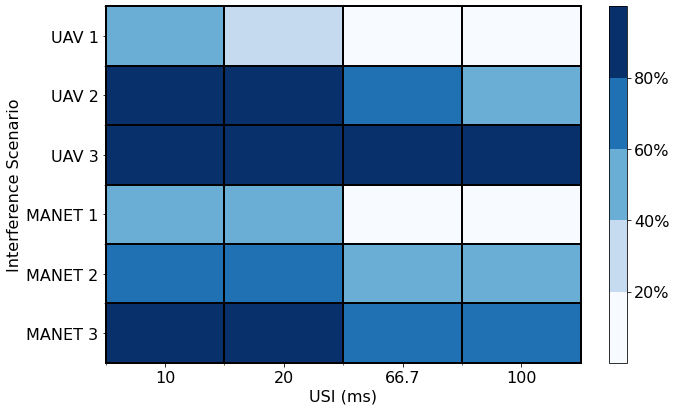

In [ ]:
import matplotlib.colors as mcolors

scenario = ["UAV 1", "UAV 2", "UAV 3", "MANET 1", "MANET 2", "MANET 3"]
usi = ["10", "20", "66.7", "100"]

# For Failure Prediction Test Set B
mean_rel = np.array([[59.30, 64.00, 99.70, 99.90],
                     [13.20, 7.30, 31.90, 44.20],
                     [3.75, 2.07, 7.27, 9.89], 
                     [56.50, 47.20, 81.80, 85.40],
                     [30.70, 23.00, 46.60, 50.90],
                     [14.50, 12.40, 27.70, 29.60]])

interference_strength = 100 - mean_rel
# colors_list = ['0.2', '0.4', '0.6', '0.8', '1.0']
colors_list = ['1.0', '0.8', '0.6', '0.4', '0.2'] 
# cmap = mcolors.ListedColormap(colors_list) 
cmap = plt.get_cmap('Blues')  # You can change this to 'viridis', 'Blues', etc.
N=5 # Number of discrete colors
colors = [cmap(i / (N - 1)) for i in range(N)]
discrete_cmap = mcolors.ListedColormap(colors)

plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(20, 6))
im = ax.imshow(interference_strength, vmin=0, vmax=100, cmap=discrete_cmap, aspect=0.5)

ax.set_xticks(range(len(usi)), labels=usi, fontsize=16)
ax.set_yticks(range(len(scenario)), labels=scenario, fontsize=16)
ax.set_xlabel("USI (ms)")
ax.set_ylabel("Interference Scenario")
ax.set_xticks(np.arange(4)-.5, minor=True)
ax.set_yticks(np.arange(6)-.5, minor=True)
ax.grid(which="minor", color="k", linestyle='-', linewidth=2)
[x.set_linewidth(2) for x in ax.spines.values()]

cbar = ax.figure.colorbar(im, ax=ax, ticks=[20, 40, 60, 80], pad=0.02)
cbar.ax.set_yticklabels(['20%', '40%', '60%', '80%']) 
# cbar.ax.set_ylabel("Interference Strength (Reliability Range)", rotation=-90, va='bottom')
fig.tight_layout()

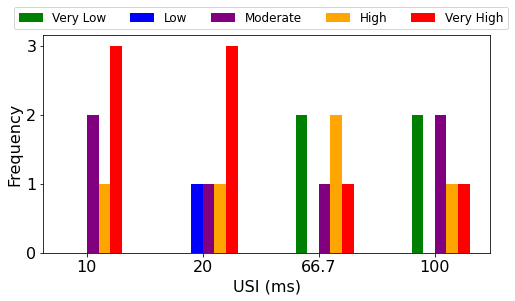

In [35]:
mean_rel = np.array([[59.30, 64.00, 99.70, 99.90],
                     [13.20, 7.30, 31.90, 44.20],
                     [3.75, 2.07, 7.27, 9.89], 
                     [56.50, 47.20, 81.80, 85.40],
                     [30.70, 23.00, 46.60, 50.90],
                     [14.50, 12.40, 27.70, 29.60]])
interference_strength = 100 - mean_rel
# Define categories (0-20, 20-40, 40-60, 60-80, 80-100)
categories = np.digitize(interference_strength, bins=[20, 40, 60, 80, 100])

# Colors for each category
category_colors = ['green', 'blue', 'purple', 'orange', 'red']

# Plot
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(8, 4))
width = 0.1  # Width of each bar

# Iterate over columns
for i in range(interference_strength.shape[1]):
    category_counts = [np.sum(categories[:, i] == j) for j in range(0, 5)]
    x_positions = [i + x * width for x in np.arange(5)]
    bars = ax.bar(x_positions, category_counts, width=width, color=category_colors, label=("Very Low", "Low", "Moderate", "High", "Very High"))

# Formatting
ax.set_xticks(np.arange(4) + 1.5 * width, fontsize=16)
ax.set_xticklabels(['10', '20', '66.7', '100'], fontsize=16)
ax.set_xlabel('USI (ms)', fontsize=16)
ax.set_ylabel('Frequency', fontsize=16)
legend_labels = ["Very Low", "Low", "Moderate", "High", "Very High"]
ax.legend(handles=bars, labels=legend_labels, fontsize=12, bbox_to_anchor=(-0.08, 1, 1, 0), ncol=5)

## Plot Box Plots of Dmax

Text(0.5, 0, 'USI (ms)')

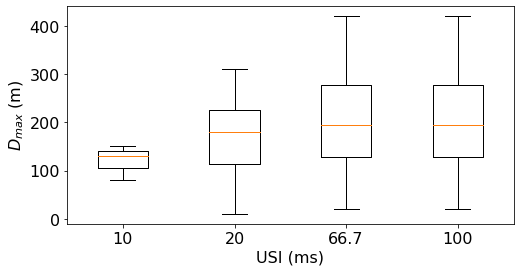

In [8]:
dmax_usi_10 = [130,150,80]
dmax_usi_20 = [200,270,310,160,210,120,90,10]
dmax_usi_667 = [250,360,420,170,220,140,90,20]
dmax_usi_100 = [250,360,420,170,220,140,90,20]

plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([dmax_usi_10, dmax_usi_20, dmax_usi_667, dmax_usi_100], showmeans=False)
ax.set_ylabel('$D_{max}$ (m)', fontsize=16)
# ax.set_ylim(-1,105)
ax.set_xticklabels(["10", "20", "66.7", "100"], fontsize=16)
ax.set_xlabel("USI (ms)", fontsize=16)

## Plot Results Mitigation

### Results for Various Schemes

In [37]:
MAX_RUN_NUM = 499 # Run num starts at 0

CASES = ["uav_scenario_2_processed"]
MANUAL_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_UAV_Interference_new"
WAYPOINT_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Waypoint_Only_UAV_Interference_new"
FP_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Fixed_Prob_UAV_Interference_new"
DV_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DV_Based_500_UAV_Interference_new"
TH_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/PM_Based_UAV_Interference_new"
TH_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/PM_GCS_Based_UAV_Interference_new"

# CASES = ["manet_scenario_2_processed"]
# MANUAL_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_MANET_Interference_new"
# WAYPOINT_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Waypoint_Only_MANET_Interference_new"
# FP_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Fixed_Prob_MANET_Interference_new"
# DV_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DV_Based_500_MANET_Interference_new"
# TH_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/PM_Based_MANET_Interference_new"
# TH_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/PM_GCS_Based_MANET_Interference_new"

manual_df = compile_results(MANUAL_PATH, CASES, MAX_RUN_NUM, "Simulation_Results.csv")
waypoint_df = compile_results(WAYPOINT_PATH, CASES, MAX_RUN_NUM)
fp_df = compile_results(FP_PATH, CASES, MAX_RUN_NUM)
dv_df = compile_results(DV_PATH, CASES, MAX_RUN_NUM)
pm_df = compile_results(TH_PATH, CASES, MAX_RUN_NUM)
pm_gcs_df = compile_results(TH_GCS_PATH, CASES, MAX_RUN_NUM)

In [38]:
# Temporary resolution to error in processing script introducing redundant columns
try:
    manual_df.drop(labels=["Num_Pkts_Reliable_DL","Total_Reliability_DL","Num_Pkts_Delay_Excd_DL"], axis='columns', inplace=True)
except:
    print("No columns dropped")
try:
    waypoint_df.drop(labels=["Num_Pkts_Reliable_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
except:
    print("No columns dropped")
try:
    fp_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
except:
    print("No columns dropped")
try:
    dv_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
except:
    print("No columns dropped")
try:
    pm_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
except:
    print("No columns dropped")
try:
    pm_gcs_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
except:
    print("No columns dropped")

No columns dropped
No columns dropped
No columns dropped
No columns dropped
No columns dropped
No columns dropped


In [49]:
print(len(manual_df), len(waypoint_df), len(fp_df), len(dv_df), len(pm_df), len(pm_gcs_df))

1544 1544 1544 1544 1544 1544


In [39]:
'''Filter out runs that are reliable (False Positives) (Using Merge)'''
# REL_TH = 0.999 
# runs_reliable = manual_df.loc[(manual_df["Total_Reliability_DL"]>=REL_TH) & (manual_df["Total_Reliability_UL"]>=REL_TH) & (manual_df["Total_Reliability_VID"]>=REL_TH)]

# manual_merge = manual_df.merge(runs_reliable.drop_duplicates(), on=['Scenario','Run'], 
#                    how='left', indicator=True)
# manual_df_fil = manual_df.loc[(manual_merge['_merge'] == 'left_only').to_numpy()]

# waypoint_merge = waypoint_df.merge(runs_reliable.drop_duplicates(), on=['Scenario','Run'], 
#                    how='left', indicator=True)
# waypoint_df_fil = waypoint_df.loc[(waypoint_merge['_merge'] == 'left_only').to_numpy()]

# fp_merge = fp_df.merge(runs_reliable.drop_duplicates(), on=['Scenario','Run'], 
#                    how='left', indicator=True)
# fp_df_fil = fp_df.loc[(fp_merge['_merge'] == 'left_only').to_numpy()]

# dv_merge = dv_df.merge(runs_reliable.drop_duplicates(), on=['Scenario','Run'], 
#                    how='left', indicator=True)
# dv_df_fil = dv_df.loc[(dv_merge['_merge'] == 'left_only').to_numpy()]

# pm_merge = pm_df.merge(runs_reliable.drop_duplicates(), on=['Scenario','Run'], 
#                    how='left', indicator=True)
# pm_df_fil = pm_df.loc[(pm_merge['_merge'] == 'left_only').to_numpy()]

# pm_gcs_merge = pm_gcs_df.merge(runs_reliable.drop_duplicates(), on=['Scenario','Run'], 
#                    how='left', indicator=True)
# pm_gcs_df_fil = pm_gcs_df.loc[(pm_gcs_merge['_merge'] == 'left_only').to_numpy()]

'''Filter out runs that are reliable (False Positives) and runs where reliability is NaN (invalid)
Using sort and .loc '''
# NOTE: UPDATE 29/11/2024: Let's not filter out the runs where reliability is not compromised, since it complicates the story. The results are not very affected.
REL_TH = 0.999 
# First, sort all DFs so that their rows are of the same simulation cases
manual_df.sort_values(by=["Scenario", "Run"], inplace=True)
waypoint_df.sort_values(by=["Scenario", "Run"], inplace=True)
fp_df.sort_values(by=["Scenario", "Run"], inplace=True)
dv_df.sort_values(by=["Scenario", "Run"], inplace=True)
pm_df.sort_values(by=["Scenario", "Run"], inplace=True)
pm_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)

manual_df.reset_index(inplace=True)
waypoint_df.reset_index(inplace=True)
fp_df.reset_index(inplace=True)
dv_df.reset_index(inplace=True)
pm_df.reset_index(inplace=True)
pm_gcs_df.reset_index(inplace=True)

# NOTE: The below method of filtering out "reliable" runs is not correct, since it does not consider reliability before switching
# runs_reliable = (manual_df["Total_Reliability_DL"]>=REL_TH) & (manual_df["Total_Reliability_UL"]>=REL_TH) & (manual_df["Total_Reliability_VID"]>=REL_TH).to_numpy()
runs_nan = (manual_df.isnull().any(axis=1).to_numpy()) | (waypoint_df.isnull().any(axis=1).to_numpy()) | (fp_df.isnull().any(axis=1).to_numpy()) | \
            (dv_df.isnull().any(axis=1).to_numpy()) | (pm_df.isnull().any(axis=1).to_numpy()) | (pm_gcs_df.isnull().any(axis=1).to_numpy())

# manual_df_fil = manual_df.loc[~(runs_reliable | runs_nan)]
# waypoint_df_fil = waypoint_df.loc[~(runs_reliable | runs_nan)]
# fp_df_fil = fp_df.loc[~(runs_reliable | runs_nan)]
# dv_df_fil = dv_df.loc[~(runs_reliable | runs_nan)]
# pm_df_fil = pm_df.loc[~(runs_reliable | runs_nan)]
# pm_gcs_df_fil = pm_gcs_df.loc[~(runs_reliable | runs_nan)]
manual_df_fil = manual_df.loc[~(runs_nan)]
waypoint_df_fil = waypoint_df.loc[~(runs_nan)]
fp_df_fil = fp_df.loc[~(runs_nan)]
dv_df_fil = dv_df.loc[~(runs_nan)]
pm_df_fil = pm_df.loc[~(runs_nan)]
pm_gcs_df_fil = pm_gcs_df.loc[~(runs_nan)]

In [12]:
print(len(manual_df_fil), len(waypoint_df_fil), len(fp_df_fil), len(dv_df_fil), len(pm_df_fil), len(pm_gcs_df_fil))

10319 10319 10319 10319 10319 10319


In [16]:
print(np.any(manual_df_fil["Total_Reliability_UL"] > 1))
print(np.any(waypoint_df_fil["Total_Reliability_UL"] > 1))
print(np.any(dv_df_fil["Total_Reliability_UL"] > 1))
print(np.any(fp_df_fil["Total_Reliability_UL"] > 1))
print(np.any(pm_df_fil["Total_Reliability_UL"] > 1))
print(np.any(pm_gcs_df_fil["Total_Reliability_UL"] > 1))

False
False
False
False
False
False


Text(0.75, -0.18, '         With GCS    \n| - Rebroadcasting - |')

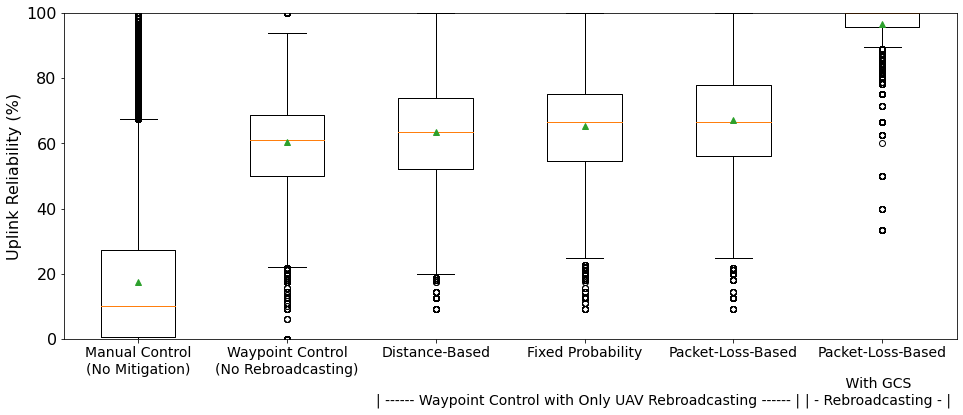

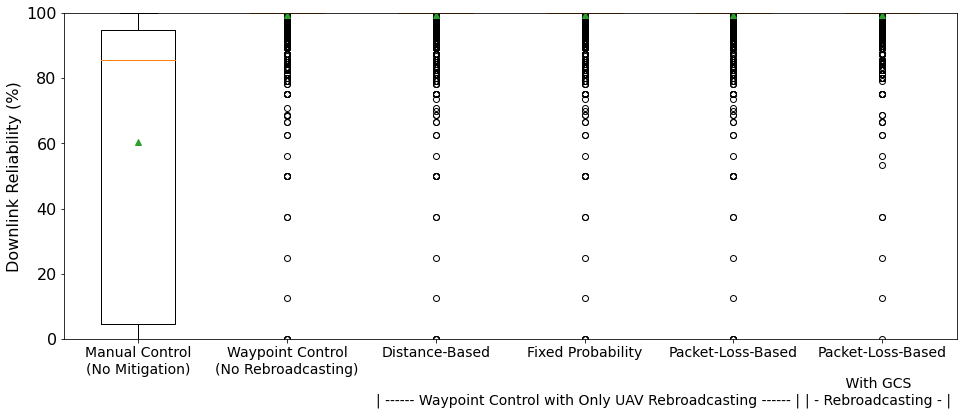

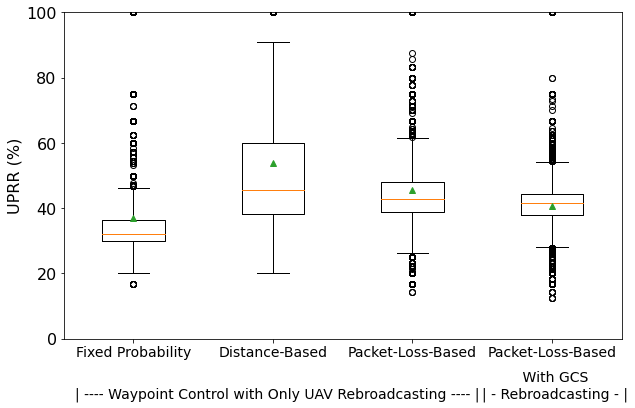

In [30]:
# Plot box plot for Avg DL Reliability
manual_dl_rel = np.concatenate((manual_df_fil["Reliability_UAV_0"].values*100, manual_df_fil["Reliability_UAV_1"].values*100, manual_df_fil["Reliability_UAV_2"].values*100, manual_df_fil["Reliability_UAV_3"].values*100,
                               manual_df_fil["Reliability_UAV_4"].values*100, manual_df_fil["Reliability_UAV_5"].values*100, manual_df_fil["Reliability_UAV_6"].values*100, manual_df_fil["Reliability_UAV_7"].values*100))
waypoint_dl_rel = np.concatenate((waypoint_df_fil["Reliability_UAV_0"].values*100, waypoint_df_fil["Reliability_UAV_1"].values*100, waypoint_df_fil["Reliability_UAV_2"].values*100, waypoint_df_fil["Reliability_UAV_3"].values*100,
                               waypoint_df_fil["Reliability_UAV_4"].values*100, waypoint_df_fil["Reliability_UAV_5"].values*100, waypoint_df_fil["Reliability_UAV_6"].values*100, waypoint_df_fil["Reliability_UAV_7"].values*100))
dv_dl_rel = np.concatenate((dv_df_fil["Reliability_UAV_0"].values*100, dv_df_fil["Reliability_UAV_1"].values*100, dv_df_fil["Reliability_UAV_2"].values*100, dv_df_fil["Reliability_UAV_3"].values*100,
                            dv_df_fil["Reliability_UAV_4"].values*100, dv_df_fil["Reliability_UAV_5"].values*100, dv_df_fil["Reliability_UAV_6"].values*100, dv_df_fil["Reliability_UAV_7"].values*100))
fp_dl_rel = np.concatenate((fp_df_fil["Reliability_UAV_0"].values*100, fp_df_fil["Reliability_UAV_1"].values*100, fp_df_fil["Reliability_UAV_2"].values*100, fp_df_fil["Reliability_UAV_3"].values*100,
                            fp_df_fil["Reliability_UAV_4"].values*100, fp_df_fil["Reliability_UAV_5"].values*100, fp_df_fil["Reliability_UAV_6"].values*100, fp_df_fil["Reliability_UAV_7"].values*100))
pm_dl_rel = np.concatenate((pm_df_fil["Reliability_UAV_0"].values*100, pm_df_fil["Reliability_UAV_1"].values*100, pm_df_fil["Reliability_UAV_2"].values*100, pm_df_fil["Reliability_UAV_3"].values*100,
                            pm_df_fil["Reliability_UAV_4"].values*100, pm_df_fil["Reliability_UAV_5"].values*100, pm_df_fil["Reliability_UAV_6"].values*100, pm_df_fil["Reliability_UAV_7"].values*100))
pm_gcs_dl_rel = np.concatenate((pm_gcs_df_fil["Reliability_UAV_0"].values*100, pm_gcs_df_fil["Reliability_UAV_1"].values*100, pm_gcs_df_fil["Reliability_UAV_2"].values*100, pm_gcs_df_fil["Reliability_UAV_3"].values*100,
                               pm_gcs_df_fil["Reliability_UAV_4"].values*100, pm_gcs_df_fil["Reliability_UAV_5"].values*100, pm_gcs_df_fil["Reliability_UAV_6"].values*100, pm_gcs_df_fil["Reliability_UAV_7"].values*100))
avg_dl_rel_list = [manual_dl_rel, waypoint_dl_rel, dv_dl_rel, fp_dl_rel, pm_dl_rel, pm_gcs_dl_rel]
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(16, 6))
plt.boxplot(avg_dl_rel_list, showmeans=True, labels=["Manual Control\n(No Mitigation)", "Waypoint Control\n(No Rebroadcasting)", "Distance-Based", "Fixed Probability", "Packet-Loss-Based", "Packet-Loss-Based"])
plt.ylabel("Uplink Reliability (%)")
plt.xticks(fontsize=14)
plt.ylim(0, 100)
plt.text(0.35, -0.2, "| ------ Waypoint Control with Only UAV Rebroadcasting ------ |", transform=ax.transAxes, fontsize=14)
plt.text(0.83, -0.2, "         With GCS    \n| - Rebroadcasting - |", transform=ax.transAxes, fontsize=14)

# Plot box plot for Avg DL Reliability
# The UL Reliability may be above 100%, due to slight error in processing script
# manual_df_fil["Total_Reliability_UL"].clip(upper=1, inplace=True)
# waypoint_df_fil["Total_Reliability_UL"].clip(upper=1, inplace=True)
# dv_df_fil["Total_Reliability_UL"].clip(upper=1, inplace=True)
# fp_df_fil["Total_Reliability_UL"].clip(upper=1, inplace=True)
# pm_df_fil["Total_Reliability_UL"].clip(upper=1, inplace=True)
# pm_gcs_df_fil["Total_Reliability_UL"].clip(upper=1, inplace=True)
avg_ul_rel_list = [manual_df_fil["Total_Reliability_UL"].values*100, waypoint_df_fil["Total_Reliability_UL"].values*100, dv_df_fil["Total_Reliability_UL"].values*100, 
                   fp_df_fil["Total_Reliability_UL"].values*100, pm_df_fil["Total_Reliability_UL"].values*100, pm_gcs_df_fil["Total_Reliability_UL"].values*100]
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(16, 6))
plt.boxplot(avg_ul_rel_list, showmeans=True, labels=["Manual Control\n(No Mitigation)", "Waypoint Control\n(No Rebroadcasting)", "Distance-Based", "Fixed Probability", "Packet-Loss-Based", "Packet-Loss-Based"])
plt.ylabel("Downlink Reliability (%)")
plt.xticks(fontsize=14)
plt.ylim(0, 100)
plt.text(0.35, -0.2, "| ------ Waypoint Control with Only UAV Rebroadcasting ------ |", transform=ax.transAxes, fontsize=14)
plt.text(0.83, -0.2, "         With GCS    \n| - Rebroadcasting - |", transform=ax.transAxes, fontsize=14)

# Plot box plot for Avg DL UPRR
dv_dl_uprr = np.concatenate((dv_df_fil["UPRR_UAV_0"].values*100, dv_df_fil["UPRR_UAV_1"].values*100, dv_df_fil["UPRR_UAV_2"].values*100, dv_df_fil["UPRR_UAV_3"].values*100,
                            dv_df_fil["UPRR_UAV_4"].values*100, dv_df_fil["UPRR_UAV_5"].values*100, dv_df_fil["UPRR_UAV_6"].values*100, dv_df_fil["UPRR_UAV_7"].values*100))
fp_dl_uprr = np.concatenate((fp_df_fil["UPRR_UAV_0"].values*100, fp_df_fil["UPRR_UAV_1"].values*100, fp_df_fil["UPRR_UAV_2"].values*100, fp_df_fil["UPRR_UAV_3"].values*100,
                            fp_df_fil["UPRR_UAV_4"].values*100, fp_df_fil["UPRR_UAV_5"].values*100, fp_df_fil["UPRR_UAV_6"].values*100, fp_df_fil["UPRR_UAV_7"].values*100))
pm_dl_uprr = np.concatenate((pm_df_fil["UPRR_UAV_0"].values*100, pm_df_fil["UPRR_UAV_1"].values*100, pm_df_fil["UPRR_UAV_2"].values*100, pm_df_fil["UPRR_UAV_3"].values*100,
                            pm_df_fil["UPRR_UAV_4"].values*100, pm_df_fil["UPRR_UAV_5"].values*100, pm_df_fil["UPRR_UAV_6"].values*100, pm_df_fil["UPRR_UAV_7"].values*100))
pm_gcs_dl_uprr = np.concatenate((pm_gcs_df_fil["UPRR_UAV_0"].values*100, pm_gcs_df_fil["UPRR_UAV_1"].values*100, pm_gcs_df_fil["UPRR_UAV_2"].values*100, pm_gcs_df_fil["UPRR_UAV_3"].values*100,
                               pm_gcs_df_fil["UPRR_UAV_4"].values*100, pm_gcs_df_fil["UPRR_UAV_5"].values*100, pm_gcs_df_fil["UPRR_UAV_6"].values*100, pm_gcs_df_fil["UPRR_UAV_7"].values*100))
avg_dl_uprr_list = [fp_dl_uprr, dv_dl_uprr, pm_dl_uprr, pm_gcs_dl_uprr]
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(10, 6))
plt.boxplot(avg_dl_uprr_list, showmeans=True, labels=["Fixed Probability", "Distance-Based", "Packet-Loss-Based", "Packet-Loss-Based"])
plt.ylabel("UPRR (%)")
plt.xticks(fontsize=14)
plt.ylim(0, 100)
plt.text(0.02, -0.18, "| ---- Waypoint Control with Only UAV Rebroadcasting ---- |", transform=ax.transAxes, fontsize=14)
plt.text(0.75, -0.18, "         With GCS    \n| - Rebroadcasting - |", transform=ax.transAxes, fontsize=14)

Text(0.81, -0.2, '          With GCS     \n| -- Rebroadcasting -- |')

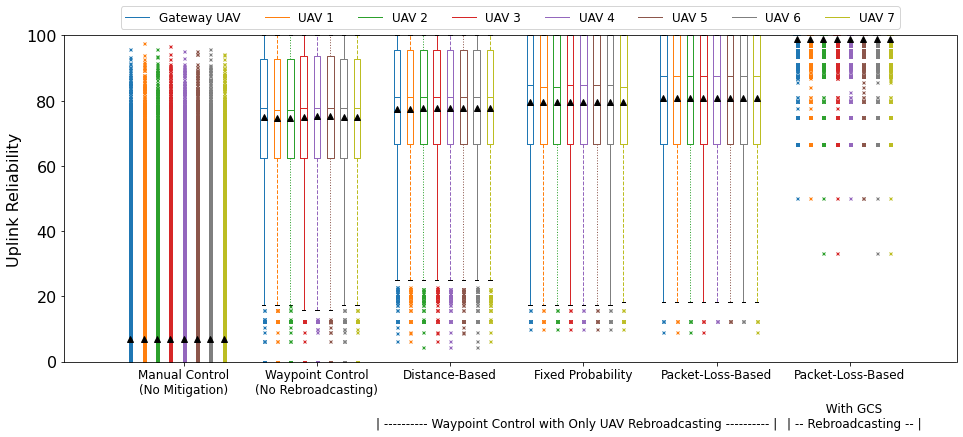

In [40]:
# To verify that the DL reliability of all UAVs are essentially the same (in terms of their box plots and median)

uav_0 = [manual_df_fil["Reliability_UAV_0"].values*100, waypoint_df_fil["Reliability_UAV_0"].values*100, dv_df_fil["Reliability_UAV_0"].values*100, 
         fp_df_fil["Reliability_UAV_0"].values*100, pm_df_fil["Reliability_UAV_0"].values*100, pm_gcs_df_fil["Reliability_UAV_0"].values*100]
uav_1 = [manual_df_fil["Reliability_UAV_1"].values*100, waypoint_df_fil["Reliability_UAV_1"].values*100, dv_df_fil["Reliability_UAV_1"].values*100, 
         fp_df_fil["Reliability_UAV_1"].values*100, pm_df_fil["Reliability_UAV_1"].values*100, pm_gcs_df_fil["Reliability_UAV_1"].values*100]
uav_2 = [manual_df_fil["Reliability_UAV_2"].values*100, waypoint_df_fil["Reliability_UAV_2"].values*100, dv_df_fil["Reliability_UAV_2"].values*100, 
         fp_df_fil["Reliability_UAV_2"].values*100, pm_df_fil["Reliability_UAV_2"].values*100, pm_gcs_df_fil["Reliability_UAV_2"].values*100]
uav_3 = [manual_df_fil["Reliability_UAV_3"].values*100, waypoint_df_fil["Reliability_UAV_3"].values*100, dv_df_fil["Reliability_UAV_3"].values*100, 
         fp_df_fil["Reliability_UAV_3"].values*100, pm_df_fil["Reliability_UAV_3"].values*100, pm_gcs_df_fil["Reliability_UAV_3"].values*100]
uav_4 = [manual_df_fil["Reliability_UAV_4"].values*100, waypoint_df_fil["Reliability_UAV_4"].values*100, dv_df_fil["Reliability_UAV_4"].values*100, 
         fp_df_fil["Reliability_UAV_4"].values*100, pm_df_fil["Reliability_UAV_4"].values*100, pm_gcs_df_fil["Reliability_UAV_4"].values*100]
uav_5 = [manual_df_fil["Reliability_UAV_5"].values*100, waypoint_df_fil["Reliability_UAV_5"].values*100, dv_df_fil["Reliability_UAV_5"].values*100, 
         fp_df_fil["Reliability_UAV_5"].values*100, pm_df_fil["Reliability_UAV_5"].values*100, pm_gcs_df_fil["Reliability_UAV_5"].values*100]
uav_6 = [manual_df_fil["Reliability_UAV_6"].values*100, waypoint_df_fil["Reliability_UAV_6"].values*100, dv_df_fil["Reliability_UAV_6"].values*100, 
         fp_df_fil["Reliability_UAV_6"].values*100, pm_df_fil["Reliability_UAV_6"].values*100, pm_gcs_df_fil["Reliability_UAV_6"].values*100]
uav_7 = [manual_df_fil["Reliability_UAV_7"].values*100, waypoint_df_fil["Reliability_UAV_7"].values*100, dv_df_fil["Reliability_UAV_7"].values*100, 
         fp_df_fil["Reliability_UAV_7"].values*100, pm_df_fil["Reliability_UAV_7"].values*100, pm_gcs_df_fil["Reliability_UAV_7"].values*100]

space = 0.1
box_params = dict(widths=0.05)
fig, ax = plt.subplots(figsize=(16, 6))
plt.rcParams.update({'font.size': 16})
box_0 = plt.boxplot(uav_0, showmeans=True, labels=None,
            positions=np.arange(6)-4*space, boxprops=dict(linestyle='-', linewidth=1,  color='tab:blue'), whiskerprops=dict(linestyle='-', linewidth=1, color='tab:blue'), 
            medianprops=dict(linestyle='-', color='tab:blue'), meanprops=dict(markerfacecolor="black", markeredgecolor="black"), flierprops=dict(marker='x', markeredgecolor='tab:blue', markersize=3), **box_params)
box_1 = plt.boxplot(uav_1, showmeans=True, labels=None,
            positions=np.arange(6)-3*space, boxprops=dict(linestyle='-', linewidth=1, color='tab:orange'), whiskerprops=dict(linestyle='--', linewidth=1, color='tab:orange'),
            medianprops=dict(linestyle='-', color='tab:orange'), meanprops=dict(markerfacecolor="black", markeredgecolor="black"), flierprops=dict(marker='x', markeredgecolor='tab:orange', markersize=3), **box_params)
box_2 = plt.boxplot(uav_2, showmeans=True, labels=None,
            positions=np.arange(6)-2*space, boxprops=dict(linestyle='-', linewidth=1, color='tab:green'), whiskerprops=dict(linestyle=':', linewidth=1, color='tab:green'),
            medianprops=dict(linestyle='-', color='tab:green'), meanprops=dict(markerfacecolor="black", markeredgecolor="black"), flierprops=dict(marker='x', markeredgecolor='tab:green', markersize=3), **box_params)
box_3 = plt.boxplot(uav_3, showmeans=True, labels=None,
            positions=np.arange(6)-space, boxprops=dict(linestyle='-', linewidth=1,  color='tab:red'), whiskerprops=dict(linestyle='-', linewidth=1, color='tab:red'), 
            medianprops=dict(linestyle='-', color='tab:red'), meanprops=dict(markerfacecolor="black", markeredgecolor="black"), flierprops=dict(marker='x', markeredgecolor='tab:red', markersize=3), **box_params)
box_4 = plt.boxplot(uav_4, showmeans=True, labels=None,
            positions=np.arange(6), boxprops=dict(linestyle='-', linewidth=1, color='tab:purple'), whiskerprops=dict(linestyle='--', linewidth=1, color='tab:purple'),
            medianprops=dict(linestyle='-', color='tab:purple'), meanprops=dict(markerfacecolor="black", markeredgecolor="black"), flierprops=dict(marker='x', markeredgecolor='tab:purple', markersize=3), **box_params)
box_5 = plt.boxplot(uav_5, showmeans=True, labels=None,
            positions=np.arange(6)+space, boxprops=dict(linestyle='-', linewidth=1, color='tab:brown'), whiskerprops=dict(linestyle=':', linewidth=1, color='tab:brown'),
            medianprops=dict(linestyle='-', color='tab:brown'), meanprops=dict(markerfacecolor="black", markeredgecolor="black"), flierprops=dict(marker='x', markeredgecolor='tab:brown', markersize=3), **box_params)
box_6 = plt.boxplot(uav_6, showmeans=True, labels=None,
            positions=np.arange(6)+2*space, boxprops=dict(linestyle='-', linewidth=1,  color='tab:gray'), whiskerprops=dict(linestyle='-', linewidth=1, color='tab:gray'), 
            medianprops=dict(linestyle='-', color='tab:gray'), meanprops=dict(markerfacecolor="black", markeredgecolor="black"), flierprops=dict(marker='x', markeredgecolor='tab:gray', markersize=3), **box_params)
box_7 = plt.boxplot(uav_7, showmeans=True, labels=None,
            positions=np.arange(6)+3*space, boxprops=dict(linestyle='-', linewidth=1, color='tab:olive'), whiskerprops=dict(linestyle='--', linewidth=1, color='tab:olive'),
            medianprops=dict(linestyle='-', color='tab:olive'), meanprops=dict(markerfacecolor="black", markeredgecolor="black"), flierprops=dict(marker='x', markeredgecolor='tab:olive', markersize=3), **box_params)
plt.legend( (box_0["boxes"][0], box_1["boxes"][0], box_2["boxes"][0], box_3["boxes"][0], box_4["boxes"][0], box_5["boxes"][0], box_6["boxes"][0], box_7["boxes"][0]), 
           ["Gateway UAV", "UAV 1", "UAV 2", "UAV 3", "UAV 4", "UAV 5", "UAV 6", "UAV 7"], bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower center", fontsize=12, borderaxespad=0, ncol=8)
plt.xticks(np.arange(6), ["Manual Control\n(No Mitigation)", "Waypoint Control\n(No Rebroadcasting)", "Distance-Based", "Fixed Probability", "Packet-Loss-Based", "Packet-Loss-Based"], fontsize=12)
plt.ylabel("Uplink Reliability")
plt.ylim(0,100)
plt.text(0.35, -0.2, "| ---------- Waypoint Control with Only UAV Rebroadcasting ---------- |", transform=ax.transAxes, fontsize=12)
plt.text(0.81, -0.2, "          With GCS     \n| -- Rebroadcasting -- |", transform=ax.transAxes, fontsize=12)


Text(0.74, -0.2, '          With GCS     \n| -- Rebroadcasting -- |')

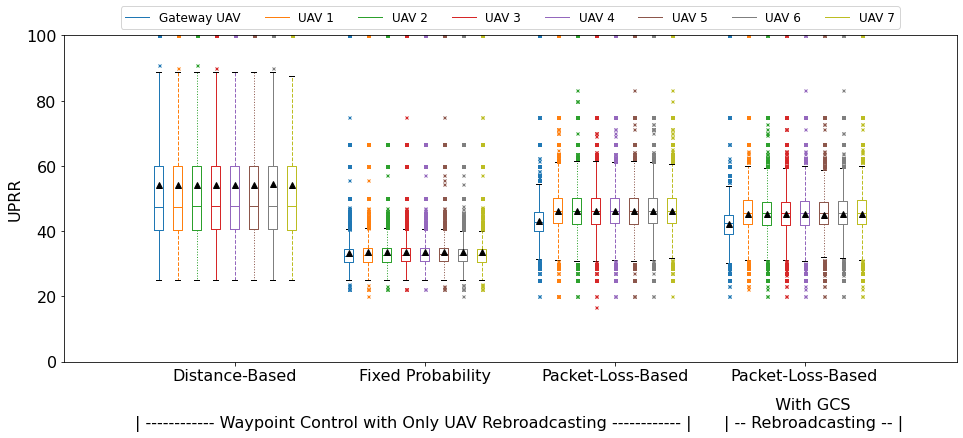

In [41]:
# To verify that the UPRR of all UAVs are essentially the same (in terms of their box plots and median)

uav_0 = [dv_df_fil["UPRR_UAV_0"].values*100,fp_df_fil["UPRR_UAV_0"].values*100, pm_df_fil["UPRR_UAV_0"].values*100, pm_gcs_df_fil["UPRR_UAV_0"].values*100]
uav_1 = [dv_df_fil["UPRR_UAV_1"].values*100,fp_df_fil["UPRR_UAV_1"].values*100, pm_df_fil["UPRR_UAV_1"].values*100, pm_gcs_df_fil["UPRR_UAV_1"].values*100]
uav_2 = [dv_df_fil["UPRR_UAV_2"].values*100,fp_df_fil["UPRR_UAV_2"].values*100, pm_df_fil["UPRR_UAV_2"].values*100, pm_gcs_df_fil["UPRR_UAV_2"].values*100]
uav_3 = [dv_df_fil["UPRR_UAV_3"].values*100,fp_df_fil["UPRR_UAV_3"].values*100, pm_df_fil["UPRR_UAV_3"].values*100, pm_gcs_df_fil["UPRR_UAV_3"].values*100]
uav_4 = [dv_df_fil["UPRR_UAV_4"].values*100,fp_df_fil["UPRR_UAV_4"].values*100, pm_df_fil["UPRR_UAV_4"].values*100, pm_gcs_df_fil["UPRR_UAV_4"].values*100]
uav_5 = [dv_df_fil["UPRR_UAV_5"].values*100,fp_df_fil["UPRR_UAV_5"].values*100, pm_df_fil["UPRR_UAV_5"].values*100, pm_gcs_df_fil["UPRR_UAV_5"].values*100]
uav_6 = [dv_df_fil["UPRR_UAV_6"].values*100,fp_df_fil["UPRR_UAV_6"].values*100, pm_df_fil["UPRR_UAV_6"].values*100, pm_gcs_df_fil["UPRR_UAV_6"].values*100]
uav_7 = [dv_df_fil["UPRR_UAV_7"].values*100,fp_df_fil["UPRR_UAV_7"].values*100, pm_df_fil["UPRR_UAV_7"].values*100, pm_gcs_df_fil["UPRR_UAV_7"].values*100]

space = 0.1
box_params = dict(widths=0.05)
fig, ax = plt.subplots(figsize=(16, 6))
plt.rcParams.update({'font.size': 16})
box_0 = plt.boxplot(uav_0, showmeans=True, labels=None,
            positions=np.arange(4)-4*space, boxprops=dict(linestyle='-', linewidth=1,  color='tab:blue'), whiskerprops=dict(linestyle='-', linewidth=1, color='tab:blue'), 
            medianprops=dict(linestyle='-', color='tab:blue'), meanprops=dict(markerfacecolor="black", markeredgecolor="black"), flierprops=dict(marker='x', markeredgecolor='tab:blue', markersize=3), **box_params)
box_1 = plt.boxplot(uav_1, showmeans=True, labels=None,
            positions=np.arange(4)-3*space, boxprops=dict(linestyle='-', linewidth=1, color='tab:orange'), whiskerprops=dict(linestyle='--', linewidth=1, color='tab:orange'),
            medianprops=dict(linestyle='-', color='tab:orange'), meanprops=dict(markerfacecolor="black", markeredgecolor="black"), flierprops=dict(marker='x', markeredgecolor='tab:orange', markersize=3), **box_params)
box_2 = plt.boxplot(uav_2, showmeans=True, labels=None,
            positions=np.arange(4)-2*space, boxprops=dict(linestyle='-', linewidth=1, color='tab:green'), whiskerprops=dict(linestyle=':', linewidth=1, color='tab:green'),
            medianprops=dict(linestyle='-', color='tab:green'), meanprops=dict(markerfacecolor="black", markeredgecolor="black"), flierprops=dict(marker='x', markeredgecolor='tab:green', markersize=3), **box_params)
box_3 = plt.boxplot(uav_3, showmeans=True, labels=None,
            positions=np.arange(4)-space, boxprops=dict(linestyle='-', linewidth=1,  color='tab:red'), whiskerprops=dict(linestyle='-', linewidth=1, color='tab:red'), 
            medianprops=dict(linestyle='-', color='tab:red'), meanprops=dict(markerfacecolor="black", markeredgecolor="black"), flierprops=dict(marker='x', markeredgecolor='tab:red', markersize=3), **box_params)
box_4 = plt.boxplot(uav_4, showmeans=True, labels=None,
            positions=np.arange(4), boxprops=dict(linestyle='-', linewidth=1, color='tab:purple'), whiskerprops=dict(linestyle='--', linewidth=1, color='tab:purple'),
            medianprops=dict(linestyle='-', color='tab:purple'), meanprops=dict(markerfacecolor="black", markeredgecolor="black"), flierprops=dict(marker='x', markeredgecolor='tab:purple', markersize=3), **box_params)
box_5 = plt.boxplot(uav_5, showmeans=True, labels=None,
            positions=np.arange(4)+space, boxprops=dict(linestyle='-', linewidth=1, color='tab:brown'), whiskerprops=dict(linestyle=':', linewidth=1, color='tab:brown'),
            medianprops=dict(linestyle='-', color='tab:brown'), meanprops=dict(markerfacecolor="black", markeredgecolor="black"), flierprops=dict(marker='x', markeredgecolor='tab:brown', markersize=3), **box_params)
box_6 = plt.boxplot(uav_6, showmeans=True, labels=None,
            positions=np.arange(4)+2*space, boxprops=dict(linestyle='-', linewidth=1,  color='tab:gray'), whiskerprops=dict(linestyle='-', linewidth=1, color='tab:gray'), 
            medianprops=dict(linestyle='-', color='tab:gray'), meanprops=dict(markerfacecolor="black", markeredgecolor="black"), flierprops=dict(marker='x', markeredgecolor='tab:gray', markersize=3), **box_params)
box_7 = plt.boxplot(uav_7, showmeans=True, labels=None,
            positions=np.arange(4)+3*space, boxprops=dict(linestyle='-', linewidth=1, color='tab:olive'), whiskerprops=dict(linestyle='--', linewidth=1, color='tab:olive'),
            medianprops=dict(linestyle='-', color='tab:olive'), meanprops=dict(markerfacecolor="black", markeredgecolor="black"), flierprops=dict(marker='x', markeredgecolor='tab:olive', markersize=3), **box_params)
plt.legend( (box_0["boxes"][0], box_1["boxes"][0], box_2["boxes"][0], box_3["boxes"][0], box_4["boxes"][0], box_5["boxes"][0], box_6["boxes"][0], box_7["boxes"][0]), 
           ["Gateway UAV", "UAV 1", "UAV 2", "UAV 3", "UAV 4", "UAV 5", "UAV 6", "UAV 7"], bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower center", fontsize=12, borderaxespad=0, ncol=8)
plt.xticks(np.arange(4), ["Distance-Based", "Fixed Probability", "Packet-Loss-Based", "Packet-Loss-Based"], fontsize=16)
plt.ylabel("UPRR")
plt.ylim(0,100)
plt.text(0.08, -0.2, "| ------------ Waypoint Control with Only UAV Rebroadcasting ------------ |", transform=ax.transAxes, fontsize=16)
plt.text(0.74, -0.2, "          With GCS     \n| -- Rebroadcasting -- |", transform=ax.transAxes, fontsize=16)


### Plot Reliability for False Negative Cases

(0.0, 100.0)

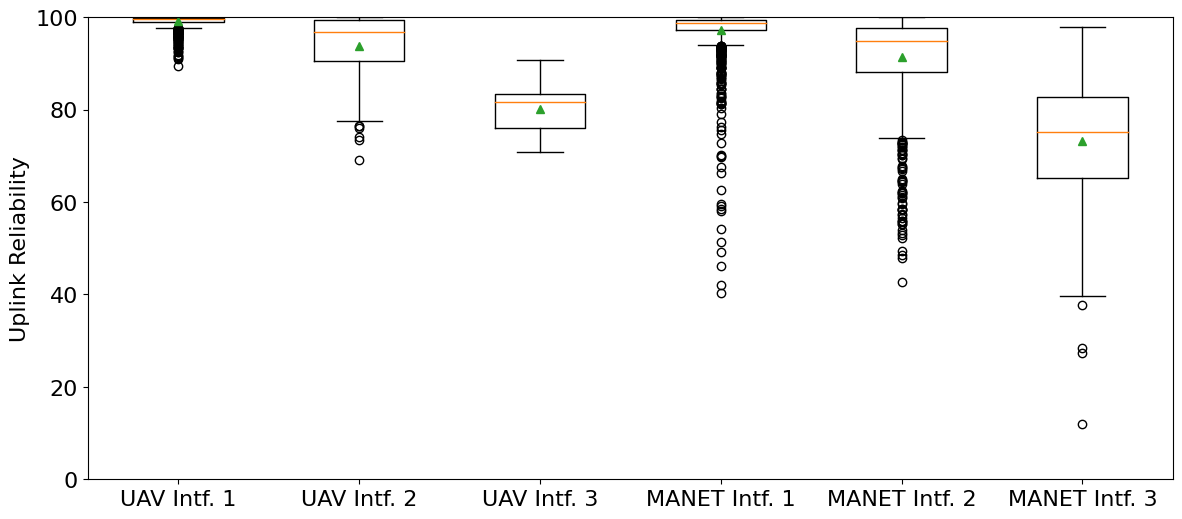

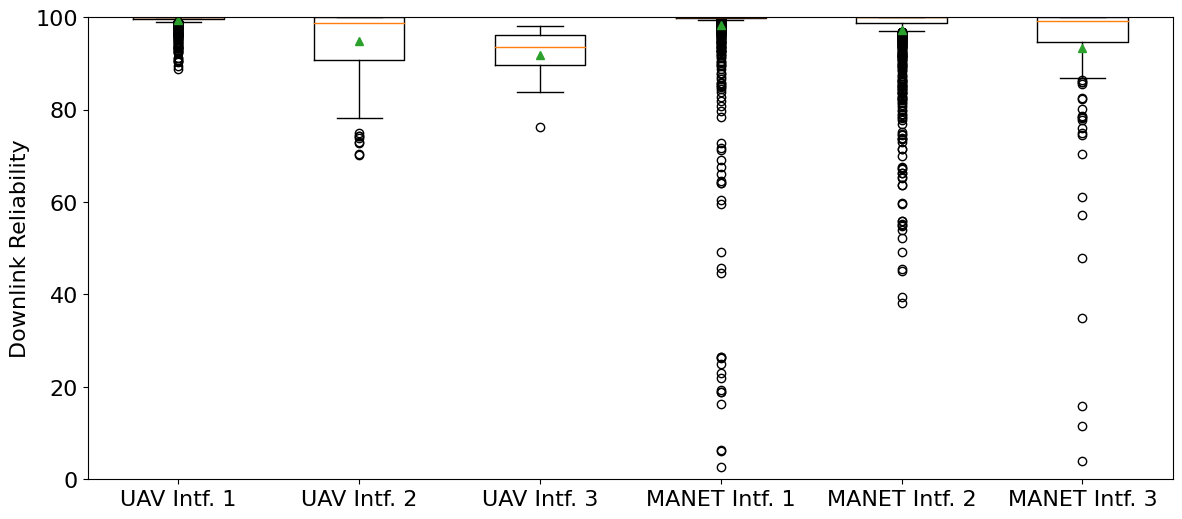

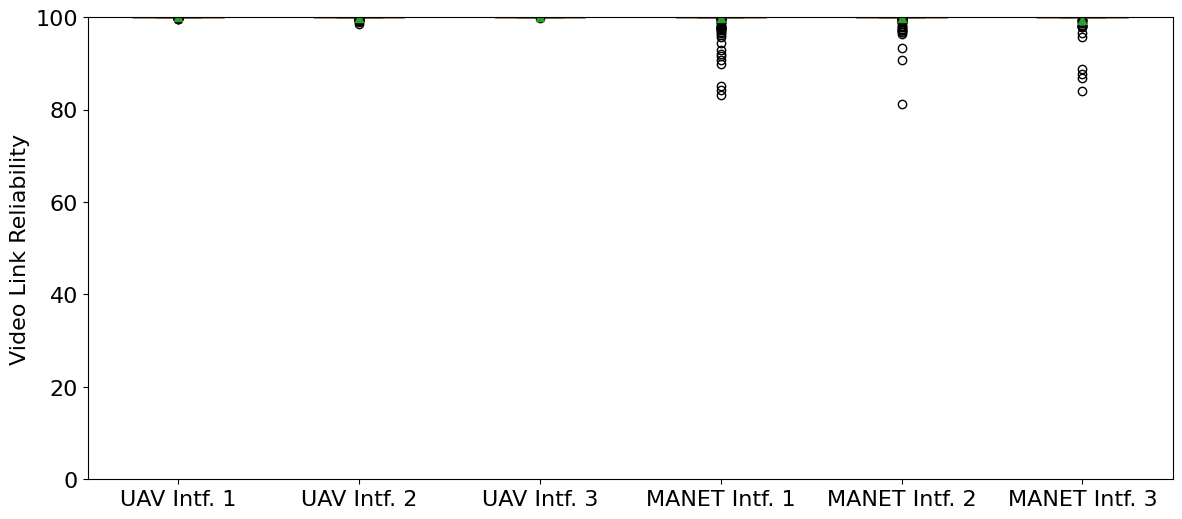

In [3]:
MANUAL_UAV_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_UAV_Interference"
MANUAL_MANET_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_MANET_Interference"

uav_0 = compile_results(MANUAL_UAV_PATH, ["uav_scenario_0_processed"], "No_Switch_Results.csv")
uav_1 = compile_results(MANUAL_UAV_PATH, ["uav_scenario_1_processed"], "No_Switch_Results.csv")
uav_2 = compile_results(MANUAL_UAV_PATH, ["uav_scenario_2_processed"], "No_Switch_Results.csv")
manet_0 = compile_results(MANUAL_MANET_PATH, ["manet_scenario_0_processed"], "No_Switch_Results.csv")
manet_1 = compile_results(MANUAL_MANET_PATH, ["manet_scenario_1_processed"], "No_Switch_Results.csv")
manet_2 = compile_results(MANUAL_MANET_PATH, ["manet_scenario_2_processed"], "No_Switch_Results.csv")

# Filter out True Negatives
REL_TH = 0.999
uav_0 = uav_0.loc[(uav_0["Total_Reliability_DL"]<REL_TH) | (uav_0["Total_Reliability_UL"]<REL_TH) | (uav_0["Total_Reliability_VID"]<REL_TH)]
uav_1 = uav_1.loc[(uav_1["Total_Reliability_DL"]<REL_TH) | (uav_1["Total_Reliability_UL"]<REL_TH) | (uav_1["Total_Reliability_VID"]<REL_TH)]
uav_2 = uav_2.loc[(uav_2["Total_Reliability_DL"]<REL_TH) | (uav_2["Total_Reliability_UL"]<REL_TH) | (uav_2["Total_Reliability_VID"]<REL_TH)]
manet_0 = manet_0.loc[(manet_0["Total_Reliability_DL"]<REL_TH) | (manet_0["Total_Reliability_UL"]<REL_TH) | (manet_0["Total_Reliability_VID"]<=REL_TH)]
manet_1 = manet_1.loc[(manet_1["Total_Reliability_DL"]<REL_TH) | (manet_1["Total_Reliability_UL"]<REL_TH) | (manet_1["Total_Reliability_VID"]<REL_TH)]
manet_2 = manet_2.loc[(manet_2["Total_Reliability_DL"]<REL_TH) | (manet_2["Total_Reliability_UL"]<REL_TH) | (manet_2["Total_Reliability_VID"]<REL_TH)]

# NOTE: uav_2 and manet_2 was found to be empty
dl_rel_list = [uav_0["Total_Reliability_DL"].values*100, uav_1["Total_Reliability_DL"].values*100, uav_2["Total_Reliability_DL"].values*100, 
                   manet_0["Total_Reliability_DL"].values*100, manet_1["Total_Reliability_DL"].values*100, manet_2["Total_Reliability_DL"].values*100]
fig = plt.figure(figsize=(14, 6))
plt.rcParams.update({'font.size': 16})
plt.boxplot(dl_rel_list, showmeans=True, labels=["UAV Intf. 1", "UAV Intf. 2", "UAV Intf. 3", "MANET Intf. 1", "MANET Intf. 2", "MANET Intf. 3"])
plt.ylabel("Uplink Reliability")
plt.ylim(0,100)

ul_rel_list = [uav_0["Total_Reliability_UL"].values*100, uav_1["Total_Reliability_UL"].values*100, uav_2["Total_Reliability_UL"].values*100, 
                   manet_0["Total_Reliability_UL"].values*100, manet_1["Total_Reliability_UL"].values*100, manet_2["Total_Reliability_UL"].values*100]
fig = plt.figure(figsize=(14, 6))
plt.rcParams.update({'font.size': 16})
plt.boxplot(ul_rel_list, showmeans=True, labels=["UAV Intf. 1", "UAV Intf. 2", "UAV Intf. 3", "MANET Intf. 1", "MANET Intf. 2", "MANET Intf. 3"])
plt.ylabel("Downlink Reliability")
plt.ylim(0,100)

vid_rel_list = [uav_0["Total_Reliability_VID"].values*100, uav_1["Total_Reliability_VID"].values*100, uav_2["Total_Reliability_VID"].values*100, 
                   manet_0["Total_Reliability_VID"].values*100, manet_1["Total_Reliability_VID"].values*100, manet_2["Total_Reliability_VID"].values*100]
fig = plt.figure(figsize=(14, 6))
plt.rcParams.update({'font.size': 16})
plt.boxplot(vid_rel_list, showmeans=True, labels=["UAV Intf. 1", "UAV Intf. 2", "UAV Intf. 3", "MANET Intf. 1", "MANET Intf. 2", "MANET Intf. 3"])
plt.ylabel("Video Link Reliability")
plt.ylim(0,100)

In [4]:
# Get the false negative rate of uav scenario 2 and manet scenario 2
# MAKE SURE TO RUN THE PREVIOUS BLOCK FIRST
uav_2_switch_df = pd.read_csv("/home/research-student/omnet-fanet/data-processing-scripts/journal_3_scripts/switch_time/wp_uav_scenario_2_switch_time.csv")
manet_2_switch_df = pd.read_csv("/home/research-student/omnet-fanet/data-processing-scripts/journal_3_scripts/switch_time/wp_manet_scenario_2_switch_time.csv")

fpr_uav_2 = len(uav_2) / (len(uav_2) + len(uav_2_switch_df))
fpr_manet_2 = len(manet_2) / (len(manet_2) + len(manet_2_switch_df))

print(fpr_uav_2, fpr_manet_2)

0.0044444444444444444 0.05555555555555555


### Plot Metrics for Various Schemes

#### For No GCS

In [2]:
# Plot Median DL Reliability and Media UPRR

MANUAL_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_{}_Interference_new"
WAYPOINT_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Waypoint_Only_{}_Interference_new"
DV_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Dist_{}_Interference_new"
FP_25_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed25_{}_Interference_new"
FP_50_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed50_{}_Interference_new"
FP_100_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed100_{}_Interference_new"
TH_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_PLC_{}_Interference_new"
CASES = ["uav_scenario_0_processed", "uav_scenario_1_processed", "uav_scenario_2_processed",
         "manet_scenario_1_processed", "manet_scenario_a_processed", "manet_scenario_2_processed"]
MAX_RUN_NUM = 499 # Run num starts at 0
START_RUN_NUM = 0
END_RUN_NUM = 499
rel_th = 0.90 # For getting percentage of runs above 90%
dmax_df = pd.read_csv("/home/research-student/omnet-fanet/data-processing-scripts/manual_control_max_hdist/Dmax_RelTh999_Simulated_Reliability_v3_10e5.csv")
SWITCH_DETAILS = "/home/research-student/omnet-fanet/data-processing-scripts/journal_3_scripts/obj3_scenario_script_new/{}/Switch_Details.csv"
bitrate_2_usi_index = {6.5: 0, 13: 1, 19.5: 2, 26: 3, 39: 4, 52: 5, 58.5: 6, 65: 7}

# manual_90 = []
# waypoint_90 = []
# fp_90 = []
# dv_90 = []
# pm_90 = []
# pm_gcs_90 = []

manual_med_rel = []
waypoint_med_rel = []
fp_25_med_rel = []
fp_50_med_rel = []
fp_100_med_rel = []
dv_med_rel = []
pm_med_rel = []
pm_gcs_med_rel = []

manual_med_ul_rel = []
waypoint_med_ul_rel = []
fp_25_med_ul_rel = []
fp_50_med_ul_rel = []
fp_100_med_ul_rel = []
dv_med_ul_rel = []
pm_med_ul_rel = []
pm_gcs_med_ul_rel = []

fp_25_med_uprr = []
fp_50_med_uprr = []
fp_100_med_uprr = []
dv_med_uprr = []
pm_med_uprr = []
pm_gcs_med_uprr = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"

    """ Compile without filtering runs that switched too late (1 sec away from max time based on D_max) """
    # manual_df = compile_results(MANUAL_PATH.format(intf_type), [case], MAX_RUN_NUM, "Simulation_Results.csv")
    # waypoint_df = compile_results(WAYPOINT_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # fp_25_df = compile_results(FP_25_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # fp_50_df = compile_results(FP_50_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # fp_100_df = compile_results(FP_100_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # dv_df = compile_results(DV_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # pm_df = compile_results(TH_PATH.format(intf_type), [case], MAX_RUN_NUM)
    '''For Custom Run Num Range'''
    manual_df = compile_results_range(MANUAL_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Simulation_Results.csv")
    waypoint_df = compile_results_range(WAYPOINT_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    fp_25_df = compile_results_range(FP_25_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    fp_50_df = compile_results_range(FP_50_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    fp_100_df = compile_results_range(FP_100_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    dv_df = compile_results_range(DV_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    pm_df = compile_results_range(TH_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)

    """ Compile, filtering runs that switched too late (1 sec away from max time based on D_max) """
    # switch_details_df = pd.read_csv(SWITCH_DETAILS.format(case[0:-10]))
    # switch_time_df = switch_details_df[["GCS_Switch_Time", "GW_Switch_Time", "UAV_0_Switch_Time", "UAV_2_Switch_Time", "UAV_3_Switch_Time", "UAV_4_Switch_Time",
    #                                     "UAV_5_Switch_Time", "UAV_6_Switch_Time", "UAV_7_Switch_Time"]]
    # switch_time_df_notna = switch_details_df.loc[~switch_time_df.isnull().all(axis=1)]
    # max_time = []
    # for row in switch_time_df_notna.itertuples():
    #     usi = row.USI
    #     mcs_index = bitrate_2_usi_index[row.Bit_Rate]
    #     height = row.Height
    #     speed = row.UAV_Speed
    #     D_max = dmax_df.loc[(dmax_df["MCS_Index"]==mcs_index) & (dmax_df["USI"]==usi) & (dmax_df["Height"]==height)]["D_max"].values[0]
    #     max_time.append(D_max/speed)
    # switch_time_df_notna["Max_Time"] = max_time
    # switch_time_df_notna["Min_Switch_Time"] = switch_time_df_notna[["GCS_Switch_Time", "GW_Switch_Time", "UAV_0_Switch_Time", "UAV_2_Switch_Time", "UAV_3_Switch_Time", "UAV_4_Switch_Time",
    #                                                 "UAV_5_Switch_Time", "UAV_6_Switch_Time", "UAV_7_Switch_Time"]].min(axis=1)
    # filter_df = switch_time_df_notna.loc[switch_time_df_notna["Min_Switch_Time"] > (switch_time_df_notna["Max_Time"]-1)]
    # manual_df = compile_results_filtered(MANUAL_PATH.format(intf_type), [case], MAX_RUN_NUM, filter_df, "Simulation_Results.csv")
    # waypoint_df = compile_results_filtered(WAYPOINT_PATH.format(intf_type), [case], MAX_RUN_NUM, filter_df)
    # fp_df = compile_results_filtered(FP_PATH.format(intf_type), [case], MAX_RUN_NUM, filter_df)
    # dv_df = compile_results_filtered(DV_PATH.format(intf_type), [case], MAX_RUN_NUM, filter_df)
    # pm_df = compile_results_filtered(TH_PATH.format(intf_type), [case], MAX_RUN_NUM, filter_df)
    # pm_gcs_df = compile_results_filtered(TH_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, filter_df)

    '''Temporary resolution to error in processing script introducing redundant columns'''
    try:
        manual_df.drop(labels=["Num_Pkts_Reliable_DL","Total_Reliability_DL","Num_Pkts_Delay_Excd_DL"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        waypoint_df.drop(labels=["Num_Pkts_Reliable_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        fp_25_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        fp_50_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        fp_100_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        dv_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        pm_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    # try:
    #     pm_gcs_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    # except:
    #     # print("No columns dropped")
    #     pass

    '''Filter out runs where there are NaN reliability (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    manual_df.sort_values(by=["Scenario", "Run"], inplace=True)
    waypoint_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_25_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_50_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_100_df.sort_values(by=["Scenario", "Run"], inplace=True)
    dv_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_df.sort_values(by=["Scenario", "Run"], inplace=True)
    # pm_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)

    manual_df.reset_index(inplace=True)
    waypoint_df.reset_index(inplace=True)
    fp_25_df.reset_index(inplace=True)
    fp_50_df.reset_index(inplace=True)
    fp_100_df.reset_index(inplace=True)
    dv_df.reset_index(inplace=True)
    pm_df.reset_index(inplace=True)
    # pm_gcs_df.reset_index(inplace=True)

    runs_nan = (manual_df.isnull().any(axis=1).to_numpy()) | (waypoint_df.isnull().any(axis=1).to_numpy()) | (fp_25_df.isnull().any(axis=1).to_numpy()) | \
            (fp_50_df.isnull().any(axis=1).to_numpy()) | (fp_100_df.isnull().any(axis=1).to_numpy()) | (dv_df.isnull().any(axis=1).to_numpy()) | (pm_df.isnull().any(axis=1).to_numpy())
    manual_df_fil = manual_df.loc[~(runs_nan)]
    waypoint_df_fil = waypoint_df.loc[~(runs_nan)]
    fp_25_df_fil = fp_25_df.loc[~(runs_nan)]
    fp_50_df_fil = fp_50_df.loc[~(runs_nan)]
    fp_100_df_fil = fp_100_df.loc[~(runs_nan)]
    dv_df_fil = dv_df.loc[~(runs_nan)]
    pm_df_fil = pm_df.loc[~(runs_nan)]
    # pm_gcs_df_fil = pm_gcs_df.loc[~(runs_nan)]

    '''Get percentages of sim runs above 90%'''
    # manual_90.append(len(manual_df_fil.loc[(manual_df_fil["Reliability_UAV_0"] >= rel_th) & (manual_df_fil["Reliability_UAV_1"] >= rel_th) &
    #                                        (manual_df_fil["Reliability_UAV_2"] >= rel_th) & (manual_df_fil["Reliability_UAV_3"] >= rel_th) &
    #                                        (manual_df_fil["Reliability_UAV_4"] >= rel_th) & (manual_df_fil["Reliability_UAV_5"] >= rel_th) & 
    #                                        (manual_df_fil["Reliability_UAV_6"] >= rel_th) & (manual_df_fil["Reliability_UAV_7"] >= rel_th) & 
    #                                        (manual_df_fil["Total_Reliability_UL"] >= rel_th)])/len(manual_df_fil) * 100)
    # waypoint_90.append(len(waypoint_df_fil.loc[(waypoint_df_fil["Reliability_UAV_0"] >= rel_th) & (waypoint_df_fil["Reliability_UAV_1"] >= rel_th) &
    #                                        (waypoint_df_fil["Reliability_UAV_2"] >= rel_th) & (waypoint_df_fil["Reliability_UAV_3"] >= rel_th) &
    #                                        (waypoint_df_fil["Reliability_UAV_4"] >= rel_th) & (waypoint_df_fil["Reliability_UAV_5"] >= rel_th) & 
    #                                        (waypoint_df_fil["Reliability_UAV_6"] >= rel_th) & (waypoint_df_fil["Reliability_UAV_7"] >= rel_th) & 
    #                                        (waypoint_df_fil["Total_Reliability_UL"] >= rel_th)])/len(waypoint_df_fil) * 100)
    # dv_90.append(len(dv_df_fil.loc[(dv_df_fil["Reliability_UAV_0"] >= rel_th) & (dv_df_fil["Reliability_UAV_1"] >= rel_th) &
    #                                        (dv_df_fil["Reliability_UAV_2"] >= rel_th) & (dv_df_fil["Reliability_UAV_3"] >= rel_th) &
    #                                        (dv_df_fil["Reliability_UAV_4"] >= rel_th) & (dv_df_fil["Reliability_UAV_5"] >= rel_th) & 
    #                                        (dv_df_fil["Reliability_UAV_6"] >= rel_th) & (dv_df_fil["Reliability_UAV_7"] >= rel_th) & 
    #                                        (dv_df_fil["Total_Reliability_UL"] >= rel_th)])/len(dv_df_fil) * 100)
    # fp_90.append(len(fp_df_fil.loc[(fp_df_fil["Reliability_UAV_0"] >= rel_th) & (fp_df_fil["Reliability_UAV_1"] >= rel_th) &
    #                                        (fp_df_fil["Reliability_UAV_2"] >= rel_th) & (fp_df_fil["Reliability_UAV_3"] >= rel_th) &
    #                                        (fp_df_fil["Reliability_UAV_4"] >= rel_th) & (fp_df_fil["Reliability_UAV_5"] >= rel_th) & 
    #                                        (fp_df_fil["Reliability_UAV_6"] >= rel_th) & (fp_df_fil["Reliability_UAV_7"] >= rel_th) & 
    #                                        (fp_df_fil["Total_Reliability_UL"] >= rel_th)])/len(fp_df_fil) * 100)
    # pm_90.append(len(pm_df_fil.loc[(pm_df_fil["Reliability_UAV_0"] >= rel_th) & (pm_df_fil["Reliability_UAV_1"] >= rel_th) &
    #                                        (pm_df_fil["Reliability_UAV_2"] >= rel_th) & (pm_df_fil["Reliability_UAV_3"] >= rel_th) &
    #                                        (pm_df_fil["Reliability_UAV_4"] >= rel_th) & (pm_df_fil["Reliability_UAV_5"] >= rel_th) & 
    #                                        (pm_df_fil["Reliability_UAV_6"] >= rel_th) & (pm_df_fil["Reliability_UAV_7"] >= rel_th) & 
    #                                        (pm_df_fil["Total_Reliability_UL"] >= rel_th)])/len(pm_df_fil) * 100)
    # pm_gcs_90.append(len(pm_gcs_df_fil.loc[(pm_gcs_df_fil["Reliability_UAV_0"] >= rel_th) & (pm_gcs_df_fil["Reliability_UAV_1"] >= rel_th) &
    #                                        (pm_gcs_df_fil["Reliability_UAV_2"] >= rel_th) & (pm_gcs_df_fil["Reliability_UAV_3"] >= rel_th) &
    #                                        (pm_gcs_df_fil["Reliability_UAV_4"] >= rel_th) & (pm_gcs_df_fil["Reliability_UAV_5"] >= rel_th) & 
    #                                        (pm_gcs_df_fil["Reliability_UAV_6"] >= rel_th) & (pm_gcs_df_fil["Reliability_UAV_7"] >= rel_th) & 
    #                                        (pm_gcs_df_fil["Total_Reliability_UL"] >= rel_th)])/len(pm_gcs_df_fil) * 100)

    '''Get Median DL Reliability'''
    # manual_dl_rel = np.concatenate((manual_df_fil["Reliability_UAV_0"].values*100, manual_df_fil["Reliability_UAV_1"].values*100, manual_df_fil["Reliability_UAV_2"].values*100, manual_df_fil["Reliability_UAV_3"].values*100,
    #                             manual_df_fil["Reliability_UAV_4"].values*100, manual_df_fil["Reliability_UAV_5"].values*100, manual_df_fil["Reliability_UAV_6"].values*100, manual_df_fil["Reliability_UAV_7"].values*100))
    # waypoint_dl_rel = np.concatenate((waypoint_df_fil["Reliability_UAV_0"].values*100, waypoint_df_fil["Reliability_UAV_1"].values*100, waypoint_df_fil["Reliability_UAV_2"].values*100, waypoint_df_fil["Reliability_UAV_3"].values*100,
    #                             waypoint_df_fil["Reliability_UAV_4"].values*100, waypoint_df_fil["Reliability_UAV_5"].values*100, waypoint_df_fil["Reliability_UAV_6"].values*100, waypoint_df_fil["Reliability_UAV_7"].values*100))
    # dv_dl_rel = np.concatenate((dv_df_fil["Reliability_UAV_0"].values*100, dv_df_fil["Reliability_UAV_1"].values*100, dv_df_fil["Reliability_UAV_2"].values*100, dv_df_fil["Reliability_UAV_3"].values*100,
    #                             dv_df_fil["Reliability_UAV_4"].values*100, dv_df_fil["Reliability_UAV_5"].values*100, dv_df_fil["Reliability_UAV_6"].values*100, dv_df_fil["Reliability_UAV_7"].values*100))
    # fp_dl_rel = np.concatenate((fp_df_fil["Reliability_UAV_0"].values*100, fp_df_fil["Reliability_UAV_1"].values*100, fp_df_fil["Reliability_UAV_2"].values*100, fp_df_fil["Reliability_UAV_3"].values*100,
    #                             fp_df_fil["Reliability_UAV_4"].values*100, fp_df_fil["Reliability_UAV_5"].values*100, fp_df_fil["Reliability_UAV_6"].values*100, fp_df_fil["Reliability_UAV_7"].values*100))
    # pm_dl_rel = np.concatenate((pm_df_fil["Reliability_UAV_0"].values*100, pm_df_fil["Reliability_UAV_1"].values*100, pm_df_fil["Reliability_UAV_2"].values*100, pm_df_fil["Reliability_UAV_3"].values*100,
    #                             pm_df_fil["Reliability_UAV_4"].values*100, pm_df_fil["Reliability_UAV_5"].values*100, pm_df_fil["Reliability_UAV_6"].values*100, pm_df_fil["Reliability_UAV_7"].values*100))
    # pm_gcs_dl_rel = np.concatenate((pm_gcs_df_fil["Reliability_UAV_0"].values*100, pm_gcs_df_fil["Reliability_UAV_1"].values*100, pm_gcs_df_fil["Reliability_UAV_2"].values*100, pm_gcs_df_fil["Reliability_UAV_3"].values*100,
    #                             pm_gcs_df_fil["Reliability_UAV_4"].values*100, pm_gcs_df_fil["Reliability_UAV_5"].values*100, pm_gcs_df_fil["Reliability_UAV_6"].values*100, pm_gcs_df_fil["Reliability_UAV_7"].values*100))
    manual_dl_rel = np.mean((manual_df_fil["Reliability_UAV_0"].median()*100, manual_df_fil["Reliability_UAV_1"].median()*100, manual_df_fil["Reliability_UAV_2"].median()*100, manual_df_fil["Reliability_UAV_3"].median()*100,
                                manual_df_fil["Reliability_UAV_4"].median()*100, manual_df_fil["Reliability_UAV_5"].median()*100, manual_df_fil["Reliability_UAV_6"].median()*100, manual_df_fil["Reliability_UAV_7"].median()*100))
    waypoint_dl_rel = np.mean((waypoint_df_fil["Reliability_UAV_0"].median()*100, waypoint_df_fil["Reliability_UAV_1"].median()*100, waypoint_df_fil["Reliability_UAV_2"].median()*100, waypoint_df_fil["Reliability_UAV_3"].median()*100,
                                waypoint_df_fil["Reliability_UAV_4"].median()*100, waypoint_df_fil["Reliability_UAV_5"].median()*100, waypoint_df_fil["Reliability_UAV_6"].median()*100, waypoint_df_fil["Reliability_UAV_7"].median()*100))
    dv_dl_rel = np.mean((dv_df_fil["Reliability_UAV_0"].median()*100, dv_df_fil["Reliability_UAV_1"].median()*100, dv_df_fil["Reliability_UAV_2"].median()*100, dv_df_fil["Reliability_UAV_3"].median()*100,
                                dv_df_fil["Reliability_UAV_4"].median()*100, dv_df_fil["Reliability_UAV_5"].median()*100, dv_df_fil["Reliability_UAV_6"].median()*100, dv_df_fil["Reliability_UAV_7"].median()*100))
    fp_25_dl_rel = np.mean((fp_25_df_fil["Reliability_UAV_0"].median()*100, fp_25_df_fil["Reliability_UAV_1"].median()*100, fp_25_df_fil["Reliability_UAV_2"].median()*100, fp_25_df_fil["Reliability_UAV_3"].median()*100,
                                fp_25_df_fil["Reliability_UAV_4"].median()*100, fp_25_df_fil["Reliability_UAV_5"].median()*100, fp_25_df_fil["Reliability_UAV_6"].median()*100, fp_25_df_fil["Reliability_UAV_7"].median()*100))
    fp_50_dl_rel = np.mean((fp_50_df_fil["Reliability_UAV_0"].median()*100, fp_50_df_fil["Reliability_UAV_1"].median()*100, fp_50_df_fil["Reliability_UAV_2"].median()*100, fp_50_df_fil["Reliability_UAV_3"].median()*100,
                                fp_50_df_fil["Reliability_UAV_4"].median()*100, fp_50_df_fil["Reliability_UAV_5"].median()*100, fp_50_df_fil["Reliability_UAV_6"].median()*100, fp_50_df_fil["Reliability_UAV_7"].median()*100))
    fp_100_dl_rel = np.mean((fp_100_df_fil["Reliability_UAV_0"].median()*100, fp_100_df_fil["Reliability_UAV_1"].median()*100, fp_100_df_fil["Reliability_UAV_2"].median()*100, fp_100_df_fil["Reliability_UAV_3"].median()*100,
                                fp_100_df_fil["Reliability_UAV_4"].median()*100, fp_100_df_fil["Reliability_UAV_5"].median()*100, fp_100_df_fil["Reliability_UAV_6"].median()*100, fp_100_df_fil["Reliability_UAV_7"].median()*100))
    pm_dl_rel = np.mean((pm_df_fil["Reliability_UAV_0"].median()*100, pm_df_fil["Reliability_UAV_1"].median()*100, pm_df_fil["Reliability_UAV_2"].median()*100, pm_df_fil["Reliability_UAV_3"].median()*100,
                                pm_df_fil["Reliability_UAV_4"].median()*100, pm_df_fil["Reliability_UAV_5"].median()*100, pm_df_fil["Reliability_UAV_6"].median()*100, pm_df_fil["Reliability_UAV_7"].median()*100))
    # pm_gcs_dl_rel = np.mean((pm_gcs_df_fil["Reliability_UAV_0"].median()*100, pm_gcs_df_fil["Reliability_UAV_1"].median()*100, pm_gcs_df_fil["Reliability_UAV_2"].median()*100, pm_gcs_df_fil["Reliability_UAV_3"].median()*100,
    #                             pm_gcs_df_fil["Reliability_UAV_4"].median()*100, pm_gcs_df_fil["Reliability_UAV_5"].median()*100, pm_gcs_df_fil["Reliability_UAV_6"].median()*100, pm_gcs_df_fil["Reliability_UAV_7"].median()*100))
    manual_med_rel.append(np.median(manual_dl_rel))
    waypoint_med_rel.append(np.median(waypoint_dl_rel))
    fp_25_med_rel.append(np.median(fp_25_dl_rel))
    fp_50_med_rel.append(np.median(fp_50_dl_rel))
    fp_100_med_rel.append(np.median(fp_100_dl_rel))
    dv_med_rel.append(np.median(dv_dl_rel))
    pm_med_rel.append(np.median(pm_dl_rel))
    # pm_gcs_med_rel.append(np.median(pm_gcs_dl_rel))

    '''Get Median UL Reliability'''
    manual_med_ul_rel.append(manual_df_fil["Total_Reliability_UL"].median() * 100)
    waypoint_med_ul_rel.append(waypoint_df_fil["Total_Reliability_UL"].median() * 100)
    fp_25_med_ul_rel.append(fp_25_df_fil["Total_Reliability_UL"].median() * 100)
    fp_50_med_ul_rel.append(fp_50_df_fil["Total_Reliability_UL"].median() * 100)
    fp_100_med_ul_rel.append(fp_100_df_fil["Total_Reliability_UL"].median() * 100)
    dv_med_ul_rel.append(dv_df_fil["Total_Reliability_UL"].median() * 100)
    pm_med_ul_rel.append(pm_df_fil["Total_Reliability_UL"].median() * 100)
    # pm_gcs_med_ul_rel.append(pm_gcs_df_fil["Total_Reliability_UL"].median() * 100)

    '''Get Median UPRR'''
    # dv_dl_uprr = np.concatenate((dv_df_fil["UPRR_UAV_0"].values*100, dv_df_fil["UPRR_UAV_1"].values*100, dv_df_fil["UPRR_UAV_2"].values*100, dv_df_fil["UPRR_UAV_3"].values*100,
    #                             dv_df_fil["UPRR_UAV_4"].values*100, dv_df_fil["UPRR_UAV_5"].values*100, dv_df_fil["UPRR_UAV_6"].values*100, dv_df_fil["UPRR_UAV_7"].values*100))
    # fp_dl_uprr = np.concatenate((fp_df_fil["UPRR_UAV_0"].values*100, fp_df_fil["UPRR_UAV_1"].values*100, fp_df_fil["UPRR_UAV_2"].values*100, fp_df_fil["UPRR_UAV_3"].values*100,
    #                             fp_df_fil["UPRR_UAV_4"].values*100, fp_df_fil["UPRR_UAV_5"].values*100, fp_df_fil["UPRR_UAV_6"].values*100, fp_df_fil["UPRR_UAV_7"].values*100))
    # pm_dl_uprr = np.concatenate((pm_df_fil["UPRR_UAV_0"].values*100, pm_df_fil["UPRR_UAV_1"].values*100, pm_df_fil["UPRR_UAV_2"].values*100, pm_df_fil["UPRR_UAV_3"].values*100,
    #                             pm_df_fil["UPRR_UAV_4"].values*100, pm_df_fil["UPRR_UAV_5"].values*100, pm_df_fil["UPRR_UAV_6"].values*100, pm_df_fil["UPRR_UAV_7"].values*100))
    # pm_gcs_dl_uprr = np.concatenate((pm_gcs_df_fil["UPRR_UAV_0"].values*100, pm_gcs_df_fil["UPRR_UAV_1"].values*100, pm_gcs_df_fil["UPRR_UAV_2"].values*100, pm_gcs_df_fil["UPRR_UAV_3"].values*100,
    #                             pm_gcs_df_fil["UPRR_UAV_4"].values*100, pm_gcs_df_fil["UPRR_UAV_5"].values*100, pm_gcs_df_fil["UPRR_UAV_6"].values*100, pm_gcs_df_fil["UPRR_UAV_7"].values*100))
    dv_dl_uprr = np.mean((dv_df_fil["UPRR_UAV_0"].median()*100, dv_df_fil["UPRR_UAV_1"].median()*100, dv_df_fil["UPRR_UAV_2"].median()*100, dv_df_fil["UPRR_UAV_3"].median()*100,
                                dv_df_fil["UPRR_UAV_4"].median()*100, dv_df_fil["UPRR_UAV_5"].median()*100, dv_df_fil["UPRR_UAV_6"].median()*100, dv_df_fil["UPRR_UAV_7"].median()*100))
    fp_25_dl_uprr = np.mean((fp_25_df_fil["UPRR_UAV_0"].median()*100, fp_25_df_fil["UPRR_UAV_1"].median()*100, fp_25_df_fil["UPRR_UAV_2"].median()*100, fp_25_df_fil["UPRR_UAV_3"].median()*100,
                                fp_25_df_fil["UPRR_UAV_4"].median()*100, fp_25_df_fil["UPRR_UAV_5"].median()*100, fp_25_df_fil["UPRR_UAV_6"].median()*100, fp_25_df_fil["UPRR_UAV_7"].median()*100))
    fp_50_dl_uprr = np.mean((fp_50_df_fil["UPRR_UAV_0"].median()*100, fp_50_df_fil["UPRR_UAV_1"].median()*100, fp_50_df_fil["UPRR_UAV_2"].median()*100, fp_50_df_fil["UPRR_UAV_3"].median()*100,
                                fp_50_df_fil["UPRR_UAV_4"].median()*100, fp_50_df_fil["UPRR_UAV_5"].median()*100, fp_50_df_fil["UPRR_UAV_6"].median()*100, fp_50_df_fil["UPRR_UAV_7"].median()*100))
    fp_100_dl_uprr = np.mean((fp_100_df_fil["UPRR_UAV_0"].median()*100, fp_100_df_fil["UPRR_UAV_1"].median()*100, fp_100_df_fil["UPRR_UAV_2"].median()*100, fp_100_df_fil["UPRR_UAV_3"].median()*100,
                                fp_100_df_fil["UPRR_UAV_4"].median()*100, fp_100_df_fil["UPRR_UAV_5"].median()*100, fp_100_df_fil["UPRR_UAV_6"].median()*100, fp_100_df_fil["UPRR_UAV_7"].median()*100))
    pm_dl_uprr = np.mean((pm_df_fil["UPRR_UAV_0"].median()*100, pm_df_fil["UPRR_UAV_1"].median()*100, pm_df_fil["UPRR_UAV_2"].median()*100, pm_df_fil["UPRR_UAV_3"].median()*100,
                                pm_df_fil["UPRR_UAV_4"].median()*100, pm_df_fil["UPRR_UAV_5"].median()*100, pm_df_fil["UPRR_UAV_6"].median()*100, pm_df_fil["UPRR_UAV_7"].median()*100))
    # pm_gcs_dl_uprr = np.mean((pm_gcs_df_fil["UPRR_UAV_0"].median()*100, pm_gcs_df_fil["UPRR_UAV_1"].median()*100, pm_gcs_df_fil["UPRR_UAV_2"].median()*100, pm_gcs_df_fil["UPRR_UAV_3"].median()*100,
    #                             pm_gcs_df_fil["UPRR_UAV_4"].median()*100, pm_gcs_df_fil["UPRR_UAV_5"].median()*100, pm_gcs_df_fil["UPRR_UAV_6"].median()*100, pm_gcs_df_fil["UPRR_UAV_7"].median()*100))
    fp_25_med_uprr.append(np.median(fp_25_dl_uprr))
    fp_50_med_uprr.append(np.median(fp_50_dl_uprr))
    fp_100_med_uprr.append(np.median(fp_100_dl_uprr))
    dv_med_uprr.append(np.median(dv_dl_uprr))
    pm_med_uprr.append(np.median(pm_dl_uprr))
    # pm_gcs_med_uprr.append(np.median(pm_gcs_dl_uprr))



(array([1, 2, 3, 4, 5]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

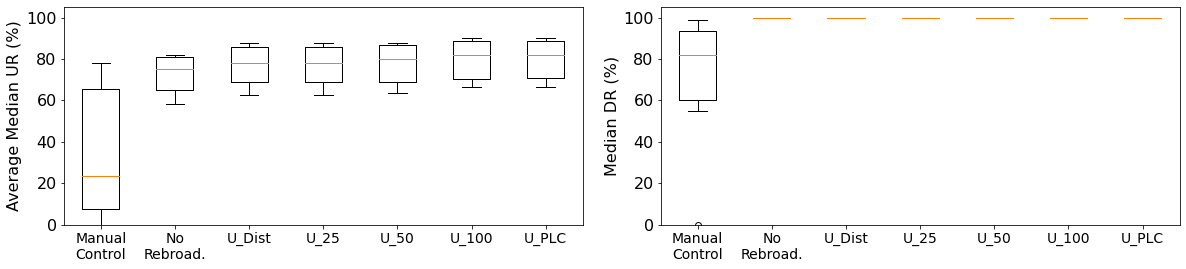

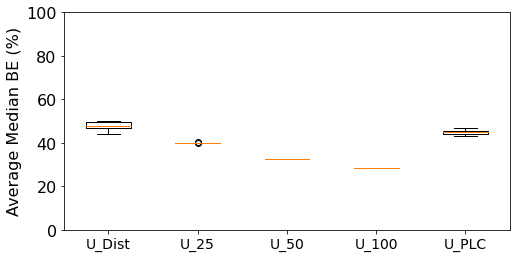

In [4]:
# fig, ax = plt.subplots(figsize=(14, 6))
# plt.rcParams.update({'font.size': 16, 'xtick.labelsize':'small'})
# for i in range(len(CASES)):
#     plt.plot(["Manual Control\n(No Mitigation)", "Waypoint Control\n(No Rebroadcasting)", "Distance-Based", "PLCB", "Fixed Probability", "PLCB "], 
#              [manual_90[i], waypoint_90[i], dv_90[i], pm_90[i], fp_90[i], pm_gcs_90[i]], '-o')
# plt.legend(["UAV 1", "UAV 2", "UAV 3", "MANET 1", "MANET 2", "MANET 3"], fontsize=12, loc='upper left')
# plt.ylabel("Percentage (%)")
# # plt.xlabel('',fontsize=12)
# plt.ylim(0,100)
# plt.text(0.33, -0.2, "| ---------------------- Only UAV Rebroadcasting ---------------------- |", transform=ax.transAxes, fontsize=14)
# plt.text(0.87, -0.2, "   With GCS & UAV   \n|- Rebroadcasting -|", transform=ax.transAxes, fontsize=14)
# plt.text(0.33, -0.3, "| ---------------------- Waypoint Control With Packet Rebroadcasting ---------------------- |", transform=ax.transAxes, fontsize=14)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 4))
plt.rcParams.update({'font.size': 16, 'xtick.labelsize':'medium'})
# for i in range(len(CASES)):
#     ax1.plot(["Manual\nControl", "Waypoint\nControl\nOnly", "Distance-\nBased", "Fixed\nProbability", "PLCB+"], 
#              [manual_med_rel[i], waypoint_med_rel[i], dv_med_rel[i], fp_med_rel[i], pm_gcs_med_rel[i]], '-o')
ax1.boxplot([manual_med_rel, waypoint_med_rel, dv_med_rel, fp_25_med_rel, fp_50_med_rel, fp_100_med_rel, pm_med_rel], showmeans=False, 
            labels=["Manual\nControl", "No\nRebroad.", "U_Dist", "U_25", "U_50", "U_100", "U_PLC"])
ax1.set_ylabel("Average Median UR (%)")
ax1.set_ylim(0,105)
ax1.set_xticklabels(["Manual\nControl", "No\nRebroad.", "U_Dist", "U_25", "U_50", "U_100", "U_PLC"], fontsize=14)
# plt.text(0.4, -0.2, "| -------------- Only UAV Rebroadcasting -------------- |", transform=ax.transAxes, fontsize=14)
# plt.text(0.84, -0.2, "   With GCS & UAV   \n|- Rebroadcasting -|", transform=ax.transAxes, fontsize=14)
# plt.text(0.4, -0.3, "| ------------------- Waypoint Control With Rebroadcasting ------------------- |", transform=ax.transAxes, fontsize=14)

# for i in range(len(CASES)):
#     ax2.plot(["Manual\nControl", "Waypoint\nControl\nOnly", "Distance-\nBased", "Fixed\nProbability", "PLCB+"], 
#              [manual_med_ul_rel[i], waypoint_med_ul_rel[i], dv_med_ul_rel[i], fp_med_ul_rel[i], pm_gcs_med_ul_rel[i]], '-o')
ax2.boxplot([manual_med_ul_rel, waypoint_med_ul_rel, dv_med_ul_rel, fp_25_med_ul_rel, fp_50_med_ul_rel, fp_100_med_ul_rel, pm_med_ul_rel], showmeans=False, 
            labels=["Manual\nControl", "No\nRebroad.", "U_Dist", "U_25", "U_50", "U_100", "U_PLC"])
ax2.set_ylabel("Median DR (%)")
ax2.set_ylim(0,105)
ax2.set_xticklabels(["Manual\nControl", "No\nRebroad.", "U_Dist", "U_25", "U_50", "U_100", "U_PLC"], fontsize=14)
# plt.text(0.4, -0.2, "| -------------- Only UAV Rebroadcasting -------------- |", transform=ax.transAxes, fontsize=14)
# plt.text(0.84, -0.2, "   With GCS & UAV   \n|- Rebroadcasting -|", transform=ax.transAxes, fontsize=14)
# plt.text(0.4, -0.3, "| -------------- Waypoint Control With Packet Rebroadcasting -------------- |", transform=ax.transAxes, fontsize=14)
# plt.legend( ["UAV 1", "UAV 2", "UAV 3", "MANET 1", "MANET 2", "MANET 3"], bbox_to_anchor=(-0.35, 1.1, 1, 0.2), loc="lower right", fontsize=14, ncol=6) 
plt.subplots_adjust(wspace=0.15)

fig, ax = plt.subplots(figsize=(8, 4))
plt.rcParams.update({'font.size': 16, 'xtick.labelsize':'medium'})
# for i in range(len(CASES)):
#     plt.plot(["Distance-Based", "Fixed Probability", "PLCB+"], 
#              [dv_med_uprr[i], fp_med_uprr[i], pm_gcs_med_uprr[i]], '-o')
plt.boxplot([dv_med_uprr, fp_25_med_uprr, fp_50_med_uprr, fp_100_med_uprr, pm_med_uprr], showmeans=False, 
            labels=["U_Dist", "U_25", "U_50", "U_100", "U_PLC"])
plt.ylabel("Average Median BE (%)")
plt.ylim(0,100)
plt.xticks(fontsize=14)
# plt.xlim([-0.15,4.15])
# plt.text(-0.02, -0.2, "| --------------------------- Only UAV Rebroadcasting --------------------------- |", transform=ax.transAxes, fontsize=14)
# plt.text(0.83, -0.2, "   With GCS & UAV   \n|- Rebroadcasting -|", transform=ax.transAxes, fontsize=14)
# plt.legend( ["UAV 1", "UAV 2", "UAV 3", "MANET 1", "MANET 2", "MANET 3"], bbox_to_anchor=(0, 1.1, 1, 0.2), loc="lower center", fontsize=14, borderaxespad=0, ncol=6) 

In [12]:
# Print values for table
# Paste the cell output to NotePad, then copy paste to excel

# print("Percent > 90%")
# for i in range(len(CASES)):
#     print("{},{},{},{},{},{}".format(manual_90[i], waypoint_90[i], dv_90[i], fp_90[i], pm_90[i], pm_gcs_90[i]))

print("Median DL Rel")
for i in range(len(CASES)):
    print("{},{},{},{},{},{},{}".format(manual_med_rel[i], waypoint_med_rel[i], dv_med_rel[i], fp_25_med_rel[i], fp_50_med_rel[i], fp_100_med_rel[i], pm_med_rel[i]))

print("Median UL Rel")
for i in range(len(CASES)):
    print("{},{},{},{},{},{},{}".format(manual_med_ul_rel[i], waypoint_med_ul_rel[i], dv_med_ul_rel[i], fp_25_med_ul_rel[i], fp_50_med_ul_rel[i], fp_100_med_ul_rel[i], pm_med_ul_rel[i]))

print("Median UPRR")
for i in range(len(CASES)):
    print("{},{},{},{},{}".format(dv_med_uprr[i], fp_25_med_uprr[i], fp_50_med_uprr[i], fp_100_med_uprr[i], pm_med_uprr[i]))

Median DL Rel
78.03565370598415,81.91699604743084,87.5,87.5,87.5,90.0,90.0
5.639824630426853,81.7471590909091,87.5,87.5,87.5,89.03508771929825,88.88888888888889
0.0,77.65151515151516,81.25,81.46306818181819,84.688995215311,87.2961956521739,87.5
75.58342562075413,72.72727272727273,75.0,75.0,75.0,76.44156346749226,76.47058823529412
34.46392011999279,62.58223684210526,66.66666666666666,66.66666666666666,66.66666666666666,68.50328947368422,68.70888157894737
12.83009658063768,58.062513847522496,62.5,62.5,63.63636363636363,66.66666666666666,66.66666666666666
Median UL Rel
75.41774903738094,100.0,100.0,100.0,100.0,100.0,100.0
55.04250420261797,100.0,100.0,100.0,100.0,100.0,100.0
0.0,100.0,100.0,100.0,100.0,100.0,100.0
98.72753297241984,100.0,100.0,100.0,100.0,100.0,100.0
94.96212805520182,100.0,100.0,100.0,100.0,100.0,100.0
88.44107350917612,100.0,100.0,100.0,100.0,100.0,100.0
Median UPRR
44.19741756351663,39.65155935155474,32.27651080794409,28.18928467365967,46.69783802333562
46.573212943151

#### For With GCS

In [3]:
# Plot Median DL Reliability and Media UPRR

TH_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_PLC_{}_Interference_new"
DV_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Dist_{}_Interference_new"
FP_25_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed25_{}_Interference_new"
FP_50_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed50_{}_Interference_new"
FP_100_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed100_{}_Interference_new"
CASES = ["uav_scenario_0_processed", "uav_scenario_1_processed", "uav_scenario_2_processed",
         "manet_scenario_1_processed", "manet_scenario_a_processed", "manet_scenario_2_processed"]
MAX_RUN_NUM = 499 # Run num starts at 0
START_RUN_NUM = 0
END_RUN_NUM = 499
dmax_df = pd.read_csv("/home/research-student/omnet-fanet/data-processing-scripts/manual_control_max_hdist/Dmax_RelTh999_Simulated_Reliability_v3_10e5.csv")
SWITCH_DETAILS = "/home/research-student/omnet-fanet/data-processing-scripts/journal_3_scripts/obj3_scenario_script_new/{}/Switch_Details.csv"
bitrate_2_usi_index = {6.5: 0, 13: 1, 19.5: 2, 26: 3, 39: 4, 52: 5, 58.5: 6, 65: 7}

pm_gcs_med_rel = []
fp_25_gcs_med_rel = []
fp_50_gcs_med_rel = []
fp_100_gcs_med_rel = []
dv_gcs_med_rel = []

pm_gcs_med_ul_rel = []
fp_25_gcs_med_ul_rel = []
fp_50_gcs_med_ul_rel = []
fp_100_gcs_med_ul_rel = []
dv_gcs_med_ul_rel = []

pm_gcs_med_uprr = []
fp_25_gcs_med_uprr = []
fp_50_gcs_med_uprr = []
fp_100_gcs_med_uprr = []
dv_gcs_med_uprr = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"

    """ Compile without filtering runs that switched too late (1 sec away from max time based on D_max) """
    # pm_gcs_df = compile_results(TH_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # fp_25_gcs_df = compile_results(FP_25_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # fp_50_gcs_df = compile_results(FP_50_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # fp_100_gcs_df = compile_results(FP_100_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # dv_gcs_df = compile_results(DV_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM)
    '''For Custom Run Num Range'''
    pm_gcs_df = compile_results_range(TH_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    fp_25_gcs_df = compile_results_range(FP_25_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    fp_50_gcs_df = compile_results_range(FP_50_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    fp_100_gcs_df = compile_results_range(FP_100_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    dv_gcs_df = compile_results_range(DV_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)

    """ Compile, filtering runs that switched too late (1 sec away from max time based on D_max) """
    # switch_details_df = pd.read_csv(SWITCH_DETAILS.format(case[0:-10]))
    # switch_time_df = switch_details_df[["GCS_Switch_Time", "GW_Switch_Time", "UAV_0_Switch_Time", "UAV_2_Switch_Time", "UAV_3_Switch_Time", "UAV_4_Switch_Time",
    #                                     "UAV_5_Switch_Time", "UAV_6_Switch_Time", "UAV_7_Switch_Time"]]
    # switch_time_df_notna = switch_details_df.loc[~switch_time_df.isnull().all(axis=1)]
    # max_time = []
    # for row in switch_time_df_notna.itertuples():
    #     usi = row.USI
    #     mcs_index = bitrate_2_usi_index[row.Bit_Rate]
    #     height = row.Height
    #     speed = row.UAV_Speed
    #     D_max = dmax_df.loc[(dmax_df["MCS_Index"]==mcs_index) & (dmax_df["USI"]==usi) & (dmax_df["Height"]==height)]["D_max"].values[0]
    #     max_time.append(D_max/speed)
    # switch_time_df_notna["Max_Time"] = max_time
    # switch_time_df_notna["Min_Switch_Time"] = switch_time_df_notna[["GCS_Switch_Time", "GW_Switch_Time", "UAV_0_Switch_Time", "UAV_2_Switch_Time", "UAV_3_Switch_Time", "UAV_4_Switch_Time",
    #                                                 "UAV_5_Switch_Time", "UAV_6_Switch_Time", "UAV_7_Switch_Time"]].min(axis=1)
    # filter_df = switch_time_df_notna.loc[switch_time_df_notna["Min_Switch_Time"] > (switch_time_df_notna["Max_Time"]-1)]
    # manual_df = compile_results_filtered(MANUAL_PATH.format(intf_type), [case], MAX_RUN_NUM, filter_df, "Simulation_Results.csv")
    # waypoint_df = compile_results_filtered(WAYPOINT_PATH.format(intf_type), [case], MAX_RUN_NUM, filter_df)
    # fp_df = compile_results_filtered(FP_PATH.format(intf_type), [case], MAX_RUN_NUM, filter_df)
    # dv_df = compile_results_filtered(DV_PATH.format(intf_type), [case], MAX_RUN_NUM, filter_df)
    # pm_df = compile_results_filtered(TH_PATH.format(intf_type), [case], MAX_RUN_NUM, filter_df)
    # pm_gcs_df = compile_results_filtered(TH_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, filter_df)

    '''Temporary resolution to error in processing script introducing redundant columns'''
    try:
        pm_gcs_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        fp_25_gcs_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        fp_50_gcs_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        fp_100_gcs_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        dv_gcs_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass

    '''Filter out runs where there are NaN reliability (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    pm_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_25_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_50_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_100_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    dv_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)

    pm_gcs_df.reset_index(inplace=True)
    fp_25_gcs_df.reset_index(inplace=True)
    fp_50_gcs_df.reset_index(inplace=True)
    fp_100_gcs_df.reset_index(inplace=True)
    dv_gcs_df.reset_index(inplace=True)

    runs_nan = (pm_gcs_df.isnull().any(axis=1).to_numpy()) | (dv_gcs_df.isnull().any(axis=1).to_numpy()) | \
                (fp_25_gcs_df.isnull().any(axis=1).to_numpy()) | (fp_50_gcs_df.isnull().any(axis=1).to_numpy()) | (fp_100_gcs_df.isnull().any(axis=1).to_numpy()) 
    pm_gcs_df_fil = pm_gcs_df.loc[~(runs_nan)]
    fp_25_gcs_df_fil = fp_25_gcs_df.loc[~(runs_nan)]
    fp_50_gcs_df_fil = fp_50_gcs_df.loc[~(runs_nan)]
    fp_100_gcs_df_fil = fp_100_gcs_df.loc[~(runs_nan)]
    dv_gcs_df_fil = dv_gcs_df.loc[~(runs_nan)]

    '''Get Median DL Reliability'''
    # pm_gcs_dl_rel = np.concatenate((pm_gcs_df_fil["Reliability_UAV_0"].values*100, pm_gcs_df_fil["Reliability_UAV_1"].values*100, pm_gcs_df_fil["Reliability_UAV_2"].values*100, pm_gcs_df_fil["Reliability_UAV_3"].values*100,
    #                             pm_gcs_df_fil["Reliability_UAV_4"].values*100, pm_gcs_df_fil["Reliability_UAV_5"].values*100, pm_gcs_df_fil["Reliability_UAV_6"].values*100, pm_gcs_df_fil["Reliability_UAV_7"].values*100))
    pm_gcs_dl_rel = np.mean((pm_gcs_df_fil["Reliability_UAV_0"].median()*100, pm_gcs_df_fil["Reliability_UAV_1"].median()*100, pm_gcs_df_fil["Reliability_UAV_2"].median()*100, pm_gcs_df_fil["Reliability_UAV_3"].median()*100,
                                pm_gcs_df_fil["Reliability_UAV_4"].median()*100, pm_gcs_df_fil["Reliability_UAV_5"].median()*100, pm_gcs_df_fil["Reliability_UAV_6"].median()*100, pm_gcs_df_fil["Reliability_UAV_7"].median()*100))
    fp_25_gcs_dl_rel = np.mean((fp_25_gcs_df_fil["Reliability_UAV_0"].median()*100, fp_25_gcs_df_fil["Reliability_UAV_1"].median()*100, fp_25_gcs_df_fil["Reliability_UAV_2"].median()*100, fp_25_gcs_df_fil["Reliability_UAV_3"].median()*100,
                                fp_25_gcs_df_fil["Reliability_UAV_4"].median()*100, fp_25_gcs_df_fil["Reliability_UAV_5"].median()*100, fp_25_gcs_df_fil["Reliability_UAV_6"].median()*100, fp_25_gcs_df_fil["Reliability_UAV_7"].median()*100))
    fp_50_gcs_dl_rel = np.mean((fp_50_gcs_df_fil["Reliability_UAV_0"].median()*100, fp_50_gcs_df_fil["Reliability_UAV_1"].median()*100, fp_50_gcs_df_fil["Reliability_UAV_2"].median()*100, fp_50_gcs_df_fil["Reliability_UAV_3"].median()*100,
                                fp_50_gcs_df_fil["Reliability_UAV_4"].median()*100, fp_50_gcs_df_fil["Reliability_UAV_5"].median()*100, fp_50_gcs_df_fil["Reliability_UAV_6"].median()*100, fp_50_gcs_df_fil["Reliability_UAV_7"].median()*100))
    fp_100_gcs_dl_rel = np.mean((fp_100_gcs_df_fil["Reliability_UAV_0"].median()*100, fp_100_gcs_df_fil["Reliability_UAV_1"].median()*100, fp_100_gcs_df_fil["Reliability_UAV_2"].median()*100, fp_100_gcs_df_fil["Reliability_UAV_3"].median()*100,
                                fp_100_gcs_df_fil["Reliability_UAV_4"].median()*100, fp_100_gcs_df_fil["Reliability_UAV_5"].median()*100, fp_100_gcs_df_fil["Reliability_UAV_6"].median()*100, fp_100_gcs_df_fil["Reliability_UAV_7"].median()*100))
    dv_gcs_dl_rel = np.mean((dv_gcs_df_fil["Reliability_UAV_0"].median()*100, dv_gcs_df_fil["Reliability_UAV_1"].median()*100, dv_gcs_df_fil["Reliability_UAV_2"].median()*100, dv_gcs_df_fil["Reliability_UAV_3"].median()*100,
                                dv_gcs_df_fil["Reliability_UAV_4"].median()*100, dv_gcs_df_fil["Reliability_UAV_5"].median()*100, dv_gcs_df_fil["Reliability_UAV_6"].median()*100, dv_gcs_df_fil["Reliability_UAV_7"].median()*100))
    
    pm_gcs_med_rel.append(pm_gcs_dl_rel)
    fp_25_gcs_med_rel.append(fp_25_gcs_dl_rel)
    fp_50_gcs_med_rel.append(fp_50_gcs_dl_rel)
    fp_100_gcs_med_rel.append(fp_100_gcs_dl_rel)
    dv_gcs_med_rel.append(dv_gcs_dl_rel)

    '''Get Median UL Reliability'''
    pm_gcs_med_ul_rel.append(pm_gcs_df_fil["Total_Reliability_UL"].median() * 100)
    fp_25_gcs_med_ul_rel.append(fp_25_gcs_df_fil["Total_Reliability_UL"].median() * 100)
    fp_50_gcs_med_ul_rel.append(fp_50_gcs_df_fil["Total_Reliability_UL"].median() * 100)
    fp_100_gcs_med_ul_rel.append(fp_100_gcs_df_fil["Total_Reliability_UL"].median() * 100)
    dv_gcs_med_ul_rel.append(dv_gcs_df_fil["Total_Reliability_UL"].median() * 100)

    '''Get Median UPRR'''
    # pm_gcs_dl_uprr = np.concatenate((pm_gcs_df_fil["UPRR_UAV_0"].values*100, pm_gcs_df_fil["UPRR_UAV_1"].values*100, pm_gcs_df_fil["UPRR_UAV_2"].values*100, pm_gcs_df_fil["UPRR_UAV_3"].values*100,
    #                             pm_gcs_df_fil["UPRR_UAV_4"].values*100, pm_gcs_df_fil["UPRR_UAV_5"].values*100, pm_gcs_df_fil["UPRR_UAV_6"].values*100, pm_gcs_df_fil["UPRR_UAV_7"].values*100))
    pm_gcs_dl_uprr = np.mean((pm_gcs_df_fil["UPRR_UAV_0"].median()*100, pm_gcs_df_fil["UPRR_UAV_1"].median()*100, pm_gcs_df_fil["UPRR_UAV_2"].median()*100, pm_gcs_df_fil["UPRR_UAV_3"].median()*100,
                                pm_gcs_df_fil["UPRR_UAV_4"].median()*100, pm_gcs_df_fil["UPRR_UAV_5"].median()*100, pm_gcs_df_fil["UPRR_UAV_6"].median()*100, pm_gcs_df_fil["UPRR_UAV_7"].median()*100))
    fp_25_gcs_dl_uprr = np.mean((fp_25_gcs_df_fil["UPRR_UAV_0"].median()*100, fp_25_gcs_df_fil["UPRR_UAV_1"].median()*100, fp_25_gcs_df_fil["UPRR_UAV_2"].median()*100, fp_25_gcs_df_fil["UPRR_UAV_3"].median()*100,
                                fp_25_gcs_df_fil["UPRR_UAV_4"].median()*100, fp_25_gcs_df_fil["UPRR_UAV_5"].median()*100, fp_25_gcs_df_fil["UPRR_UAV_6"].median()*100, fp_25_gcs_df_fil["UPRR_UAV_7"].median()*100))
    fp_50_gcs_dl_uprr = np.mean((fp_50_gcs_df_fil["UPRR_UAV_0"].median()*100, fp_50_gcs_df_fil["UPRR_UAV_1"].median()*100, fp_50_gcs_df_fil["UPRR_UAV_2"].median()*100, fp_50_gcs_df_fil["UPRR_UAV_3"].median()*100,
                                fp_50_gcs_df_fil["UPRR_UAV_4"].median()*100, fp_50_gcs_df_fil["UPRR_UAV_5"].median()*100, fp_50_gcs_df_fil["UPRR_UAV_6"].median()*100, fp_50_gcs_df_fil["UPRR_UAV_7"].median()*100))
    fp_100_gcs_dl_uprr = np.mean((fp_100_gcs_df_fil["UPRR_UAV_0"].median()*100, fp_100_gcs_df_fil["UPRR_UAV_1"].median()*100, fp_100_gcs_df_fil["UPRR_UAV_2"].median()*100, fp_100_gcs_df_fil["UPRR_UAV_3"].median()*100,
                                fp_100_gcs_df_fil["UPRR_UAV_4"].median()*100, fp_100_gcs_df_fil["UPRR_UAV_5"].median()*100, fp_100_gcs_df_fil["UPRR_UAV_6"].median()*100, fp_100_gcs_df_fil["UPRR_UAV_7"].median()*100))
    dv_gcs_dl_uprr = np.mean((dv_gcs_df_fil["UPRR_UAV_0"].median()*100, dv_gcs_df_fil["UPRR_UAV_1"].median()*100, dv_gcs_df_fil["UPRR_UAV_2"].median()*100, dv_gcs_df_fil["UPRR_UAV_3"].median()*100,
                                dv_gcs_df_fil["UPRR_UAV_4"].median()*100, dv_gcs_df_fil["UPRR_UAV_5"].median()*100, dv_gcs_df_fil["UPRR_UAV_6"].median()*100, dv_gcs_df_fil["UPRR_UAV_7"].median()*100))
    pm_gcs_med_uprr.append(pm_gcs_dl_uprr)
    fp_25_gcs_med_uprr.append(fp_25_gcs_dl_uprr)
    fp_50_gcs_med_uprr.append(fp_50_gcs_dl_uprr)
    fp_100_gcs_med_uprr.append(fp_100_gcs_dl_uprr)
    dv_gcs_med_uprr.append(dv_gcs_dl_uprr)



KeyboardInterrupt: 

(array([1, 2, 3, 4, 5]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

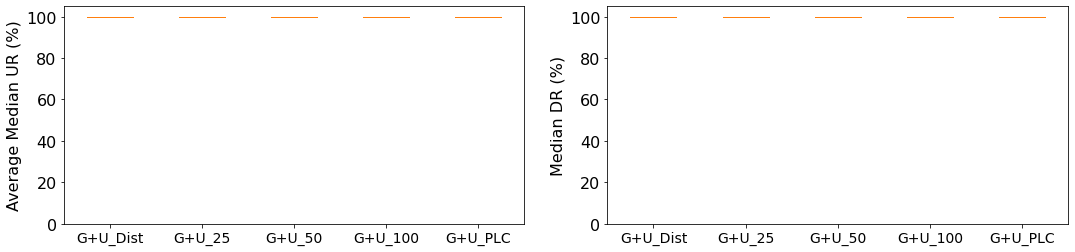

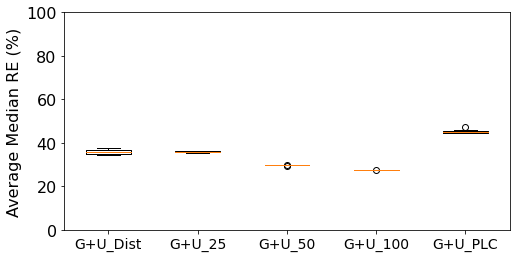

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 4))
plt.rcParams.update({'font.size': 16, 'xtick.labelsize':'medium'})
ax1.boxplot([dv_gcs_med_rel, fp_25_gcs_med_rel, fp_50_gcs_med_rel, fp_100_gcs_med_rel, pm_gcs_med_rel], showmeans=False, 
            labels=["G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"])
ax1.set_ylabel("Average Median UR (%)")
ax1.set_ylim(0,105)
ax1.set_xticklabels(["G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"], fontsize=14)

ax2.boxplot([dv_gcs_med_ul_rel, fp_25_gcs_med_ul_rel, fp_50_gcs_med_ul_rel, fp_100_gcs_med_ul_rel, pm_gcs_med_ul_rel], showmeans=False, 
            labels=["G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"])
ax2.set_ylabel("Median DR (%)")
ax2.set_ylim(0,105)
ax2.set_xticklabels(["G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"], fontsize=14)
plt.subplots_adjust(wspace=0.18)

fig, ax = plt.subplots(figsize=(8, 4))
plt.rcParams.update({'font.size': 16, 'xtick.labelsize':'medium'})
plt.boxplot([dv_gcs_med_uprr, fp_25_gcs_med_uprr, fp_50_gcs_med_uprr, fp_100_gcs_med_uprr, pm_gcs_med_uprr], whis=[0, 100], showmeans=False, 
            labels=["G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"])
plt.ylabel("Average Median RE (%)")
plt.ylim(0,100)
plt.xticks(fontsize=14) 

In [8]:
# Print values for table
# Paste the cell output to NotePad, then copy paste to excel
print("Median DL Rel")
for i in range(len(CASES)):
    print("{},{},{},{},{}".format(dv_gcs_med_rel[i], fp_25_gcs_med_rel[i], fp_50_gcs_med_rel[i], fp_100_gcs_med_rel[i], pm_gcs_med_rel[i]))

print("Median UL Rel")
for i in range(len(CASES)):
    print("{},{},{},{},{}".format(dv_gcs_med_ul_rel[i], fp_25_gcs_med_ul_rel[i], fp_50_gcs_med_ul_rel[i], fp_100_gcs_med_ul_rel[i], pm_gcs_med_ul_rel[i]))

print("Median UPRR")
for i in range(len(CASES)):
    print("{},{},{},{},{}".format(dv_gcs_med_uprr[i], fp_25_gcs_med_uprr[i], fp_50_gcs_med_uprr[i], fp_100_gcs_med_uprr[i], pm_gcs_med_uprr[i]))

Median DL Rel
100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0
Median UL Rel
100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0
Median UPRR
34.22960158596552,35.483870967741936,29.418329831932766,27.515304847576214,47.06932773109243
34.782608695652165,35.537634408602145,29.67997294169169,27.500000000000004,45.00686813186813
35.41795748418302,35.537634408602145,29.707294109468023,27.329816017316013,44.37293217535153
35.96436403508772,35.98341557017544,29.691699171998085,27.50452898550725,45.65421293682162
36.75532735780337,36.36363636363636,29.7448567970956,27.55392438009183,44.80029168774847
37.33609623033647,36.385489510489506,29.821133956740912,27.528223094828423,44.44444444444444


### Plot Rebroadcast Efficiency (Per USI)

#### For No GCS

In [18]:
# Plot Median DL Reliability and Media UPRR

DV_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Dist_{}_Interference_new"
FP_25_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed25_{}_Interference_new"
FP_50_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed50_{}_Interference_new"
FP_100_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed100_{}_Interference_new"
TH_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_PLC_{}_Interference_new"
CASES = ["uav_scenario_0_processed", "uav_scenario_1_processed", "uav_scenario_2_processed",
         "manet_scenario_1_processed", "manet_scenario_a_processed", "manet_scenario_2_processed"]
MAX_RUN_NUM = 499 # Run num starts at 0
START_RUN_NUM = 0
END_RUN_NUM = 499
usi_list = ["10", "20", "66.7", "100"]

fp_25_med_uprr = []
fp_50_med_uprr = []
fp_100_med_uprr = []
dv_med_uprr = []
pm_med_uprr = []
pm_gcs_med_uprr = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"

    """ Compile without filtering runs that switched too late (1 sec away from max time based on D_max) """
    # fp_25_df = compile_results(FP_25_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # fp_50_df = compile_results(FP_50_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # fp_100_df = compile_results(FP_100_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # dv_df = compile_results(DV_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # pm_df = compile_results(TH_PATH.format(intf_type), [case], MAX_RUN_NUM)
    '''For Custom Run Num Range'''
    fp_25_df = compile_results_range(FP_25_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    fp_50_df = compile_results_range(FP_50_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    fp_100_df = compile_results_range(FP_100_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    dv_df = compile_results_range(DV_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    pm_df = compile_results_range(TH_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)

    '''Temporary resolution to error in processing script introducing redundant columns'''
    try:
        fp_25_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        fp_50_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        fp_100_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        dv_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        pm_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass

    '''Filter out runs where there are NaN reliability (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    fp_25_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_50_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_100_df.sort_values(by=["Scenario", "Run"], inplace=True)
    dv_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_df.sort_values(by=["Scenario", "Run"], inplace=True)
    # pm_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)

    fp_25_df.reset_index(inplace=True)
    fp_50_df.reset_index(inplace=True)
    fp_100_df.reset_index(inplace=True)
    dv_df.reset_index(inplace=True)
    pm_df.reset_index(inplace=True)
    # pm_gcs_df.reset_index(inplace=True)

    # runs_nan = (fp_25_df.isnull().any(axis=1).to_numpy()) | (fp_50_df.isnull().any(axis=1).to_numpy()) | (fp_100_df.isnull().any(axis=1).to_numpy()) | (dv_df.isnull().any(axis=1).to_numpy()) | (pm_df.isnull().any(axis=1).to_numpy())
    # fp_25_df_fil = fp_25_df.loc[~(runs_nan)]
    # fp_50_df_fil = fp_50_df.loc[~(runs_nan)]
    # fp_100_df_fil = fp_100_df.loc[~(runs_nan)]
    # dv_df_fil = dv_df.loc[~(runs_nan)]
    # pm_df_fil = pm_df.loc[~(runs_nan)]

    fp_25_df_fil = fp_25_df.loc[~(fp_25_df.isnull().any(axis=1).to_numpy())]
    fp_50_df_fil = fp_50_df.loc[~(fp_50_df.isnull().any(axis=1).to_numpy())]
    fp_100_df_fil = fp_100_df.loc[~(fp_100_df.isnull().any(axis=1).to_numpy())]
    dv_df_fil = dv_df.loc[~(dv_df.isnull().any(axis=1).to_numpy())]
    pm_df_fil = pm_df.loc[~(pm_df.isnull().any(axis=1).to_numpy())]

    '''For each scheme, For each USI, Get Median UPRR'''
    fp_25_uprr_usi = []
    fp_50_uprr_usi = []
    fp_100_uprr_usi = []
    dv_uprr_usi = []
    pm_uprr_usi = []

    for usi in usi_list:
        dv_df_usi = dv_df_fil.loc[(dv_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        dv_uprr_usi.append(np.mean((dv_df_usi["UPRR_UAV_0"].median()*100, dv_df_usi["UPRR_UAV_1"].median()*100, dv_df_usi["UPRR_UAV_2"].median()*100, dv_df_usi["UPRR_UAV_3"].median()*100,
                                    dv_df_usi["UPRR_UAV_4"].median()*100, dv_df_usi["UPRR_UAV_5"].median()*100, dv_df_usi["UPRR_UAV_6"].median()*100, dv_df_usi["UPRR_UAV_7"].median()*100)))
        fp_25_df_usi = fp_25_df_fil.loc[(fp_25_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_25_uprr_usi.append(np.mean((fp_25_df_usi["UPRR_UAV_0"].median()*100, fp_25_df_usi["UPRR_UAV_1"].median()*100, fp_25_df_usi["UPRR_UAV_2"].median()*100, fp_25_df_usi["UPRR_UAV_3"].median()*100,
                                    fp_25_df_usi["UPRR_UAV_4"].median()*100, fp_25_df_usi["UPRR_UAV_5"].median()*100, fp_25_df_usi["UPRR_UAV_6"].median()*100, fp_25_df_usi["UPRR_UAV_7"].median()*100)))
        fp_50_df_usi = fp_50_df_fil.loc[(fp_50_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_50_uprr_usi.append(np.mean((fp_50_df_usi["UPRR_UAV_0"].median()*100, fp_50_df_usi["UPRR_UAV_1"].median()*100, fp_50_df_usi["UPRR_UAV_2"].median()*100, fp_50_df_usi["UPRR_UAV_3"].median()*100,
                                    fp_50_df_usi["UPRR_UAV_4"].median()*100, fp_50_df_usi["UPRR_UAV_5"].median()*100, fp_50_df_usi["UPRR_UAV_6"].median()*100, fp_50_df_usi["UPRR_UAV_7"].median()*100)))
        fp_100_df_usi = fp_100_df_fil.loc[(fp_100_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_100_uprr_usi.append(np.mean((fp_100_df_usi["UPRR_UAV_0"].median()*100, fp_100_df_usi["UPRR_UAV_1"].median()*100, fp_100_df_usi["UPRR_UAV_2"].median()*100, fp_100_df_usi["UPRR_UAV_3"].median()*100,
                                    fp_100_df_usi["UPRR_UAV_4"].median()*100, fp_100_df_usi["UPRR_UAV_5"].median()*100, fp_100_df_usi["UPRR_UAV_6"].median()*100, fp_100_df_usi["UPRR_UAV_7"].median()*100)))
        pm_df_usi = pm_df_fil.loc[(pm_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        pm_uprr_usi.append(np.mean((pm_df_usi["UPRR_UAV_0"].median()*100, pm_df_usi["UPRR_UAV_1"].median()*100, pm_df_usi["UPRR_UAV_2"].median()*100, pm_df_usi["UPRR_UAV_3"].median()*100,
                                    pm_df_usi["UPRR_UAV_4"].median()*100, pm_df_usi["UPRR_UAV_5"].median()*100, pm_df_usi["UPRR_UAV_6"].median()*100, pm_df_usi["UPRR_UAV_7"].median()*100)))
    
    fp_25_med_uprr.append(fp_25_uprr_usi)
    fp_50_med_uprr.append(fp_50_uprr_usi)
    fp_100_med_uprr.append(fp_100_uprr_usi)
    dv_med_uprr.append(dv_uprr_usi)
    pm_med_uprr.append(pm_uprr_usi)

fp_25_med_uprr_box = [[x[i] for x in fp_25_med_uprr] for i in range(4)]
fp_50_med_uprr_box = [[x[i] for x in fp_50_med_uprr] for i in range(4)]
fp_100_med_uprr_box = [[x[i] for x in fp_100_med_uprr] for i in range(4)]
dv_med_uprr_box = [[x[i] for x in dv_med_uprr] for i in range(4)]
pm_med_uprr_box = [[x[i] for x in pm_med_uprr] for i in range(4)]

for j in range(4):
    print("USI: {}".format(usi_list[j]))
    for i in range(len(CASES)):
        print("{},{},{},{},{}".format(dv_med_uprr_box[j][i], fp_25_med_uprr_box[j][i], fp_50_med_uprr_box[j][i], fp_100_med_uprr_box[j][i], pm_med_uprr_box[j][i]))




USI: 10
56.448412698412696,41.940789473684205,33.33333333333333,28.943452380952383,45.93531468531468
60.0,43.41517857142857,34.88251278772378,30.685618729096987,45.93240093240093
60.0,44.44444444444444,35.06553708439897,30.685618729096987,45.32828282828282
60.0,42.763157894736835,33.33333333333333,29.211406784936194,44.357638888888886
60.88942307692308,42.85714285714285,33.33333333333333,30.0,43.52678571428571
62.1875,43.13616071428571,33.33333333333333,30.0,42.85714285714285
USI: 20
44.1500933706816,39.24689440993788,32.069315618141715,27.903912279745597,46.68067692502533
47.26555973266498,40.0,32.44881544766678,28.1413419365722,45.51948051948051
47.27168857973811,40.19428113178113,32.57893117285869,28.45587326719402,45.593030872636135
47.05882352941176,39.446658830604164,32.10846560846561,27.990990990990994,44.98724489795919
49.87244897959184,40.0,32.26738275955543,28.08596085266185,43.72479838709677
50.0,40.0,32.26992409867172,28.165064102564102,42.85714285714285
USI: 66.7
40.453782

(-1.0, 105.0)

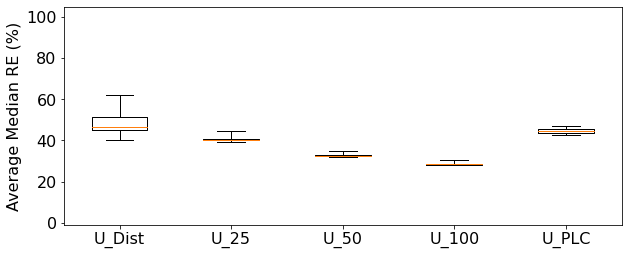

In [6]:
plt.rcParams.update({'font.size': 16, 'xtick.labelsize':'medium', 'font.family': 'sans-serif'})
fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))

# With Separate Box Plots for Each USI
# space = 0.2
# box_params = dict(widths=0.1)
# box1 = ax1.boxplot([dv_med_uprr_box[0], fp_25_med_uprr_box[0], fp_50_med_uprr_box[0], fp_100_med_uprr_box[0], pm_med_uprr_box[0]], 
#                    showmeans=False, whis=[0, 100], positions=np.arange(5)-1.5*space, 
#                    boxprops=dict(linestyle='-', linewidth=1,  color='tab:blue'), 
#                    whiskerprops=dict(linestyle='-', linewidth=1, color='tab:blue'), **box_params)
# box2 = ax1.boxplot([dv_med_uprr_box[1], fp_25_med_uprr_box[1], fp_50_med_uprr_box[1], fp_100_med_uprr_box[1], pm_med_uprr_box[1]], 
#                    showmeans=False, whis=[0, 100], positions=np.arange(5)-0.5*space,
#                    boxprops=dict(linestyle='--', linewidth=1,  color='tab:orange'), 
#                    whiskerprops=dict(linestyle='--', linewidth=1, color='tab:orange'), **box_params)
# box3 = ax1.boxplot([dv_med_uprr_box[2], fp_25_med_uprr_box[2], fp_50_med_uprr_box[2], fp_100_med_uprr_box[2], pm_med_uprr_box[2]], 
#                    showmeans=False, whis=[0, 100], positions=np.arange(5)+0.5*space,
#                    boxprops=dict(linestyle=':', linewidth=1,  color='tab:green'), 
#                    whiskerprops=dict(linestyle=':', linewidth=1, color='tab:green'), **box_params)
# box4 = ax1.boxplot([dv_med_uprr_box[3], fp_25_med_uprr_box[3], fp_50_med_uprr_box[3], fp_100_med_uprr_box[3], pm_med_uprr_box[3]], 
#                    showmeans=False, whis=[0, 100], positions=np.arange(5)+1.5*space,
#                    boxprops=dict(linestyle='dashdot', linewidth=1,  color='tab:red'), 
#                    whiskerprops=dict(linestyle='dashdot', linewidth=1, color='tab:red'), **box_params)
# ax1.set_xticks(np.arange(5), ["U_Dist", "U_25", "U_50", "U_100", "U_PLC"], fontsize=16)
# ax1.legend((box1["boxes"][0], box2["boxes"][0], box3["boxes"][0], box4["boxes"][0]),
#                ["USI 10 ms", "USI 20 ms", "USI 66.7 ms", "USI 100 ms",], bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower center", fontsize=16, borderaxespad=0, ncol=4)

# With one box plots for results from all USIs
ax1.boxplot([[x for xs in dv_med_uprr_box for x in xs], [x for xs in fp_25_med_uprr_box for x in xs], [x for xs in fp_50_med_uprr_box for x in xs], [x for xs in fp_100_med_uprr_box for x in xs], 
             [x for xs in pm_med_uprr_box for x in xs]],
             showmeans=False, whis=[0, 100], labels=["U_Dist", "U_25", "U_50", "U_100", "U_PLC"])

ax1.set_ylabel("Average Median RE (%)")
ax1.set_ylim(-1,105)

#### For With GCS

In [ ]:
# Plot Median DL Reliability and Media UPRR

DV_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Dist_{}_Interference_new"
FP_25_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed25_{}_Interference_new"
FP_50_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed50_{}_Interference_new"
FP_100_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed100_{}_Interference_new"
TH_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_PLC_{}_Interference_new"
CASES = ["uav_scenario_0_processed", "uav_scenario_1_processed", "uav_scenario_2_processed",
         "manet_scenario_1_processed", "manet_scenario_a_processed", "manet_scenario_2_processed"]
MAX_RUN_NUM = 499 # Run num starts at 0
START_RUN_NUM = 0
END_RUN_NUM = 499
usi_list = ["10", "20", "66.7", "100"]

fp_25_med_uprr = []
fp_50_med_uprr = []
fp_100_med_uprr = []
dv_med_uprr = []
pm_med_uprr = []
pm_gcs_med_uprr = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"

    """ Compile without filtering runs that switched too late (1 sec away from max time based on D_max) """
    # fp_25_df = compile_results(FP_25_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # fp_50_df = compile_results(FP_50_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # fp_100_df = compile_results(FP_100_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # dv_df = compile_results(DV_PATH.format(intf_type), [case], MAX_RUN_NUM)
    # pm_df = compile_results(TH_PATH.format(intf_type), [case], MAX_RUN_NUM)
    '''For Custom Run Num Range'''
    fp_25_df = compile_results_range(FP_25_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    fp_50_df = compile_results_range(FP_50_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    fp_100_df = compile_results_range(FP_100_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    dv_df = compile_results_range(DV_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)
    pm_df = compile_results_range(TH_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM)

    '''Temporary resolution to error in processing script introducing redundant columns'''
    try:
        fp_25_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        fp_50_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        fp_100_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        dv_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        pm_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass

    '''Filter out runs where there are NaN reliability (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    fp_25_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_50_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_100_df.sort_values(by=["Scenario", "Run"], inplace=True)
    dv_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_df.sort_values(by=["Scenario", "Run"], inplace=True)
    # pm_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)

    fp_25_df.reset_index(inplace=True)
    fp_50_df.reset_index(inplace=True)
    fp_100_df.reset_index(inplace=True)
    dv_df.reset_index(inplace=True)
    pm_df.reset_index(inplace=True)
    # pm_gcs_df.reset_index(inplace=True)

    # runs_nan = (fp_25_df.isnull().any(axis=1).to_numpy()) | (fp_50_df.isnull().any(axis=1).to_numpy()) | (fp_100_df.isnull().any(axis=1).to_numpy()) | (dv_df.isnull().any(axis=1).to_numpy()) | (pm_df.isnull().any(axis=1).to_numpy())
    # fp_25_df_fil = fp_25_df.loc[~(runs_nan)]
    # fp_50_df_fil = fp_50_df.loc[~(runs_nan)]
    # fp_100_df_fil = fp_100_df.loc[~(runs_nan)]
    # dv_df_fil = dv_df.loc[~(runs_nan)]
    # pm_df_fil = pm_df.loc[~(runs_nan)]

    fp_25_df_fil = fp_25_df.loc[~(fp_25_df.isnull().any(axis=1).to_numpy())]
    fp_50_df_fil = fp_50_df.loc[~(fp_50_df.isnull().any(axis=1).to_numpy())]
    fp_100_df_fil = fp_100_df.loc[~(fp_100_df.isnull().any(axis=1).to_numpy())]
    dv_df_fil = dv_df.loc[~(dv_df.isnull().any(axis=1).to_numpy())]
    pm_df_fil = pm_df.loc[~(pm_df.isnull().any(axis=1).to_numpy())]

    '''For each scheme, For each USI, Get Median UPRR'''
    fp_25_uprr_usi = []
    fp_50_uprr_usi = []
    fp_100_uprr_usi = []
    dv_uprr_usi = []
    pm_uprr_usi = []

    for usi in ["10", "20", "66.7", "100"]:
        dv_df_usi = dv_df_fil.loc[(dv_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        dv_uprr_usi.append(np.mean((dv_df_usi["UPRR_UAV_0"].median()*100, dv_df_usi["UPRR_UAV_1"].median()*100, dv_df_usi["UPRR_UAV_2"].median()*100, dv_df_usi["UPRR_UAV_3"].median()*100,
                                    dv_df_usi["UPRR_UAV_4"].median()*100, dv_df_usi["UPRR_UAV_5"].median()*100, dv_df_usi["UPRR_UAV_6"].median()*100, dv_df_usi["UPRR_UAV_7"].median()*100)))
        fp_25_df_usi = fp_25_df_fil.loc[(fp_25_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_25_uprr_usi.append(np.mean((fp_25_df_usi["UPRR_UAV_0"].median()*100, fp_25_df_usi["UPRR_UAV_1"].median()*100, fp_25_df_usi["UPRR_UAV_2"].median()*100, fp_25_df_usi["UPRR_UAV_3"].median()*100,
                                    fp_25_df_usi["UPRR_UAV_4"].median()*100, fp_25_df_usi["UPRR_UAV_5"].median()*100, fp_25_df_usi["UPRR_UAV_6"].median()*100, fp_25_df_usi["UPRR_UAV_7"].median()*100)))
        fp_50_df_usi = fp_50_df_fil.loc[(fp_50_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_50_uprr_usi.append(np.mean((fp_50_df_usi["UPRR_UAV_0"].median()*100, fp_50_df_usi["UPRR_UAV_1"].median()*100, fp_50_df_usi["UPRR_UAV_2"].median()*100, fp_50_df_usi["UPRR_UAV_3"].median()*100,
                                    fp_50_df_usi["UPRR_UAV_4"].median()*100, fp_50_df_usi["UPRR_UAV_5"].median()*100, fp_50_df_usi["UPRR_UAV_6"].median()*100, fp_50_df_usi["UPRR_UAV_7"].median()*100)))
        fp_100_df_usi = fp_100_df_fil.loc[(fp_100_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_100_uprr_usi.append(np.mean((fp_100_df_usi["UPRR_UAV_0"].median()*100, fp_100_df_usi["UPRR_UAV_1"].median()*100, fp_100_df_usi["UPRR_UAV_2"].median()*100, fp_100_df_usi["UPRR_UAV_3"].median()*100,
                                    fp_100_df_usi["UPRR_UAV_4"].median()*100, fp_100_df_usi["UPRR_UAV_5"].median()*100, fp_100_df_usi["UPRR_UAV_6"].median()*100, fp_100_df_usi["UPRR_UAV_7"].median()*100)))
        pm_df_usi = pm_df_fil.loc[(pm_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        pm_uprr_usi.append(np.mean((pm_df_usi["UPRR_UAV_0"].median()*100, pm_df_usi["UPRR_UAV_1"].median()*100, pm_df_usi["UPRR_UAV_2"].median()*100, pm_df_usi["UPRR_UAV_3"].median()*100,
                                    pm_df_usi["UPRR_UAV_4"].median()*100, pm_df_usi["UPRR_UAV_5"].median()*100, pm_df_usi["UPRR_UAV_6"].median()*100, pm_df_usi["UPRR_UAV_7"].median()*100)))
    
    fp_25_med_uprr.append(fp_25_uprr_usi)
    fp_50_med_uprr.append(fp_50_uprr_usi)
    fp_100_med_uprr.append(fp_100_uprr_usi)
    dv_med_uprr.append(dv_uprr_usi)
    pm_med_uprr.append(pm_uprr_usi)

fp_25_med_uprr_box = [[x[i] for x in fp_25_med_uprr] for i in range(4)]
fp_50_med_uprr_box = [[x[i] for x in fp_50_med_uprr] for i in range(4)]
fp_100_med_uprr_box = [[x[i] for x in fp_100_med_uprr] for i in range(4)]
dv_med_uprr_box = [[x[i] for x in dv_med_uprr] for i in range(4)]
pm_med_uprr_box = [[x[i] for x in pm_med_uprr] for i in range(4)]

for j in range(4):
    print("USI: {}".format(usi_list[j]))
    for i in range(len(CASES)):
        print("{},{},{},{},{}".format(dv_med_uprr_box[j][i], fp_25_med_uprr_box[j][i], fp_50_med_uprr_box[j][i], fp_100_med_uprr_box[j][i], pm_med_uprr_box[j][i]))
        

USI: 10
36.67389354066985,36.63277511961722,30.72742474916388,28.373015873015873,45.606060606060595
38.141025641025635,37.969322344322336,32.14583333333333,29.56699346405228,45.454545454545446
38.653846153846146,37.83482142857142,32.0,29.228913787737312,44.77982954545455
38.56837606837607,37.98363095238095,31.129807692307693,28.750875350140056,44.73642676767677
40.0,38.30128205128205,31.379261363636363,29.24374610955493,44.7561553030303
40.0,38.27838827838828,31.25,29.004726890756302,43.613591269841265
USI: 20
34.48374889259916,35.41296580402923,29.2619167466222,27.33057726172133,47.06932773109243
34.80978260869564,35.250006355016644,29.609995039682538,27.219486022452124,45.19209956709957
35.81854434418011,35.51523297491039,29.93243243243243,27.357954545454547,44.9562404870624
36.2022977022977,35.88084101091689,29.60860587973805,27.329545454545453,45.7340576090576
36.87809821039448,36.13636363636364,29.742798800552887,27.30113636363636,44.74099099099099
37.5,36.35158602209069,29.852524

(-1.0, 105.0)

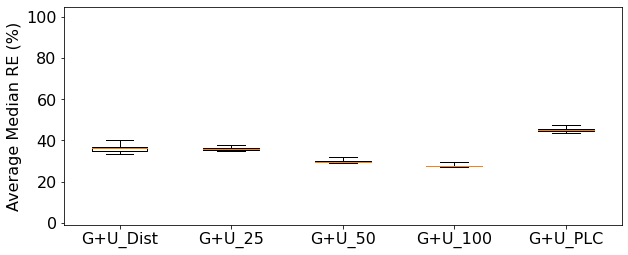

In [21]:
plt.rcParams.update({'font.size': 16, 'xtick.labelsize':'medium', 'font.family': 'sans-serif'})
fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))

# # With Separate Box Plots for Each USI
# space = 0.2
# box_params = dict(widths=0.1)
# box1 = ax1.boxplot([dv_med_uprr_box[0], fp_25_med_uprr_box[0], fp_50_med_uprr_box[0], fp_100_med_uprr_box[0], pm_med_uprr_box[0]], 
#                    showmeans=False, whis=[0, 100], positions=np.arange(5)-1.5*space, 
#                    boxprops=dict(linestyle='-', linewidth=1,  color='tab:blue'), 
#                    whiskerprops=dict(linestyle='-', linewidth=1, color='tab:blue'), **box_params)
# box2 = ax1.boxplot([dv_med_uprr_box[1], fp_25_med_uprr_box[1], fp_50_med_uprr_box[1], fp_100_med_uprr_box[1], pm_med_uprr_box[1]], 
#                    showmeans=False, whis=[0, 100], positions=np.arange(5)-0.5*space,
#                    boxprops=dict(linestyle='--', linewidth=1,  color='tab:orange'), 
#                    whiskerprops=dict(linestyle='--', linewidth=1, color='tab:orange'), **box_params)
# box3 = ax1.boxplot([dv_med_uprr_box[2], fp_25_med_uprr_box[2], fp_50_med_uprr_box[2], fp_100_med_uprr_box[2], pm_med_uprr_box[2]], 
#                    showmeans=False, whis=[0, 100], positions=np.arange(5)+0.5*space,
#                    boxprops=dict(linestyle=':', linewidth=1,  color='tab:green'), 
#                    whiskerprops=dict(linestyle=':', linewidth=1, color='tab:green'), **box_params)
# box4 = ax1.boxplot([dv_med_uprr_box[3], fp_25_med_uprr_box[3], fp_50_med_uprr_box[3], fp_100_med_uprr_box[3], pm_med_uprr_box[3]], 
#                    showmeans=False, whis=[0, 100], positions=np.arange(5)+1.5*space,
#                    boxprops=dict(linestyle='dashdot', linewidth=1,  color='tab:red'), 
#                    whiskerprops=dict(linestyle='dashdot', linewidth=1, color='tab:red'), **box_params)
# ax1.set_xticks(np.arange(5), ["U_Dist", "U_25", "U_50", "U_100", "U_PLC"], fontsize=16)
# ax1.legend((box1["boxes"][0], box2["boxes"][0], box3["boxes"][0], box4["boxes"][0]),
#                ["G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"], bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower center", fontsize=16, borderaxespad=0, ncol=8)

# With one box plots for results from all USIs
ax1.boxplot([[x for xs in dv_med_uprr_box for x in xs], [x for xs in fp_25_med_uprr_box for x in xs], [x for xs in fp_50_med_uprr_box for x in xs], [x for xs in fp_100_med_uprr_box for x in xs], 
             [x for xs in pm_med_uprr_box for x in xs]],
             showmeans=False, whis=[0, 100], labels=["G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"])

ax1.set_ylabel("Average Median RE (%)")
ax1.set_ylim(-1,105)

### Plot Consecutive Packet Failure Results

#### For No GCS

5819
12783
13500
12919
13456
13494
N_C = 2
0.0,29.803769185933554,51.73887701573733,56.362929862055566,66.40761608704099,70.60423547697688,54.4783368952788
0.0,31.243663399797228,53.33727610679283,59.023318688746194,69.9814126394052,73.62284555593106,59.18384589388307
0.0,31.99752914832831,50.660180681028486,56.296811057061234,68.15689908115203,71.84773376573239,56.806424214346386
0.0,19.405204460966544,32.573316811235024,39.165634035522515,51.276332094175956,54.21726559273028,37.27385377942999
0.0,15.881203595154359,23.556076592418915,29.245799140289176,38.1789761625635,41.563110590074245,31.42633841344275
0.0,14.432511782430657,20.46666151587731,26.32310901645677,34.3428880475933,38.229158618558294,29.82307038553658
5819
12783
13500
12919
13456
13494
N_C = 3
0.0,61.902800658978585,76.4003294892916,79.03624382207578,83.97858319604613,86.38797364085667,82.72240527182866
0.0,60.40322580645161,77.37903225806451,80.04032258064517,84.8991935483871,87.17741935483872,83.00403225806451
0.0,57

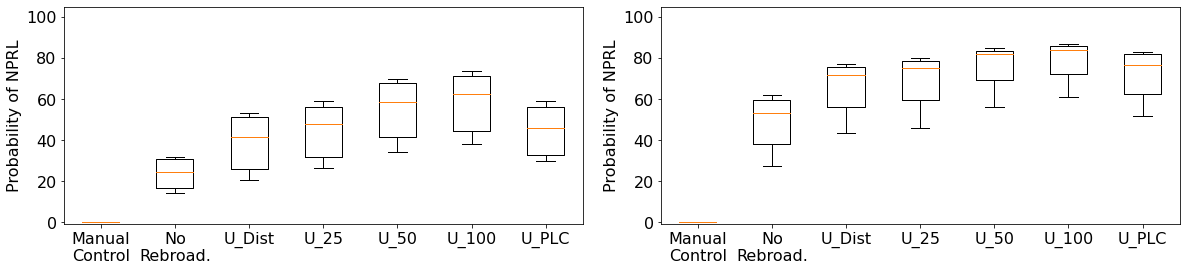

In [6]:
# Plot Percentage of Sim Runs with Consecutive Packet Failures
MANUAL_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_{}_Interference_new"
WAYPOINT_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Waypoint_Only_{}_Interference_new"
FP_25_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed25_{}_Interference_new"
FP_50_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed50_{}_Interference_new"
FP_100_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed100_{}_Interference_new"
DV_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Dist_{}_Interference_new"
TH_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_PLC_{}_Interference_new"
CASES = ["uav_scenario_0_processed", "uav_scenario_1_processed", "uav_scenario_2_processed",
         "manet_scenario_1_processed", "manet_scenario_a_processed", "manet_scenario_2_processed"]
MAX_RUN_NUM = 499 # Run num starts at 0
START_RUN_NUM = 0
END_RUN_NUM = 499
N_SECS = 2

# To store the percentage of sim runs with no cons packet failures
manual_result = []
waypoint_result = []
fp_25_result = []
fp_50_result = []
fp_100_result = []
dv_result = []
pm_result = []
# pm_gcs_result = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"
    # manual_df = compile_results(MANUAL_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # waypoint_df = compile_results(WAYPOINT_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_25_df = compile_results(FP_25_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_50_df = compile_results(FP_50_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_100_df = compile_results(FP_100_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # dv_df = compile_results(DV_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # pm_df = compile_results(TH_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    '''For Custom Run Num Range'''
    manual_df = compile_results_range(MANUAL_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    waypoint_df = compile_results_range(WAYPOINT_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_25_df = compile_results_range(FP_25_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_50_df = compile_results_range(FP_50_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_100_df = compile_results_range(FP_100_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    dv_df = compile_results_range(DV_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    pm_df = compile_results_range(TH_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    print(len(pm_df))
    '''Filter out runs where there are NaN results (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    manual_df.sort_values(by=["Scenario", "Run"], inplace=True)
    waypoint_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_25_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_50_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_100_df.sort_values(by=["Scenario", "Run"], inplace=True)
    dv_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_df.sort_values(by=["Scenario", "Run"], inplace=True)
    # pm_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)

    manual_df.reset_index(inplace=True)
    waypoint_df.reset_index(inplace=True)
    fp_25_df.reset_index(inplace=True)
    fp_50_df.reset_index(inplace=True)
    fp_100_df.reset_index(inplace=True)
    dv_df.reset_index(inplace=True)
    pm_df.reset_index(inplace=True)
    # pm_gcs_df.reset_index(inplace=True)

    runs_nan = (manual_df.isnull().any(axis=1).to_numpy()) | (waypoint_df.isnull().any(axis=1).to_numpy()) | (fp_25_df.isnull().any(axis=1).to_numpy()) | \
            (fp_50_df.isnull().any(axis=1).to_numpy()) | (fp_100_df.isnull().any(axis=1).to_numpy()) | (dv_df.isnull().any(axis=1).to_numpy()) | (pm_df.isnull().any(axis=1).to_numpy())
    manual_df_fil = manual_df.loc[~(runs_nan)]
    waypoint_df_fil = waypoint_df.loc[~(runs_nan)]
    fp_25_df_fil = fp_25_df.loc[~(runs_nan)]
    fp_50_df_fil = fp_50_df.loc[~(runs_nan)]
    fp_100_df_fil = fp_100_df.loc[~(runs_nan)]
    dv_df_fil = dv_df.loc[~(runs_nan)]
    pm_df_fil = pm_df.loc[~(runs_nan)]
    # pm_gcs_df_fil = pm_gcs_df.loc[~(runs_nan)]

    '''Get percentages of sim runs with N_SECS consecutive packet failure in at least one uplink'''
    manual_result.append(len(manual_df_fil.loc[(manual_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (manual_df_fil["UAV_1_Cons_Fail"] == 0) & (manual_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (manual_df_fil["UAV_3_Cons_Fail"] == 0) & (manual_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (manual_df_fil["UAV_5_Cons_Fail"] == 0) & (manual_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (manual_df_fil["UAV_7_Cons_Fail"] == 0)])/len(manual_df_fil) * 100)
    waypoint_result.append(len(waypoint_df_fil.loc[(waypoint_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (waypoint_df_fil["UAV_1_Cons_Fail"] == 0) & (waypoint_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (waypoint_df_fil["UAV_3_Cons_Fail"] == 0) & (waypoint_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (waypoint_df_fil["UAV_5_Cons_Fail"] == 0) & (waypoint_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (waypoint_df_fil["UAV_7_Cons_Fail"] == 0)])/len(waypoint_df_fil) * 100)
    fp_25_result.append(len(fp_25_df_fil.loc[(fp_25_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (fp_25_df_fil["UAV_1_Cons_Fail"] == 0) & (fp_25_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (fp_25_df_fil["UAV_3_Cons_Fail"] == 0) & (fp_25_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (fp_25_df_fil["UAV_5_Cons_Fail"] == 0) & (fp_25_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (fp_25_df_fil["UAV_7_Cons_Fail"] == 0)])/len(fp_25_df_fil) * 100)
    fp_50_result.append(len(fp_50_df_fil.loc[(fp_50_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (fp_50_df_fil["UAV_1_Cons_Fail"] == 0) & (fp_50_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (fp_50_df_fil["UAV_3_Cons_Fail"] == 0) & (fp_50_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (fp_50_df_fil["UAV_5_Cons_Fail"] == 0) & (fp_50_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (fp_50_df_fil["UAV_7_Cons_Fail"] == 0)])/len(fp_50_df_fil) * 100)
    fp_100_result.append(len(fp_100_df_fil.loc[(fp_100_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (fp_100_df_fil["UAV_1_Cons_Fail"] == 0) & (fp_100_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (fp_100_df_fil["UAV_3_Cons_Fail"] == 0) & (fp_100_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (fp_100_df_fil["UAV_5_Cons_Fail"] == 0) & (fp_100_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (fp_100_df_fil["UAV_7_Cons_Fail"] == 0)])/len(fp_100_df_fil) * 100)
    dv_result.append(len(dv_df_fil.loc[(dv_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (dv_df_fil["UAV_1_Cons_Fail"] == 0) & (dv_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (dv_df_fil["UAV_3_Cons_Fail"] == 0) & (dv_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (dv_df_fil["UAV_5_Cons_Fail"] == 0) & (dv_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (dv_df_fil["UAV_7_Cons_Fail"] == 0)])/len(dv_df_fil) * 100)
    pm_result.append(len(pm_df_fil.loc[(pm_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (pm_df_fil["UAV_1_Cons_Fail"] == 0) & (pm_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (pm_df_fil["UAV_3_Cons_Fail"] == 0) & (pm_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (pm_df_fil["UAV_5_Cons_Fail"] == 0) & (pm_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (pm_df_fil["UAV_7_Cons_Fail"] == 0)])/len(pm_df_fil) * 100)

# Plot for nc = 2
plt.rcParams.update({'font.size': 16, 'xtick.labelsize':'medium', 'font.family': 'sans-serif'})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 4))
# for i in range(len(CASES)):
#     ax1.plot(["Manual\nControl", "Waypoint\nControl\nOnly", "Distance-\nBased", "Fixed\nProbability", "PLCB+"], 
#              [manual_result[i], waypoint_result[i], dv_result[i], fp_result[i], pm_gcs_result[i]], '-o')
ax1.boxplot([manual_result, waypoint_result, dv_result, fp_25_result, fp_50_result, fp_100_result, pm_result], showmeans=False, whis=[0, 100],
            labels=["Manual\nControl", "No\nRebroad.", "U_Dist", "U_25", "U_50", "U_100", "U_PLC"])
ax1.set_ylabel("Probability of NPRL")
ax1.set_ylim(-1,105)
ax1.set_xticklabels(["Manual\nControl", "No\nRebroad.", "U_Dist", "U_25", "U_50", "U_100", "U_PLC"], fontsize=16)
# plt.text(0.4, -0.4, "|-Only UAV Rebroadcasting-|", transform=ax1.transAxes, fontsize=14)
# plt.text(0.83, -0.4, "  With GCS & UAV  \n|-Rebroadcasting-|", transform=ax1.transAxes, fontsize=14)
# plt.text(0.4, -0.52, "|--- Waypoint Control With Rebroadcasting ---|", transform=ax1.transAxes, fontsize=14)

print("N_C = 2")
for i in range(len(CASES)):
    print("{},{},{},{},{},{},{}".format(manual_result[i], waypoint_result[i], dv_result[i], fp_25_result[i], fp_50_result[i], fp_100_result[i], pm_result[i]))

# No do it for nc of 3
N_SECS = 3

# To store the percentage of sim runs with no cons packet failures
manual_result = []
waypoint_result = []
fp_25_result = []
fp_50_result = []
fp_100_result = []
dv_result = []
pm_result = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"
    # manual_df = compile_results(MANUAL_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # waypoint_df = compile_results(WAYPOINT_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_25_df = compile_results(FP_25_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_50_df = compile_results(FP_50_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_100_df = compile_results(FP_100_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # dv_df = compile_results(DV_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # pm_df = compile_results(TH_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    '''For Custom Run Num Range'''
    manual_df = compile_results_range(MANUAL_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    waypoint_df = compile_results_range(WAYPOINT_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_25_df = compile_results_range(FP_25_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_50_df = compile_results_range(FP_50_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_100_df = compile_results_range(FP_100_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    dv_df = compile_results_range(DV_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    pm_df = compile_results_range(TH_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    print(len(pm_df))
    '''Filter out runs where there are NaN results (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    manual_df.sort_values(by=["Scenario", "Run"], inplace=True)
    waypoint_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_25_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_50_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_100_df.sort_values(by=["Scenario", "Run"], inplace=True)
    dv_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_df.sort_values(by=["Scenario", "Run"], inplace=True)
    # pm_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)

    manual_df.reset_index(inplace=True)
    waypoint_df.reset_index(inplace=True)
    fp_25_df.reset_index(inplace=True)
    fp_50_df.reset_index(inplace=True)
    fp_100_df.reset_index(inplace=True)
    dv_df.reset_index(inplace=True)
    pm_df.reset_index(inplace=True)
    # pm_gcs_df.reset_index(inplace=True)

    runs_nan = (manual_df.isnull().any(axis=1).to_numpy()) | (waypoint_df.isnull().any(axis=1).to_numpy()) | (fp_25_df.isnull().any(axis=1).to_numpy()) | \
            (fp_50_df.isnull().any(axis=1).to_numpy()) | (fp_100_df.isnull().any(axis=1).to_numpy()) | (dv_df.isnull().any(axis=1).to_numpy()) | (pm_df.isnull().any(axis=1).to_numpy())
    manual_df_fil = manual_df.loc[~(runs_nan)]
    waypoint_df_fil = waypoint_df.loc[~(runs_nan)]
    fp_25_df_fil = fp_25_df.loc[~(runs_nan)]
    fp_50_df_fil = fp_50_df.loc[~(runs_nan)]
    fp_100_df_fil = fp_100_df.loc[~(runs_nan)]
    dv_df_fil = dv_df.loc[~(runs_nan)]
    pm_df_fil = pm_df.loc[~(runs_nan)]
    # pm_gcs_df_fil = pm_gcs_df.loc[~(runs_nan)]

    '''Get percentages of sim runs with N_SECS consecutive packet failure in at least one uplink'''
    manual_result.append(len(manual_df_fil.loc[(manual_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (manual_df_fil["UAV_1_Cons_Fail"] == 0) & (manual_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (manual_df_fil["UAV_3_Cons_Fail"] == 0) & (manual_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (manual_df_fil["UAV_5_Cons_Fail"] == 0) & (manual_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (manual_df_fil["UAV_7_Cons_Fail"] == 0)])/len(manual_df_fil) * 100)
    waypoint_result.append(len(waypoint_df_fil.loc[(waypoint_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (waypoint_df_fil["UAV_1_Cons_Fail"] == 0) & (waypoint_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (waypoint_df_fil["UAV_3_Cons_Fail"] == 0) & (waypoint_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (waypoint_df_fil["UAV_5_Cons_Fail"] == 0) & (waypoint_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (waypoint_df_fil["UAV_7_Cons_Fail"] == 0)])/len(waypoint_df_fil) * 100)
    fp_25_result.append(len(fp_25_df_fil.loc[(fp_25_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (fp_25_df_fil["UAV_1_Cons_Fail"] == 0) & (fp_25_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (fp_25_df_fil["UAV_3_Cons_Fail"] == 0) & (fp_25_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (fp_25_df_fil["UAV_5_Cons_Fail"] == 0) & (fp_25_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (fp_25_df_fil["UAV_7_Cons_Fail"] == 0)])/len(fp_25_df_fil) * 100)
    fp_50_result.append(len(fp_50_df_fil.loc[(fp_50_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (fp_50_df_fil["UAV_1_Cons_Fail"] == 0) & (fp_50_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (fp_50_df_fil["UAV_3_Cons_Fail"] == 0) & (fp_50_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (fp_50_df_fil["UAV_5_Cons_Fail"] == 0) & (fp_50_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (fp_50_df_fil["UAV_7_Cons_Fail"] == 0)])/len(fp_50_df_fil) * 100)
    fp_100_result.append(len(fp_100_df_fil.loc[(fp_100_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (fp_100_df_fil["UAV_1_Cons_Fail"] == 0) & (fp_100_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (fp_100_df_fil["UAV_3_Cons_Fail"] == 0) & (fp_100_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (fp_100_df_fil["UAV_5_Cons_Fail"] == 0) & (fp_100_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (fp_100_df_fil["UAV_7_Cons_Fail"] == 0)])/len(fp_100_df_fil) * 100)
    dv_result.append(len(dv_df_fil.loc[(dv_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (dv_df_fil["UAV_1_Cons_Fail"] == 0) & (dv_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (dv_df_fil["UAV_3_Cons_Fail"] == 0) & (dv_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (dv_df_fil["UAV_5_Cons_Fail"] == 0) & (dv_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (dv_df_fil["UAV_7_Cons_Fail"] == 0)])/len(dv_df_fil) * 100)
    pm_result.append(len(pm_df_fil.loc[(pm_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (pm_df_fil["UAV_1_Cons_Fail"] == 0) & (pm_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (pm_df_fil["UAV_3_Cons_Fail"] == 0) & (pm_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (pm_df_fil["UAV_5_Cons_Fail"] == 0) & (pm_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (pm_df_fil["UAV_7_Cons_Fail"] == 0)])/len(pm_df_fil) * 100)
    
# for i in range(len(CASES)):
#     ax2.plot(["Manual\nControl", "Waypoint\nControl\nOnly", "Distance-\nBased", "Fixed\nProbability", "PLCB+"], 
#              [manual_result[i], waypoint_result[i], dv_result[i], fp_result[i], pm_gcs_result[i]], '-o')
ax2.boxplot([manual_result, waypoint_result, dv_result, fp_25_result, fp_50_result, fp_100_result, pm_result], showmeans=False, whis=[0, 100],
            labels=["Manual\nControl", "No\nRebroad.", "U_Dist", "U_25", "U_50", "U_100", "U_PLC"])
ax2.set_ylabel("Probability of NPRL")
ax2.set_ylim(-1,105)
ax2.set_xticklabels(["Manual\nControl", "No\nRebroad.", "U_Dist", "U_25", "U_50", "U_100", "U_PLC"], fontsize=16)
# plt.text(0.4, -0.4, "|-Only UAV Rebroadcasting-|", transform=ax2.transAxes, fontsize=14)
# plt.text(0.83, -0.4, "  With GCS & UAV  \n|-Rebroadcasting-|", transform=ax2.transAxes, fontsize=14)
# plt.text(0.4, -0.52, "|--- Waypoint Control With Rebroadcasting ---|", transform=ax2.transAxes, fontsize=14)

# plt.legend( ["UAV 1", "UAV 2", "UAV 3", "MANET 1", "MANET 2", "MANET 3"], bbox_to_anchor=(-0.35, 1, 1, 0.2), loc="lower right", fontsize=14, ncol=6) 
plt.subplots_adjust(wspace=0.15)

print("N_C = 3")
for i in range(len(CASES)):
    print("{},{},{},{},{},{},{}".format(manual_result[i], waypoint_result[i], dv_result[i], fp_25_result[i], fp_50_result[i], fp_100_result[i], pm_result[i]))

In [9]:
# Print values for table
# Paste the cell output to NotePad, then copy paste to excel
for i in range(len(CASES)):
    print("{},{},{},{},{},{},{}".format(manual_result[i], waypoint_result[i], dv_result[i], fp_25_result[i], fp_50_result[i], fp_100_result[i], pm_result[i]))

0.0,33.75609756097561,57.65853658536585,61.26829268292683,70.73170731707317,75.21951219512195,58.829268292682926
0.0,33.16412859560068,56.89509306260575,62.605752961082906,74.49238578680203,77.66497461928934,61.71742808798646
0.0,34.18111753371869,53.71868978805395,60.423892100192674,70.98265895953757,74.83622350674374,57.764932562620416
0.0,20.264135369376806,34.08997111019397,41.60132067684688,51.50639702847709,55.922410235245565,37.639290136194795
0.0,15.968688845401175,23.131115459882583,27.436399217221137,36.986301369863014,41.01761252446184,30.802348336594914
0.0,13.632842757552286,19.752130131680868,25.79395817195972,33.772269558481796,37.877614252517425,28.582494190549962


#### For With GCS

5819
12783
13500
12919
13456
13494
N_C = 2
99.9628666914222,99.9814333457111,100.0,99.9814333457111,100.0
99.87460290921251,99.89968232737002,99.9582009697375,99.89968232737002,99.88296271526501
99.35140143618253,99.3822870820786,99.61392942629914,99.7374720098834,99.52127248861092
98.44147321794766,98.32663440242803,98.96645066032319,98.96645066032319,98.21179558690838
94.29150744755518,94.00296342509553,96.01497309521953,96.65444903688685,94.98557279887702
89.42367119901112,88.58930778739185,92.36711990111249,93.4487021013597,91.01514215080346
5819
12783
13500
12919
13456
13494
N_C = 3
100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0
99.99013417521705,100.0,100.0,100.0,100.0
99.98207242739333,99.97310864109,100.0,99.99103621369666,99.98207242739333
99.87476518472135,99.84792915287592,99.90160121656679,99.90160121656679,99.87476518472135
99.37384898710866,99.33701657458563,99.64088397790056,99.76058931860037,99.64088397790056


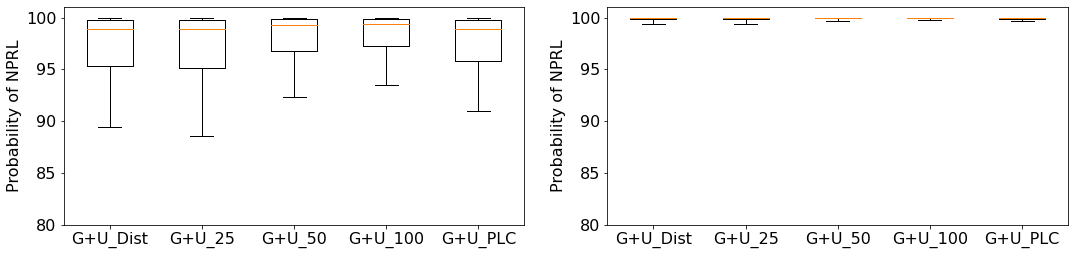

In [5]:
# Plot Percentage of Sim Runs with Consecutive Packet Failures
TH_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_PLC_{}_Interference_new"
DV_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Dist_{}_Interference_new"
FP_25_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed25_{}_Interference_new"
FP_50_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed50_{}_Interference_new"
FP_100_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed100_{}_Interference_new"
CASES = ["uav_scenario_0_processed", "uav_scenario_1_processed", "uav_scenario_2_processed",
         "manet_scenario_1_processed", "manet_scenario_a_processed", "manet_scenario_2_processed"]
MAX_RUN_NUM = 499 # Run num starts at 0
START_RUN_NUM = 0
END_RUN_NUM = 499
N_SECS = 2

# To store the percentage of sim runs with no cons packet failures
pm_gcs_result = []
fp_25_gcs_result = []
fp_50_gcs_result = []
fp_100_gcs_result = []
dv_gcs_result = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"
    # pm_gcs_df = compile_results(TH_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_25_gcs_df = compile_results(FP_25_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_50_gcs_df = compile_results(FP_50_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_100_gcs_df = compile_results(FP_100_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # dv_gcs_df = compile_results(DV_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    '''For Custom Run Num Range'''
    pm_gcs_df = compile_results_range(TH_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_25_gcs_df = compile_results_range(FP_25_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_50_gcs_df = compile_results_range(FP_50_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_100_gcs_df = compile_results_range(FP_100_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    dv_gcs_df = compile_results_range(DV_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    print(len(pm_gcs_df))
    '''Filter out runs where there are NaN results (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    pm_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_25_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_50_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_100_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    dv_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)

    pm_gcs_df.reset_index(inplace=True)
    fp_25_gcs_df.reset_index(inplace=True)
    fp_50_gcs_df.reset_index(inplace=True)
    fp_100_gcs_df.reset_index(inplace=True)
    dv_gcs_df.reset_index(inplace=True)

    runs_nan = (pm_gcs_df.isnull().any(axis=1).to_numpy()) | (dv_gcs_df.isnull().any(axis=1).to_numpy()) | \
                (fp_25_gcs_df.isnull().any(axis=1).to_numpy()) | (fp_50_gcs_df.isnull().any(axis=1).to_numpy()) | (fp_100_gcs_df.isnull().any(axis=1).to_numpy())
    pm_gcs_df_fil = pm_gcs_df.loc[~(runs_nan)]
    fp_25_gcs_df_fil = fp_25_gcs_df.loc[~(runs_nan)]
    fp_50_gcs_df_fil = fp_50_gcs_df.loc[~(runs_nan)]
    fp_100_gcs_df_fil = fp_100_gcs_df.loc[~(runs_nan)]
    dv_gcs_df_fil = dv_gcs_df.loc[~(runs_nan)]

    '''Get percentages of sim runs with N_SECS consecutive packet failure in at least one link'''
    pm_gcs_result.append(len(pm_gcs_df_fil.loc[(pm_gcs_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (pm_gcs_df_fil["UAV_1_Cons_Fail"] == 0) & (pm_gcs_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (pm_gcs_df_fil["UAV_3_Cons_Fail"] == 0) & (pm_gcs_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (pm_gcs_df_fil["UAV_5_Cons_Fail"] == 0) & (pm_gcs_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (pm_gcs_df_fil["UAV_7_Cons_Fail"] == 0)])/len(pm_gcs_df_fil) * 100)
    fp_25_gcs_result.append(len(fp_25_gcs_df_fil.loc[(fp_25_gcs_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (fp_25_gcs_df_fil["UAV_1_Cons_Fail"] == 0) & (fp_25_gcs_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (fp_25_gcs_df_fil["UAV_3_Cons_Fail"] == 0) & (fp_25_gcs_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (fp_25_gcs_df_fil["UAV_5_Cons_Fail"] == 0) & (fp_25_gcs_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (fp_25_gcs_df_fil["UAV_7_Cons_Fail"] == 0)])/len(fp_25_gcs_df_fil) * 100)
    fp_50_gcs_result.append(len(fp_50_gcs_df_fil.loc[(fp_50_gcs_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (fp_50_gcs_df_fil["UAV_1_Cons_Fail"] == 0) & (fp_50_gcs_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (fp_50_gcs_df_fil["UAV_3_Cons_Fail"] == 0) & (fp_50_gcs_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (fp_50_gcs_df_fil["UAV_5_Cons_Fail"] == 0) & (fp_50_gcs_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (fp_50_gcs_df_fil["UAV_7_Cons_Fail"] == 0)])/len(fp_50_gcs_df_fil) * 100)
    fp_100_gcs_result.append(len(fp_100_gcs_df_fil.loc[(fp_100_gcs_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (fp_100_gcs_df_fil["UAV_1_Cons_Fail"] == 0) & (fp_100_gcs_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (fp_100_gcs_df_fil["UAV_3_Cons_Fail"] == 0) & (fp_100_gcs_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (fp_100_gcs_df_fil["UAV_5_Cons_Fail"] == 0) & (fp_100_gcs_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (fp_100_gcs_df_fil["UAV_7_Cons_Fail"] == 0)])/len(fp_100_gcs_df_fil) * 100)
    dv_gcs_result.append(len(dv_gcs_df_fil.loc[(dv_gcs_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (dv_gcs_df_fil["UAV_1_Cons_Fail"] == 0) & (dv_gcs_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (dv_gcs_df_fil["UAV_3_Cons_Fail"] == 0) & (dv_gcs_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (dv_gcs_df_fil["UAV_5_Cons_Fail"] == 0) & (dv_gcs_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (dv_gcs_df_fil["UAV_7_Cons_Fail"] == 0)])/len(dv_gcs_df_fil) * 100)

# Plot for nc = 2
plt.rcParams.update({'font.size': 16, 'xtick.labelsize':'medium', 'font.family': 'sans-serif'})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 4))
ax1.boxplot([dv_gcs_result, fp_25_gcs_result, fp_50_gcs_result, fp_100_gcs_result, pm_gcs_result], showmeans=False, whis=[0, 100],
            labels=["G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"])
ax1.set_ylabel("Probability of NPRL")
ax1.set_ylim(80,101)
ax1.set_xticklabels(["G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"], fontsize=16)

print("N_C = 2")
for i in range(len(CASES)):
    print("{},{},{},{},{}".format(dv_gcs_result[i], fp_25_gcs_result[i], fp_50_gcs_result[i], fp_100_gcs_result[i], pm_gcs_result[i]))

# Now do it for nc of 3
N_SECS = 3

# To store the percentage of sim runs with no cons packet failures
pm_gcs_result = []
fp_25_gcs_result = []
fp_50_gcs_result = []
fp_100_gcs_result = []
dv_gcs_result = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"
    # pm_gcs_df = compile_results(TH_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_25_gcs_df = compile_results(FP_25_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_50_gcs_df = compile_results(FP_50_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_100_gcs_df = compile_results(FP_100_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # dv_gcs_df = compile_results(DV_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    '''For Custom Run Num Range'''
    pm_gcs_df = compile_results_range(TH_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_25_gcs_df = compile_results_range(FP_25_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_50_gcs_df = compile_results_range(FP_50_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_100_gcs_df = compile_results_range(FP_100_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    dv_gcs_df = compile_results_range(DV_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    print(len(pm_gcs_df))
    '''Filter out runs where there are NaN results (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    pm_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_25_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_50_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_100_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    dv_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)

    pm_gcs_df.reset_index(inplace=True)
    fp_25_gcs_df.reset_index(inplace=True)
    fp_50_gcs_df.reset_index(inplace=True)
    fp_100_gcs_df.reset_index(inplace=True)
    dv_gcs_df.reset_index(inplace=True)

    runs_nan = (pm_gcs_df.isnull().any(axis=1).to_numpy()) | (dv_gcs_df.isnull().any(axis=1).to_numpy()) | \
                (fp_25_gcs_df.isnull().any(axis=1).to_numpy()) | (fp_50_gcs_df.isnull().any(axis=1).to_numpy()) | (fp_100_gcs_df.isnull().any(axis=1).to_numpy())
    pm_gcs_df_fil = pm_gcs_df.loc[~(runs_nan)]
    fp_25_gcs_df_fil = fp_25_gcs_df.loc[~(runs_nan)]
    fp_50_gcs_df_fil = fp_50_gcs_df.loc[~(runs_nan)]
    fp_100_gcs_df_fil = fp_100_gcs_df.loc[~(runs_nan)]
    dv_gcs_df_fil = dv_gcs_df.loc[~(runs_nan)]

    '''Get percentages of sim runs with N_SECS consecutive packet failure in at least one link'''
    pm_gcs_result.append(len(pm_gcs_df_fil.loc[(pm_gcs_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (pm_gcs_df_fil["UAV_1_Cons_Fail"] == 0) & (pm_gcs_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (pm_gcs_df_fil["UAV_3_Cons_Fail"] == 0) & (pm_gcs_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (pm_gcs_df_fil["UAV_5_Cons_Fail"] == 0) & (pm_gcs_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (pm_gcs_df_fil["UAV_7_Cons_Fail"] == 0)])/len(pm_gcs_df_fil) * 100)
    fp_25_gcs_result.append(len(fp_25_gcs_df_fil.loc[(fp_25_gcs_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (fp_25_gcs_df_fil["UAV_1_Cons_Fail"] == 0) & (fp_25_gcs_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (fp_25_gcs_df_fil["UAV_3_Cons_Fail"] == 0) & (fp_25_gcs_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (fp_25_gcs_df_fil["UAV_5_Cons_Fail"] == 0) & (fp_25_gcs_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (fp_25_gcs_df_fil["UAV_7_Cons_Fail"] == 0)])/len(fp_25_gcs_df_fil) * 100)
    fp_50_gcs_result.append(len(fp_50_gcs_df_fil.loc[(fp_50_gcs_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (fp_50_gcs_df_fil["UAV_1_Cons_Fail"] == 0) & (fp_50_gcs_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (fp_50_gcs_df_fil["UAV_3_Cons_Fail"] == 0) & (fp_50_gcs_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (fp_50_gcs_df_fil["UAV_5_Cons_Fail"] == 0) & (fp_50_gcs_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (fp_50_gcs_df_fil["UAV_7_Cons_Fail"] == 0)])/len(fp_50_gcs_df_fil) * 100)
    fp_100_gcs_result.append(len(fp_100_gcs_df_fil.loc[(fp_100_gcs_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (fp_100_gcs_df_fil["UAV_1_Cons_Fail"] == 0) & (fp_100_gcs_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (fp_100_gcs_df_fil["UAV_3_Cons_Fail"] == 0) & (fp_100_gcs_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (fp_100_gcs_df_fil["UAV_5_Cons_Fail"] == 0) & (fp_100_gcs_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (fp_100_gcs_df_fil["UAV_7_Cons_Fail"] == 0)])/len(fp_100_gcs_df_fil) * 100)
    dv_gcs_result.append(len(dv_gcs_df_fil.loc[(dv_gcs_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (dv_gcs_df_fil["UAV_1_Cons_Fail"] == 0) & (dv_gcs_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (dv_gcs_df_fil["UAV_3_Cons_Fail"] == 0) & (dv_gcs_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (dv_gcs_df_fil["UAV_5_Cons_Fail"] == 0) & (dv_gcs_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (dv_gcs_df_fil["UAV_7_Cons_Fail"] == 0)])/len(dv_gcs_df_fil) * 100)
    
ax2.boxplot([dv_gcs_result, fp_25_gcs_result, fp_50_gcs_result, fp_100_gcs_result, pm_gcs_result], showmeans=False, whis=[0, 100],
            labels=["G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"])
ax2.set_ylabel("Probability of NPRL")
ax2.set_ylim(80,101)
ax2.set_xticklabels(["G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"], fontsize=16)
plt.subplots_adjust(wspace=0.18)

print("N_C = 3")
for i in range(len(CASES)):
    print("{},{},{},{},{}".format(dv_gcs_result[i], fp_25_gcs_result[i], fp_50_gcs_result[i], fp_100_gcs_result[i], pm_gcs_result[i]))

In [13]:
# Print values for table
# Paste the cell output to NotePad, then copy paste to excel
for i in range(len(CASES)):
    print("{},{},{},{},{}".format(dv_gcs_result[i], fp_25_gcs_result[i], fp_50_gcs_result[i], fp_100_gcs_result[i], pm_gcs_result[i]))

100.0,100.0,100.0,100.0,100.0
100.0,99.95819397993311,99.95819397993311,99.87458193979933,99.83277591973244
99.61464354527938,99.42196531791907,99.69171483622351,99.76878612716763,99.69171483622351
98.35931091058244,97.94913863822805,99.09762100082034,98.89253486464314,97.82608695652173
93.6328125,93.0078125,95.78125,96.328125,94.4140625
87.72744870305846,86.99186991869918,91.01819589624468,93.22493224932249,89.89547038327527


### Plot Consecutive Packet Failure Results (Per USI)

#### For Type-2/Type-3 Loss, All Schemes

In [10]:
# Plot Percentage of Sim Runs with Consecutive Packet Failures
MANUAL_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_{}_Interference_new"
WAYPOINT_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Waypoint_Only_{}_Interference_new"
FP_25_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed25_{}_Interference_new"
FP_50_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed50_{}_Interference_new"
FP_100_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed100_{}_Interference_new"
DV_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Dist_{}_Interference_new"
TH_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_PLC_{}_Interference_new"
TH_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_PLC_{}_Interference_new"
DV_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Dist_{}_Interference_new"
FP_25_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed25_{}_Interference_new"
FP_50_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed50_{}_Interference_new"
FP_100_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed100_{}_Interference_new"
CASES = ["uav_scenario_0_processed", "uav_scenario_1_processed", "uav_scenario_2_processed",
         "manet_scenario_1_processed", "manet_scenario_a_processed", "manet_scenario_2_processed"]
MAX_RUN_NUM = 499 # Run num starts at 0
START_RUN_NUM = 0
END_RUN_NUM = 499
N_SECS = 3
usi_list = ["10", "20", "66.7", "100"]

# To store the percentage of sim runs with no cons packet failures
manual_result = []
waypoint_result = []
fp_25_result = []
fp_50_result = []
fp_100_result = []
dv_result = []
pm_result = []
pm_gcs_result = []
fp_25_gcs_result = []
fp_50_gcs_result = []
fp_100_gcs_result = []
dv_gcs_result = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"
    # manual_df = compile_results(MANUAL_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # waypoint_df = compile_results(WAYPOINT_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_25_df = compile_results(FP_25_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_50_df = compile_results(FP_50_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_100_df = compile_results(FP_100_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # dv_df = compile_results(DV_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # pm_df = compile_results(TH_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    '''For Custom Run Num Range'''
    manual_df = compile_results_range(MANUAL_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    waypoint_df = compile_results_range(WAYPOINT_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_25_df = compile_results_range(FP_25_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_50_df = compile_results_range(FP_50_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_100_df = compile_results_range(FP_100_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    dv_df = compile_results_range(DV_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    pm_df = compile_results_range(TH_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    pm_gcs_df = compile_results_range(TH_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_25_gcs_df = compile_results_range(FP_25_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_50_gcs_df = compile_results_range(FP_50_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_100_gcs_df = compile_results_range(FP_100_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    dv_gcs_df = compile_results_range(DV_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    print(len(pm_df))
    '''Filter out runs where there are NaN results (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    manual_df.sort_values(by=["Scenario", "Run"], inplace=True)
    waypoint_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_25_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_50_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_100_df.sort_values(by=["Scenario", "Run"], inplace=True)
    dv_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_25_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_50_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_100_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    dv_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)

    manual_df.reset_index(inplace=True)
    waypoint_df.reset_index(inplace=True)
    fp_25_df.reset_index(inplace=True)
    fp_50_df.reset_index(inplace=True)
    fp_100_df.reset_index(inplace=True)
    dv_df.reset_index(inplace=True)
    pm_df.reset_index(inplace=True)
    pm_gcs_df.reset_index(inplace=True)
    fp_25_gcs_df.reset_index(inplace=True)
    fp_50_gcs_df.reset_index(inplace=True)
    fp_100_gcs_df.reset_index(inplace=True)
    dv_gcs_df.reset_index(inplace=True)

    # runs_nan = (manual_df.isnull().any(axis=1).to_numpy()) | (waypoint_df.isnull().any(axis=1).to_numpy()) | (fp_25_df.isnull().any(axis=1).to_numpy()) | \
    #         (fp_50_df.isnull().any(axis=1).to_numpy()) | (fp_100_df.isnull().any(axis=1).to_numpy()) | (dv_df.isnull().any(axis=1).to_numpy()) | (pm_df.isnull().any(axis=1).to_numpy()) | \
    #         (pm_gcs_df.isnull().any(axis=1).to_numpy()) | (fp_25_gcs_df.isnull().any(axis=1).to_numpy()) | (fp_50_gcs_df.isnull().any(axis=1).to_numpy()) | \
    #         (fp_100_gcs_df.isnull().any(axis=1).to_numpy()) | (dv_gcs_df.isnull().any(axis=1).to_numpy())
    # manual_df_fil = manual_df.loc[~(runs_nan)]
    # waypoint_df_fil = waypoint_df.loc[~(runs_nan)]
    # fp_25_df_fil = fp_25_df.loc[~(runs_nan)]
    # fp_50_df_fil = fp_50_df.loc[~(runs_nan)]
    # fp_100_df_fil = fp_100_df.loc[~(runs_nan)]
    # dv_df_fil = dv_df.loc[~(runs_nan)]
    # pm_df_fil = pm_df.loc[~(runs_nan)]
    # pm_gcs_df_fil = pm_gcs_df.loc[~(runs_nan)]
    # fp_25_gcs_df_fil = fp_25_gcs_df.loc[~(runs_nan)]
    # fp_50_gcs_df_fil = fp_50_gcs_df.loc[~(runs_nan)]
    # fp_100_gcs_df_fil = fp_100_gcs_df.loc[~(runs_nan)]
    # dv_gcs_df_fil = dv_gcs_df.loc[~(runs_nan)]

    manual_df_fil = manual_df.loc[~(manual_df.isnull().any(axis=1).to_numpy())]
    waypoint_df_fil = waypoint_df.loc[~(waypoint_df.isnull().any(axis=1).to_numpy())]
    fp_25_df_fil = fp_25_df.loc[~(fp_25_df.isnull().any(axis=1).to_numpy())]
    fp_50_df_fil = fp_50_df.loc[~(fp_50_df.isnull().any(axis=1).to_numpy())]
    fp_100_df_fil = fp_100_df.loc[~(fp_100_df.isnull().any(axis=1).to_numpy())]
    dv_df_fil = dv_df.loc[~(dv_df.isnull().any(axis=1).to_numpy())]
    pm_df_fil = pm_df.loc[~(pm_df.isnull().any(axis=1).to_numpy())]
    pm_gcs_df_fil = pm_gcs_df.loc[~(pm_gcs_df.isnull().any(axis=1).to_numpy())]
    fp_25_gcs_df_fil = fp_25_gcs_df.loc[~(fp_25_gcs_df.isnull().any(axis=1).to_numpy())]
    fp_50_gcs_df_fil = fp_50_gcs_df.loc[~(fp_50_gcs_df.isnull().any(axis=1).to_numpy())]
    fp_100_gcs_df_fil = fp_100_gcs_df.loc[~(fp_100_gcs_df.isnull().any(axis=1).to_numpy())]
    dv_gcs_df_fil = dv_gcs_df.loc[~(dv_gcs_df.isnull().any(axis=1).to_numpy())]

    '''For each scheme, for each USI, Get percentages of sim runs with N_SECS consecutive packet failure in at least one uplink'''
    manual_result_usi = [] # These are to store results per USI for the current scenario
    waypoint_result_usi = []
    fp_25_result_usi = []
    fp_50_result_usi = []
    fp_100_result_usi = []
    dv_result_usi = []
    pm_result_usi = []
    pm_gcs_result_usi = []
    fp_25_gcs_result_usi = []
    fp_50_gcs_result_usi = []
    fp_100_gcs_result_usi = []
    dv_gcs_result_usi = []
    
    for usi in usi_list:
        manual_df_usi = manual_df_fil.loc[(manual_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        manual_result_usi.append(len(manual_df_usi.loc[(manual_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (manual_df_usi["UAV_1_Cons_Fail"] == 0) & (manual_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (manual_df_usi["UAV_3_Cons_Fail"] == 0) & (manual_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (manual_df_usi["UAV_5_Cons_Fail"] == 0) & (manual_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (manual_df_usi["UAV_7_Cons_Fail"] == 0)])/len(manual_df_usi) * 100)
        waypoint_df_usi = waypoint_df_fil.loc[(waypoint_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        waypoint_result_usi.append(len(waypoint_df_usi.loc[(waypoint_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (waypoint_df_usi["UAV_1_Cons_Fail"] == 0) & (waypoint_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (waypoint_df_usi["UAV_3_Cons_Fail"] == 0) & (waypoint_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (waypoint_df_usi["UAV_5_Cons_Fail"] == 0) & (waypoint_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (waypoint_df_usi["UAV_7_Cons_Fail"] == 0)])/len(waypoint_df_usi) * 100)
        fp_25_df_usi = fp_25_df_fil.loc[(fp_25_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_25_result_usi.append(len(fp_25_df_usi.loc[(fp_25_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_25_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_25_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_25_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_25_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_25_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_25_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_25_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_25_df_usi) * 100)
        fp_50_df_usi = fp_50_df_fil.loc[(fp_50_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_50_result_usi.append(len(fp_50_df_usi.loc[(fp_50_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_50_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_50_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_50_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_50_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_50_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_50_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_50_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_50_df_usi) * 100)
        fp_100_df_usi = fp_100_df_fil.loc[(fp_100_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_100_result_usi.append(len(fp_100_df_usi.loc[(fp_100_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_100_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_100_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_100_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_100_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_100_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_100_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_100_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_100_df_usi) * 100)
        dv_df_usi = dv_df_fil.loc[(dv_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        dv_result_usi.append(len(dv_df_usi.loc[(dv_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (dv_df_usi["UAV_1_Cons_Fail"] == 0) & (dv_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (dv_df_usi["UAV_3_Cons_Fail"] == 0) & (dv_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (dv_df_usi["UAV_5_Cons_Fail"] == 0) & (dv_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (dv_df_usi["UAV_7_Cons_Fail"] == 0)])/len(dv_df_usi) * 100)
        pm_df_usi = pm_df_fil.loc[(pm_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        pm_result_usi.append(len(pm_df_usi.loc[(pm_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (pm_df_usi["UAV_1_Cons_Fail"] == 0) & (pm_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (pm_df_usi["UAV_3_Cons_Fail"] == 0) & (pm_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (pm_df_usi["UAV_5_Cons_Fail"] == 0) & (pm_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (pm_df_usi["UAV_7_Cons_Fail"] == 0)])/len(pm_df_usi) * 100)
        pm_gcs_df_usi = pm_gcs_df_fil.loc[(pm_gcs_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        pm_gcs_result_usi.append(len(pm_gcs_df_usi.loc[(pm_gcs_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (pm_gcs_df_usi["UAV_1_Cons_Fail"] == 0) & (pm_gcs_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (pm_gcs_df_usi["UAV_3_Cons_Fail"] == 0) & (pm_gcs_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (pm_gcs_df_usi["UAV_5_Cons_Fail"] == 0) & (pm_gcs_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (pm_gcs_df_usi["UAV_7_Cons_Fail"] == 0)])/len(pm_gcs_df_usi) * 100)
        fp_25_gcs_df_usi = fp_25_gcs_df_fil.loc[(fp_25_gcs_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_25_gcs_result_usi.append(len(fp_25_gcs_df_usi.loc[(fp_25_gcs_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_25_gcs_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_25_gcs_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_25_gcs_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_25_gcs_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_25_gcs_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_25_gcs_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_25_gcs_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_25_gcs_df_usi) * 100)
        fp_50_gcs_df_usi = fp_50_gcs_df_fil.loc[(fp_50_gcs_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_50_gcs_result_usi.append(len(fp_50_gcs_df_usi.loc[(fp_50_gcs_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_50_gcs_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_50_gcs_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_50_gcs_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_50_gcs_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_50_gcs_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_50_gcs_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_50_gcs_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_50_gcs_df_usi) * 100)
        fp_100_gcs_df_usi = fp_100_gcs_df_fil.loc[(fp_100_gcs_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_100_gcs_result_usi.append(len(fp_100_gcs_df_usi.loc[(fp_100_gcs_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_100_gcs_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_100_gcs_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_100_gcs_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_100_gcs_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_100_gcs_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_100_gcs_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_100_gcs_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_100_gcs_df_usi) * 100)
        dv_gcs_df_usi = dv_gcs_df_fil.loc[(dv_gcs_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        dv_gcs_result_usi.append(len(dv_gcs_df_usi.loc[(dv_gcs_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (dv_gcs_df_usi["UAV_1_Cons_Fail"] == 0) & (dv_gcs_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (dv_gcs_df_usi["UAV_3_Cons_Fail"] == 0) & (dv_gcs_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (dv_gcs_df_usi["UAV_5_Cons_Fail"] == 0) & (dv_gcs_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (dv_gcs_df_usi["UAV_7_Cons_Fail"] == 0)])/len(dv_gcs_df_usi) * 100)
    
    manual_result.append(manual_result_usi)
    waypoint_result.append(waypoint_result_usi)
    dv_result.append(dv_result_usi)
    fp_25_result.append(fp_25_result_usi)
    fp_50_result.append(fp_50_result_usi)
    fp_100_result.append(fp_100_result_usi)
    pm_result.append(pm_result_usi)
    pm_gcs_result.append(pm_gcs_result_usi)
    fp_25_gcs_result.append(fp_25_gcs_result_usi)
    fp_50_gcs_result.append(fp_50_gcs_result_usi)
    fp_100_gcs_result.append(fp_100_gcs_result_usi)
    dv_gcs_result.append(dv_gcs_result_usi)

manual_result_box = [[x[i] for x in manual_result] for i in range(4)]
waypoint_result_box = [[x[i] for x in waypoint_result] for i in range(4)]
dv_result_box = [[x[i] for x in dv_result] for i in range(4)]
fp_25_result_box = [[x[i] for x in fp_25_result] for i in range(4)]
fp_50_result_box = [[x[i] for x in fp_50_result] for i in range(4)]
fp_100_result_box = [[x[i] for x in fp_100_result] for i in range(4)]
pm_result_box = [[x[i] for x in pm_result] for i in range(4)]
pm_gcs_result_box = [[x[i] for x in pm_gcs_result] for i in range(4)]
fp_25_gcs_result_box = [[x[i] for x in fp_25_gcs_result] for i in range(4)]
fp_50_gcs_result_box = [[x[i] for x in fp_50_gcs_result] for i in range(4)]
fp_100_gcs_result_box = [[x[i] for x in fp_100_gcs_result] for i in range(4)]
dv_gcs_result_box = [[x[i] for x in dv_gcs_result] for i in range(4)]

print("N_C = {}".format(N_SECS))
for j in range(4):
    print("USI: {}".format(usi_list[j]))
    for i in range(len(CASES)):
        print("{},{},{},{},{},{},{},{},{},{},{},{}".format(manual_result_box[j][i], waypoint_result_box[j][i], dv_result_box[j][i], fp_25_result_box[j][i], fp_50_result_box[j][i], fp_100_result_box[j][i], pm_result_box[j][i],
                                            dv_gcs_result_box[j][i], fp_25_gcs_result_box[j][i], fp_50_gcs_result_box[j][i], fp_100_gcs_result_box[j][i], pm_gcs_result_box[j][i]))

5819
12783
13500
12919
13456
13494
N_C = 3
USI: 10
0.0,88.5,91.0,92.5,95.7,96.0,95.89999999999999,100.0,100.0,100.0,100.0,100.0
0.0,87.0,91.4,94.0,96.6,96.8,95.19999999999999,100.0,100.0,100.0,100.0,100.0
0.0,85.8,89.9,91.10000000000001,94.8,95.8,92.9,100.0,100.0,100.0,100.0,100.0
0.0,86.3,90.60000000000001,94.5,95.3,96.1,95.0,100.0,100.0,100.0,100.0,100.0
0.0,77.8,81.69999999999999,86.0,92.60000000000001,92.2,89.60000000000001,100.0,100.0,100.0,100.0,100.0
0.0,69.89999999999999,79.5,84.5,88.4,92.5,88.9,100.0,100.0,99.9,99.9,100.0
USI: 20
0.0,64.02966625463536,78.0799340749897,81.25257519571487,86.1145447053976,88.8339513803049,84.79604449938195,100.0,100.0,100.0,100.0,100.0
0.0,63.89351081530782,78.23627287853577,82.19633943427621,86.18968386023295,88.31946755407654,84.2928452579035,100.0,100.0,100.0,100.0,100.0
0.0,62.2,75.8,79.43333333333334,83.43333333333334,86.23333333333333,82.1,100.0,100.0,100.0,100.0,100.0
0.0,56.37342908438061,73.07001795332137,78.15679233991621,84.08138839018

(-1.0, 105.0)

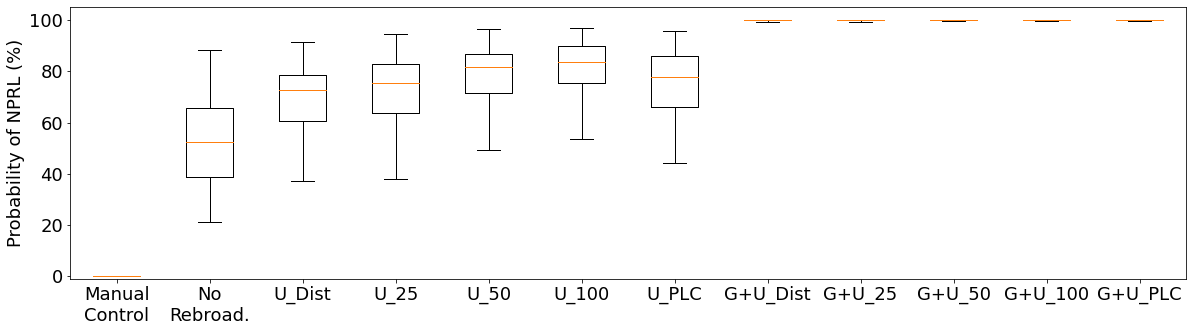

In [11]:
plt.rcParams.update({'font.size': 18, 'xtick.labelsize':'medium', 'font.family': 'sans-serif'})
fig, ax = plt.subplots(1, 1, figsize=(20, 5))

# With one box plots for results from all USIs
ax.boxplot([[x for xs in manual_result_box for x in xs], [x for xs in waypoint_result_box for x in xs], [x for xs in dv_result_box for x in xs], [x for xs in fp_25_result_box for x in xs], 
             [x for xs in fp_50_result_box for x in xs], [x for xs in fp_100_result_box for x in xs], [x for xs in pm_result_box for x in xs], [x for xs in dv_gcs_result_box for x in xs],
             [x for xs in fp_25_gcs_result_box for x in xs], [x for xs in fp_50_gcs_result_box for x in xs], [x for xs in fp_100_gcs_result_box for x in xs], [x for xs in pm_gcs_result_box for x in xs]],
             showmeans=False, whis=[0, 100], labels=["Manual\nControl", "No\nRebroad.", "U_Dist", "U_25", "U_50", "U_100", "U_PLC", "G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"])

ax.set_ylabel("Probability of NPRL (%)")
ax.set_ylim(-1,105)

#### For No GCS

In [ ]:
# Plot Percentage of Sim Runs with Consecutive Packet Failures
MANUAL_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_{}_Interference_new"
WAYPOINT_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Waypoint_Only_{}_Interference_new"
FP_25_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed25_{}_Interference_new"
FP_50_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed50_{}_Interference_new"
FP_100_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed100_{}_Interference_new"
DV_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Dist_{}_Interference_new"
TH_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_PLC_{}_Interference_new"
CASES = ["uav_scenario_0_processed", "uav_scenario_1_processed", "uav_scenario_2_processed",
         "manet_scenario_1_processed", "manet_scenario_a_processed", "manet_scenario_2_processed"]
MAX_RUN_NUM = 499 # Run num starts at 0
START_RUN_NUM = 0
END_RUN_NUM = 499
N_SECS = 2
usi_list = ["10", "20", "66.7", "100"]

# To store the percentage of sim runs with no cons packet failures
manual_result = []
waypoint_result = []
fp_25_result = []
fp_50_result = []
fp_100_result = []
dv_result = []
pm_result = []
# pm_gcs_result = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"
    # manual_df = compile_results(MANUAL_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # waypoint_df = compile_results(WAYPOINT_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_25_df = compile_results(FP_25_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_50_df = compile_results(FP_50_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_100_df = compile_results(FP_100_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # dv_df = compile_results(DV_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # pm_df = compile_results(TH_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    '''For Custom Run Num Range'''
    manual_df = compile_results_range(MANUAL_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    waypoint_df = compile_results_range(WAYPOINT_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_25_df = compile_results_range(FP_25_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_50_df = compile_results_range(FP_50_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_100_df = compile_results_range(FP_100_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    dv_df = compile_results_range(DV_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    pm_df = compile_results_range(TH_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    print(len(pm_df))
    '''Filter out runs where there are NaN results (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    manual_df.sort_values(by=["Scenario", "Run"], inplace=True)
    waypoint_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_25_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_50_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_100_df.sort_values(by=["Scenario", "Run"], inplace=True)
    dv_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_df.sort_values(by=["Scenario", "Run"], inplace=True)
    # pm_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)

    manual_df.reset_index(inplace=True)
    waypoint_df.reset_index(inplace=True)
    fp_25_df.reset_index(inplace=True)
    fp_50_df.reset_index(inplace=True)
    fp_100_df.reset_index(inplace=True)
    dv_df.reset_index(inplace=True)
    pm_df.reset_index(inplace=True)
    # pm_gcs_df.reset_index(inplace=True)

    runs_nan = (manual_df.isnull().any(axis=1).to_numpy()) | (waypoint_df.isnull().any(axis=1).to_numpy()) | (fp_25_df.isnull().any(axis=1).to_numpy()) | \
            (fp_50_df.isnull().any(axis=1).to_numpy()) | (fp_100_df.isnull().any(axis=1).to_numpy()) | (dv_df.isnull().any(axis=1).to_numpy()) | (pm_df.isnull().any(axis=1).to_numpy())
    manual_df_fil = manual_df.loc[~(runs_nan)]
    waypoint_df_fil = waypoint_df.loc[~(runs_nan)]
    fp_25_df_fil = fp_25_df.loc[~(runs_nan)]
    fp_50_df_fil = fp_50_df.loc[~(runs_nan)]
    fp_100_df_fil = fp_100_df.loc[~(runs_nan)]
    dv_df_fil = dv_df.loc[~(runs_nan)]
    pm_df_fil = pm_df.loc[~(runs_nan)]
    # pm_gcs_df_fil = pm_gcs_df.loc[~(runs_nan)]

    '''For each scheme, for each USI, Get percentages of sim runs with N_SECS consecutive packet failure in at least one uplink'''
    manual_result_usi = [] # These are to store results per USI for the current scenario
    waypoint_result_usi = []
    fp_25_result_usi = []
    fp_50_result_usi = []
    fp_100_result_usi = []
    dv_result_usi = []
    pm_result_usi = []
    for usi in usi_list:
        manual_df_usi = manual_df_fil.loc[(manual_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        manual_result_usi.append(len(manual_df_usi.loc[(manual_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (manual_df_usi["UAV_1_Cons_Fail"] == 0) & (manual_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (manual_df_usi["UAV_3_Cons_Fail"] == 0) & (manual_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (manual_df_usi["UAV_5_Cons_Fail"] == 0) & (manual_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (manual_df_usi["UAV_7_Cons_Fail"] == 0)])/len(manual_df_usi) * 100)
        waypoint_df_usi = waypoint_df_fil.loc[(waypoint_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        waypoint_result_usi.append(len(waypoint_df_usi.loc[(waypoint_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (waypoint_df_usi["UAV_1_Cons_Fail"] == 0) & (waypoint_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (waypoint_df_usi["UAV_3_Cons_Fail"] == 0) & (waypoint_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (waypoint_df_usi["UAV_5_Cons_Fail"] == 0) & (waypoint_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (waypoint_df_usi["UAV_7_Cons_Fail"] == 0)])/len(waypoint_df_usi) * 100)
        fp_25_df_usi = fp_25_df_fil.loc[(fp_25_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_25_result_usi.append(len(fp_25_df_usi.loc[(fp_25_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_25_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_25_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_25_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_25_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_25_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_25_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_25_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_25_df_usi) * 100)
        fp_50_df_usi = fp_50_df_fil.loc[(fp_50_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_50_result_usi.append(len(fp_50_df_usi.loc[(fp_50_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_50_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_50_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_50_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_50_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_50_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_50_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_50_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_50_df_usi) * 100)
        fp_100_df_usi = fp_100_df_fil.loc[(fp_100_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_100_result_usi.append(len(fp_100_df_usi.loc[(fp_100_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_100_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_100_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_100_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_100_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_100_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_100_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_100_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_100_df_usi) * 100)
        dv_df_usi = dv_df_fil.loc[(dv_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        dv_result_usi.append(len(dv_df_usi.loc[(dv_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (dv_df_usi["UAV_1_Cons_Fail"] == 0) & (dv_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (dv_df_usi["UAV_3_Cons_Fail"] == 0) & (dv_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (dv_df_usi["UAV_5_Cons_Fail"] == 0) & (dv_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (dv_df_usi["UAV_7_Cons_Fail"] == 0)])/len(dv_df_usi) * 100)
        pm_df_usi = pm_df_fil.loc[(pm_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        pm_result_usi.append(len(pm_df_usi.loc[(pm_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (pm_df_usi["UAV_1_Cons_Fail"] == 0) & (pm_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (pm_df_usi["UAV_3_Cons_Fail"] == 0) & (pm_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (pm_df_usi["UAV_5_Cons_Fail"] == 0) & (pm_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (pm_df_usi["UAV_7_Cons_Fail"] == 0)])/len(pm_df_usi) * 100)
    manual_result.append(manual_result_usi)
    waypoint_result.append(waypoint_result_usi)
    dv_result.append(dv_result_usi)
    fp_25_result.append(fp_25_result_usi)
    fp_50_result.append(fp_50_result_usi)
    fp_100_result.append(fp_100_result_usi)
    pm_result.append(pm_result_usi)

manual_result_box = [[x[i] for x in manual_result] for i in range(4)]
waypoint_result_box = [[x[i] for x in waypoint_result] for i in range(4)]
dv_result_box = [[x[i] for x in dv_result] for i in range(4)]
fp_25_result_box = [[x[i] for x in fp_25_result] for i in range(4)]
fp_50_result_box = [[x[i] for x in fp_50_result] for i in range(4)]
fp_100_result_box = [[x[i] for x in fp_100_result] for i in range(4)]
pm_result_box = [[x[i] for x in pm_result] for i in range(4)]

print("N_C = 2")
for j in range(4):
    print("USI: {}".format(usi_list[j]))
    for i in range(len(CASES)):
        print("{},{},{},{},{},{},{}".format(manual_result_box[j][i], waypoint_result_box[j][i], dv_result_box[j][i], fp_25_result_box[j][i], fp_50_result_box[j][i], fp_100_result_box[j][i], pm_result_box[j][i]))
        
# Now do it for nc of 3
N_SECS = 3

# To store the percentage of sim runs with no cons packet failures
manual_result = []
waypoint_result = []
fp_25_result = []
fp_50_result = []
fp_100_result = []
dv_result = []
pm_result = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"
    # manual_df = compile_results(MANUAL_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # waypoint_df = compile_results(WAYPOINT_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_25_df = compile_results(FP_25_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_50_df = compile_results(FP_50_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_100_df = compile_results(FP_100_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # dv_df = compile_results(DV_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # pm_df = compile_results(TH_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    '''For Custom Run Num Range'''
    manual_df = compile_results_range(MANUAL_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    waypoint_df = compile_results_range(WAYPOINT_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_25_df = compile_results_range(FP_25_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_50_df = compile_results_range(FP_50_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_100_df = compile_results_range(FP_100_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    dv_df = compile_results_range(DV_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    pm_df = compile_results_range(TH_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    print(len(pm_df))
    '''Filter out runs where there are NaN results (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    manual_df.sort_values(by=["Scenario", "Run"], inplace=True)
    waypoint_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_25_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_50_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_100_df.sort_values(by=["Scenario", "Run"], inplace=True)
    dv_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_df.sort_values(by=["Scenario", "Run"], inplace=True)
    # pm_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)

    manual_df.reset_index(inplace=True)
    waypoint_df.reset_index(inplace=True)
    fp_25_df.reset_index(inplace=True)
    fp_50_df.reset_index(inplace=True)
    fp_100_df.reset_index(inplace=True)
    dv_df.reset_index(inplace=True)
    pm_df.reset_index(inplace=True)
    # pm_gcs_df.reset_index(inplace=True)

    runs_nan = (manual_df.isnull().any(axis=1).to_numpy()) | (waypoint_df.isnull().any(axis=1).to_numpy()) | (fp_25_df.isnull().any(axis=1).to_numpy()) | \
            (fp_50_df.isnull().any(axis=1).to_numpy()) | (fp_100_df.isnull().any(axis=1).to_numpy()) | (dv_df.isnull().any(axis=1).to_numpy()) | (pm_df.isnull().any(axis=1).to_numpy())
    manual_df_fil = manual_df.loc[~(runs_nan)]
    waypoint_df_fil = waypoint_df.loc[~(runs_nan)]
    fp_25_df_fil = fp_25_df.loc[~(runs_nan)]
    fp_50_df_fil = fp_50_df.loc[~(runs_nan)]
    fp_100_df_fil = fp_100_df.loc[~(runs_nan)]
    dv_df_fil = dv_df.loc[~(runs_nan)]
    pm_df_fil = pm_df.loc[~(runs_nan)]
    # pm_gcs_df_fil = pm_gcs_df.loc[~(runs_nan)]

    '''For each scheme, for each USI, Get percentages of sim runs with N_SECS consecutive packet failure in at least one uplink'''
    manual_result_usi = [] # These are to store results per USI for the current scenario
    waypoint_result_usi = []
    fp_25_result_usi = []
    fp_50_result_usi = []
    fp_100_result_usi = []
    dv_result_usi = []
    pm_result_usi = []
    for usi in usi_list:
        manual_df_usi = manual_df_fil.loc[(manual_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        manual_result_usi.append(len(manual_df_usi.loc[(manual_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (manual_df_usi["UAV_1_Cons_Fail"] == 0) & (manual_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (manual_df_usi["UAV_3_Cons_Fail"] == 0) & (manual_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (manual_df_usi["UAV_5_Cons_Fail"] == 0) & (manual_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (manual_df_usi["UAV_7_Cons_Fail"] == 0)])/len(manual_df_usi) * 100)
        waypoint_df_usi = waypoint_df_fil.loc[(waypoint_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        waypoint_result_usi.append(len(waypoint_df_usi.loc[(waypoint_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (waypoint_df_usi["UAV_1_Cons_Fail"] == 0) & (waypoint_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (waypoint_df_usi["UAV_3_Cons_Fail"] == 0) & (waypoint_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (waypoint_df_usi["UAV_5_Cons_Fail"] == 0) & (waypoint_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (waypoint_df_usi["UAV_7_Cons_Fail"] == 0)])/len(waypoint_df_usi) * 100)
        fp_25_df_usi = fp_25_df_fil.loc[(fp_25_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_25_result_usi.append(len(fp_25_df_usi.loc[(fp_25_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_25_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_25_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_25_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_25_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_25_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_25_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_25_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_25_df_usi) * 100)
        fp_50_df_usi = fp_50_df_fil.loc[(fp_50_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_50_result_usi.append(len(fp_50_df_usi.loc[(fp_50_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_50_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_50_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_50_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_50_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_50_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_50_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_50_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_50_df_usi) * 100)
        fp_100_df_usi = fp_100_df_fil.loc[(fp_100_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_100_result_usi.append(len(fp_100_df_usi.loc[(fp_100_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_100_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_100_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_100_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_100_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_100_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_100_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_100_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_100_df_usi) * 100)
        dv_df_usi = dv_df_fil.loc[(dv_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        dv_result_usi.append(len(dv_df_usi.loc[(dv_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (dv_df_usi["UAV_1_Cons_Fail"] == 0) & (dv_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (dv_df_usi["UAV_3_Cons_Fail"] == 0) & (dv_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (dv_df_usi["UAV_5_Cons_Fail"] == 0) & (dv_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (dv_df_usi["UAV_7_Cons_Fail"] == 0)])/len(dv_df_usi) * 100)
        pm_df_usi = pm_df_fil.loc[(pm_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        pm_result_usi.append(len(pm_df_usi.loc[(pm_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (pm_df_usi["UAV_1_Cons_Fail"] == 0) & (pm_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (pm_df_usi["UAV_3_Cons_Fail"] == 0) & (pm_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (pm_df_usi["UAV_5_Cons_Fail"] == 0) & (pm_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (pm_df_usi["UAV_7_Cons_Fail"] == 0)])/len(pm_df_usi) * 100)
    manual_result.append(manual_result_usi)
    waypoint_result.append(waypoint_result_usi)
    dv_result.append(dv_result_usi)
    fp_25_result.append(fp_25_result_usi)
    fp_50_result.append(fp_50_result_usi)
    fp_100_result.append(fp_100_result_usi)
    pm_result.append(pm_result_usi)

manual_result_box_nc3 = [[x[i] for x in manual_result] for i in range(4)]
waypoint_result_box_nc3 = [[x[i] for x in waypoint_result] for i in range(4)]
dv_result_box_nc3 = [[x[i] for x in dv_result] for i in range(4)]
fp_25_result_box_nc3 = [[x[i] for x in fp_25_result] for i in range(4)]
fp_50_result_box_nc3 = [[x[i] for x in fp_50_result] for i in range(4)]
fp_100_result_box_nc3 = [[x[i] for x in fp_100_result] for i in range(4)]
pm_result_box_nc3 = [[x[i] for x in pm_result] for i in range(4)]

print("N_C = 3")
for j in range(4):
    print("USI: {}".format(usi_list[j]))
    for i in range(len(CASES)):
        print("{},{},{},{},{},{},{}".format(manual_result_box_nc3[j][i], waypoint_result_box_nc3[j][i], dv_result_box_nc3[j][i], fp_25_result_box_nc3[j][i], fp_50_result_box_nc3[j][i], fp_100_result_box_nc3[j][i], pm_result_box_nc3[j][i]))

1177
2557
2700
2608
2694
2698
N_C = 2
USI: 10
0.0,58.371040723981906,73.7556561085973,76.92307692307693,86.42533936651584,83.710407239819,79.18552036199095
0.0,65.03496503496503,78.67132867132867,80.76923076923077,89.86013986013987,91.6083916083916,86.36363636363636
0.0,62.41610738255034,71.81208053691275,75.50335570469798,85.90604026845638,88.9261744966443,80.20134228187919
0.0,46.96969696969697,65.15151515151516,76.13636363636364,75.75757575757575,76.51515151515152,70.45454545454545
0.0,42.80821917808219,55.47945205479452,64.38356164383562,73.97260273972603,78.08219178082192,68.83561643835617
0.0,39.93288590604027,50.33557046979866,60.40268456375839,69.12751677852349,72.48322147651007,67.11409395973155
USI: 20
0.0,23.6734693877551,47.55102040816326,54.69387755102041,62.857142857142854,69.18367346938776,52.85714285714286
0.0,33.67496339677892,51.244509516837475,56.36896046852124,68.66764275256223,71.59590043923866,54.465592972181554
0.0,27.714285714285715,48.857142857142854,52.2857142

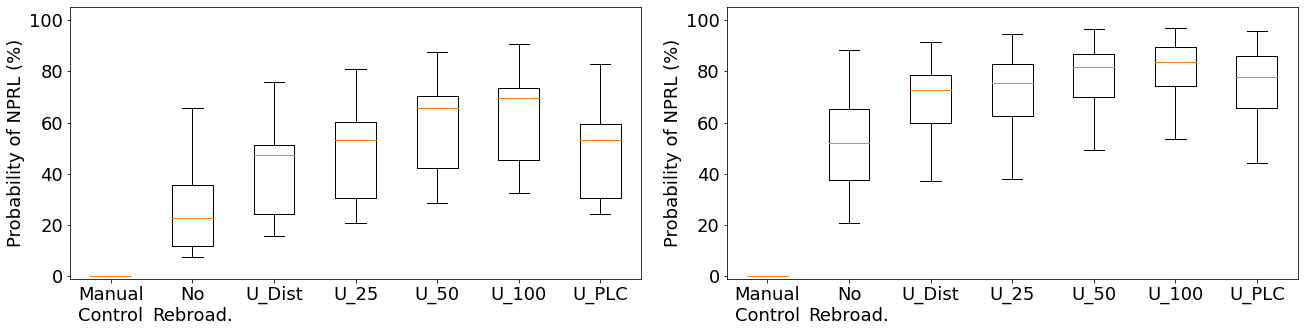

In [15]:
# Plot for nc = 2
plt.rcParams.update({'font.size': 18, 'xtick.labelsize':'medium', 'font.family': 'sans-serif'})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 5))
# # With Separate Box Plots for Each USI
# space = 0.2
# box_params = dict(widths=0.1)
# box1 = ax1.boxplot([manual_result_box[0], waypoint_result_box[0], dv_result_box[0], fp_25_result_box[0], fp_50_result_box[0], fp_100_result_box[0], pm_result_box[0]], 
#                    showmeans=False, whis=[0, 100], positions=np.arange(7)-1.5*space, 
#                    boxprops=dict(linestyle='-', linewidth=1,  color='tab:blue'), 
#                    whiskerprops=dict(linestyle='-', linewidth=1, color='tab:blue'), **box_params)
# box2 = ax1.boxplot([manual_result_box[1], waypoint_result_box[1], dv_result_box[1], fp_25_result_box[1], fp_50_result_box[1], fp_100_result_box[1], pm_result_box[1]], 
#                    showmeans=False, whis=[0, 100], positions=np.arange(7)-0.5*space,
#                    boxprops=dict(linestyle='--', linewidth=1,  color='tab:orange'), 
#                    whiskerprops=dict(linestyle='--', linewidth=1, color='tab:orange'), **box_params)
# box3 = ax1.boxplot([manual_result_box[2], waypoint_result_box[2], dv_result_box[2], fp_25_result_box[2], fp_50_result_box[2], fp_100_result_box[2], pm_result_box[2]], 
#                    showmeans=False, whis=[0, 100], positions=np.arange(7)+0.5*space,
#                    boxprops=dict(linestyle=':', linewidth=1,  color='tab:green'), 
#                    whiskerprops=dict(linestyle=':', linewidth=1, color='tab:green'), **box_params)
# box4 = ax1.boxplot([manual_result_box[3], waypoint_result_box[3], dv_result_box[3], fp_25_result_box[3], fp_50_result_box[3], fp_100_result_box[3], pm_result_box[3]], 
#                    showmeans=False, whis=[0, 100], positions=np.arange(7)+1.5*space,
#                    boxprops=dict(linestyle='dashdot', linewidth=1,  color='tab:red'), 
#                    whiskerprops=dict(linestyle='dashdot', linewidth=1, color='tab:red'), **box_params)
# ax1.set_xticks(np.arange(7), ["Manual\nControl", "No\nRebroad.", "U_Dist", "U_25", "U_50", "U_100", "U_PLC"], fontsize=16)
# ax1.legend((box1["boxes"][0], box2["boxes"][0], box3["boxes"][0], box4["boxes"][0]),
#                ["USI 10 ms", "USI 20 ms", "USI 66.7 ms", "USI 100 ms",], bbox_to_anchor=(0.55, 1.02, 1, 0.2), loc="lower center", fontsize=16, borderaxespad=0, ncol=8)

# With one box plots for results from all USIs
ax1.boxplot([[x for xs in manual_result_box for x in xs], [x for xs in waypoint_result_box for x in xs], [x for xs in dv_result_box for x in xs], [x for xs in fp_25_result_box for x in xs], 
             [x for xs in fp_50_result_box for x in xs], [x for xs in fp_100_result_box for x in xs], [x for xs in pm_result_box for x in xs]],
             showmeans=False, whis=[0, 100], labels=["Manual\nControl", "No\nRebroad.", "U_Dist", "U_25", "U_50", "U_100", "U_PLC"])

ax1.set_ylabel("Probability of NPRL (%)")
ax1.set_ylim(-1,105)
        
# # With Separate Box Plots for Each USI
# space = 0.2
# box_params = dict(widths=0.1)
# box1 = ax2.boxplot([manual_result_box_nc3[0], waypoint_result_box_nc3[0], dv_result_box_nc3[0], fp_25_result_box_nc3[0], fp_50_result_box_nc3[0], fp_100_result_box_nc3[0], pm_result_box_nc3[0]], 
#                    showmeans=False, whis=[0, 100], positions=np.arange(7)-1.5*space, 
#                    boxprops=dict(linestyle='-', linewidth=1,  color='tab:blue'), 
#                    whiskerprops=dict(linestyle='-', linewidth=1, color='tab:blue'), **box_params)
# box2 = ax2.boxplot([manual_result_box_nc3[1], waypoint_result_box_nc3[1], dv_result_box_nc3[1], fp_25_result_box_nc3[1], fp_50_result_box_nc3[1], fp_100_result_box_nc3[1], pm_result_box_nc3[1]], 
#                    showmeans=False, whis=[0, 100], positions=np.arange(7)-0.5*space,
#                    boxprops=dict(linestyle='--', linewidth=1,  color='tab:orange'), 
#                    whiskerprops=dict(linestyle='--', linewidth=1, color='tab:orange'), **box_params)
# box3 = ax2.boxplot([manual_result_box_nc3[2], waypoint_result_box_nc3[2], dv_result_box_nc3[2], fp_25_result_box_nc3[2], fp_50_result_box_nc3[2], fp_100_result_box_nc3[2], pm_result_box_nc3[2]], 
#                    showmeans=False, whis=[0, 100], positions=np.arange(7)+0.5*space,
#                    boxprops=dict(linestyle=':', linewidth=1,  color='tab:green'), 
#                    whiskerprops=dict(linestyle=':', linewidth=1, color='tab:green'), **box_params)
# box4 = ax2.boxplot([manual_result_box_nc3[3], waypoint_result_box_nc3[3], dv_result_box_nc3[3], fp_25_result_box_nc3[3], fp_50_result_box_nc3[3], fp_100_result_box_nc3[3], pm_result_box_nc3[3]], 
#                    showmeans=False, whis=[0, 100], positions=np.arange(7)+1.5*space,
#                    boxprops=dict(linestyle='dashdot', linewidth=1,  color='tab:red'), 
#                    whiskerprops=dict(linestyle='dashdot', linewidth=1, color='tab:red'), **box_params)
# ax2.set_xticks(np.arange(7), ["Manual\nControl", "No\nRebroad.", "U_Dist", "U_25", "U_50", "U_100", "U_PLC"], fontsize=16)

# With one box plots for results from all USIs
ax2.boxplot([[x for xs in manual_result_box_nc3 for x in xs], [x for xs in waypoint_result_box_nc3 for x in xs], [x for xs in dv_result_box_nc3 for x in xs], [x for xs in fp_25_result_box_nc3 for x in xs], 
             [x for xs in fp_50_result_box_nc3 for x in xs], [x for xs in fp_100_result_box_nc3 for x in xs], [x for xs in pm_result_box_nc3 for x in xs]],
             showmeans=False, whis=[0, 100], labels=["Manual\nControl", "No\nRebroad.", "U_Dist", "U_25", "U_50", "U_100", "U_PLC"])

ax2.set_ylabel("Probability of NPRL (%)")
ax2.set_ylim(-1,105)

plt.subplots_adjust(wspace=0.15)

#### For With GCS

In [ ]:
# Plot Percentage of Sim Runs with Consecutive Packet Failures
TH_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_PLC_{}_Interference_new"
DV_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Dist_{}_Interference_new"
FP_25_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed25_{}_Interference_new"
FP_50_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed50_{}_Interference_new"
FP_100_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed100_{}_Interference_new"
CASES = ["uav_scenario_0_processed", "uav_scenario_1_processed", "uav_scenario_2_processed",
         "manet_scenario_1_processed", "manet_scenario_a_processed", "manet_scenario_2_processed"]
MAX_RUN_NUM = 499 # Run num starts at 0
START_RUN_NUM = 0
END_RUN_NUM = 499
N_SECS = 2
usi_list = ["10", "20", "66.7", "100"]

# To store the percentage of sim runs with no cons packet failures
pm_gcs_result = []
fp_25_gcs_result = []
fp_50_gcs_result = []
fp_100_gcs_result = []
dv_gcs_result = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"
    # pm_gcs_df = compile_results(TH_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_25_gcs_df = compile_results(FP_25_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_50_gcs_df = compile_results(FP_50_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_100_gcs_df = compile_results(FP_100_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # dv_gcs_df = compile_results(DV_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    '''For Custom Run Num Range'''
    pm_gcs_df = compile_results_range(TH_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_25_gcs_df = compile_results_range(FP_25_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_50_gcs_df = compile_results_range(FP_50_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_100_gcs_df = compile_results_range(FP_100_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    dv_gcs_df = compile_results_range(DV_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    print(len(pm_gcs_df))
    '''Filter out runs where there are NaN results (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    pm_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_25_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_50_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_100_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    dv_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)

    pm_gcs_df.reset_index(inplace=True)
    fp_25_gcs_df.reset_index(inplace=True)
    fp_50_gcs_df.reset_index(inplace=True)
    fp_100_gcs_df.reset_index(inplace=True)
    dv_gcs_df.reset_index(inplace=True)

    runs_nan = (pm_gcs_df.isnull().any(axis=1).to_numpy()) | (dv_gcs_df.isnull().any(axis=1).to_numpy()) | \
                (fp_25_gcs_df.isnull().any(axis=1).to_numpy()) | (fp_50_gcs_df.isnull().any(axis=1).to_numpy()) | (fp_100_gcs_df.isnull().any(axis=1).to_numpy())
    pm_gcs_df_fil = pm_gcs_df.loc[~(runs_nan)]
    fp_25_gcs_df_fil = fp_25_gcs_df.loc[~(runs_nan)]
    fp_50_gcs_df_fil = fp_50_gcs_df.loc[~(runs_nan)]
    fp_100_gcs_df_fil = fp_100_gcs_df.loc[~(runs_nan)]
    dv_gcs_df_fil = dv_gcs_df.loc[~(runs_nan)]

    '''For each scheme, For each USI, Get percentages of sim runs with N_SECS consecutive packet failure in at least one link'''
    pm_gcs_result_usi = []
    fp_25_gcs_result_usi = []
    fp_50_gcs_result_usi = []
    fp_100_gcs_result_usi = []
    dv_gcs_result_usi = []

    for usi in ["10", "20", "66.7", "100"]:
        pm_gcs_df_usi = pm_gcs_df_fil.loc[(pm_gcs_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        pm_gcs_result_usi.append(len(pm_gcs_df_usi.loc[(pm_gcs_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (pm_gcs_df_usi["UAV_1_Cons_Fail"] == 0) & (pm_gcs_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (pm_gcs_df_usi["UAV_3_Cons_Fail"] == 0) & (pm_gcs_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (pm_gcs_df_usi["UAV_5_Cons_Fail"] == 0) & (pm_gcs_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (pm_gcs_df_usi["UAV_7_Cons_Fail"] == 0)])/len(pm_gcs_df_usi) * 100)
        fp_25_gcs_df_usi = fp_25_gcs_df_fil.loc[(fp_25_gcs_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_25_gcs_result_usi.append(len(fp_25_gcs_df_usi.loc[(fp_25_gcs_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_25_gcs_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_25_gcs_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_25_gcs_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_25_gcs_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_25_gcs_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_25_gcs_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_25_gcs_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_25_gcs_df_usi) * 100)
        fp_50_gcs_df_usi = fp_50_gcs_df_fil.loc[(fp_50_gcs_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_50_gcs_result_usi.append(len(fp_50_gcs_df_usi.loc[(fp_50_gcs_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_50_gcs_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_50_gcs_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_50_gcs_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_50_gcs_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_50_gcs_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_50_gcs_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_50_gcs_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_50_gcs_df_usi) * 100)
        fp_100_gcs_df_usi = fp_100_gcs_df_fil.loc[(fp_100_gcs_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_100_gcs_result_usi.append(len(fp_100_gcs_df_usi.loc[(fp_100_gcs_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_100_gcs_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_100_gcs_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_100_gcs_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_100_gcs_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_100_gcs_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_100_gcs_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_100_gcs_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_100_gcs_df_usi) * 100)
        dv_gcs_df_usi = dv_gcs_df_fil.loc[(dv_gcs_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        dv_gcs_result_usi.append(len(dv_gcs_df_usi.loc[(dv_gcs_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (dv_gcs_df_usi["UAV_1_Cons_Fail"] == 0) & (dv_gcs_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (dv_gcs_df_usi["UAV_3_Cons_Fail"] == 0) & (dv_gcs_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (dv_gcs_df_usi["UAV_5_Cons_Fail"] == 0) & (dv_gcs_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (dv_gcs_df_usi["UAV_7_Cons_Fail"] == 0)])/len(dv_gcs_df_usi) * 100)
    
    pm_gcs_result.append(pm_gcs_result_usi)
    fp_25_gcs_result.append(fp_25_gcs_result_usi)
    fp_50_gcs_result.append(fp_50_gcs_result_usi)
    fp_100_gcs_result.append(fp_100_gcs_result_usi)
    dv_gcs_result.append(dv_gcs_result_usi)

pm_gcs_result_box = [[x[i] for x in pm_gcs_result] for i in range(4)]
fp_25_gcs_result_box = [[x[i] for x in fp_25_gcs_result] for i in range(4)]
fp_50_gcs_result_box = [[x[i] for x in fp_50_gcs_result] for i in range(4)]
fp_100_gcs_result_box = [[x[i] for x in fp_100_gcs_result] for i in range(4)]
dv_gcs_result_box = [[x[i] for x in dv_gcs_result] for i in range(4)]

print("N_C = 2")
for j in range(4):
    print("USI: {}".format(usi_list[j]))
    for i in range(len(CASES)):
        print("{},{},{},{},{}".format(dv_gcs_result_box[j][i], fp_25_gcs_result_box[j][i], fp_50_gcs_result_box[j][i], fp_100_gcs_result_box[j][i], pm_gcs_result_box[j][i]))

# Now do it for nc of 3
N_SECS = 3

# To store the percentage of sim runs with no cons packet failures
pm_gcs_result = []
fp_25_gcs_result = []
fp_50_gcs_result = []
fp_100_gcs_result = []
dv_gcs_result = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"
    # pm_gcs_df = compile_results(TH_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_25_gcs_df = compile_results(FP_25_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_50_gcs_df = compile_results(FP_50_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_100_gcs_df = compile_results(FP_100_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # dv_gcs_df = compile_results(DV_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    '''For Custom Run Num Range'''
    pm_gcs_df = compile_results_range(TH_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_25_gcs_df = compile_results_range(FP_25_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_50_gcs_df = compile_results_range(FP_50_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_100_gcs_df = compile_results_range(FP_100_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    dv_gcs_df = compile_results_range(DV_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    print(len(pm_gcs_df))
    '''Filter out runs where there are NaN results (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    pm_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_25_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_50_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_100_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    dv_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)

    pm_gcs_df.reset_index(inplace=True)
    fp_25_gcs_df.reset_index(inplace=True)
    fp_50_gcs_df.reset_index(inplace=True)
    fp_100_gcs_df.reset_index(inplace=True)
    dv_gcs_df.reset_index(inplace=True)

    runs_nan = (pm_gcs_df.isnull().any(axis=1).to_numpy()) | (dv_gcs_df.isnull().any(axis=1).to_numpy()) | \
                (fp_25_gcs_df.isnull().any(axis=1).to_numpy()) | (fp_50_gcs_df.isnull().any(axis=1).to_numpy()) | (fp_100_gcs_df.isnull().any(axis=1).to_numpy())
    pm_gcs_df_fil = pm_gcs_df.loc[~(runs_nan)]
    fp_25_gcs_df_fil = fp_25_gcs_df.loc[~(runs_nan)]
    fp_50_gcs_df_fil = fp_50_gcs_df.loc[~(runs_nan)]
    fp_100_gcs_df_fil = fp_100_gcs_df.loc[~(runs_nan)]
    dv_gcs_df_fil = dv_gcs_df.loc[~(runs_nan)]

    '''For each scheme, For each USI, Get percentages of sim runs with N_SECS consecutive packet failure in at least one link'''
    pm_gcs_result_usi = []
    fp_25_gcs_result_usi = []
    fp_50_gcs_result_usi = []
    fp_100_gcs_result_usi = []
    dv_gcs_result_usi = []

    for usi in ["10", "20", "66.7", "100"]:
        pm_gcs_df_usi = pm_gcs_df_fil.loc[(pm_gcs_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        pm_gcs_result_usi.append(len(pm_gcs_df_usi.loc[(pm_gcs_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (pm_gcs_df_usi["UAV_1_Cons_Fail"] == 0) & (pm_gcs_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (pm_gcs_df_usi["UAV_3_Cons_Fail"] == 0) & (pm_gcs_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (pm_gcs_df_usi["UAV_5_Cons_Fail"] == 0) & (pm_gcs_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (pm_gcs_df_usi["UAV_7_Cons_Fail"] == 0)])/len(pm_gcs_df_usi) * 100)
        fp_25_gcs_df_usi = fp_25_gcs_df_fil.loc[(fp_25_gcs_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_25_gcs_result_usi.append(len(fp_25_gcs_df_usi.loc[(fp_25_gcs_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_25_gcs_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_25_gcs_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_25_gcs_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_25_gcs_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_25_gcs_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_25_gcs_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_25_gcs_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_25_gcs_df_usi) * 100)
        fp_50_gcs_df_usi = fp_50_gcs_df_fil.loc[(fp_50_gcs_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_50_gcs_result_usi.append(len(fp_50_gcs_df_usi.loc[(fp_50_gcs_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_50_gcs_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_50_gcs_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_50_gcs_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_50_gcs_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_50_gcs_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_50_gcs_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_50_gcs_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_50_gcs_df_usi) * 100)
        fp_100_gcs_df_usi = fp_100_gcs_df_fil.loc[(fp_100_gcs_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_100_gcs_result_usi.append(len(fp_100_gcs_df_usi.loc[(fp_100_gcs_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_100_gcs_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_100_gcs_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_100_gcs_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_100_gcs_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_100_gcs_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_100_gcs_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_100_gcs_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_100_gcs_df_usi) * 100)
        dv_gcs_df_usi = dv_gcs_df_fil.loc[(dv_gcs_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        dv_gcs_result_usi.append(len(dv_gcs_df_usi.loc[(dv_gcs_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (dv_gcs_df_usi["UAV_1_Cons_Fail"] == 0) & (dv_gcs_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (dv_gcs_df_usi["UAV_3_Cons_Fail"] == 0) & (dv_gcs_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (dv_gcs_df_usi["UAV_5_Cons_Fail"] == 0) & (dv_gcs_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (dv_gcs_df_usi["UAV_7_Cons_Fail"] == 0)])/len(dv_gcs_df_usi) * 100)
    
    pm_gcs_result.append(pm_gcs_result_usi)
    fp_25_gcs_result.append(fp_25_gcs_result_usi)
    fp_50_gcs_result.append(fp_50_gcs_result_usi)
    fp_100_gcs_result.append(fp_100_gcs_result_usi)
    dv_gcs_result.append(dv_gcs_result_usi)

pm_gcs_result_box_nc3 = [[x[i] for x in pm_gcs_result] for i in range(4)]
fp_25_gcs_result_box_nc3 = [[x[i] for x in fp_25_gcs_result] for i in range(4)]
fp_50_gcs_result_box_nc3 = [[x[i] for x in fp_50_gcs_result] for i in range(4)]
fp_100_gcs_result_box_nc3 = [[x[i] for x in fp_100_gcs_result] for i in range(4)]
dv_gcs_result_box_nc3 = [[x[i] for x in dv_gcs_result] for i in range(4)]

print("N_C = 3")
for j in range(4):
    print("USI: {}".format(usi_list[j]))
    for i in range(len(CASES)):
        print("{},{},{},{},{}".format(dv_gcs_result_box_nc3[j][i], fp_25_gcs_result_box_nc3[j][i], fp_50_gcs_result_box_nc3[j][i], fp_100_gcs_result_box_nc3[j][i], pm_gcs_result_box_nc3[j][i]))

1151
2552
2700
2585
2691
2699
N_C = 2
USI: 10
100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0
99.65397923875432,99.65397923875432,100.0,99.65397923875432,99.30795847750865
98.98989898989899,99.66329966329967,99.32659932659934,99.66329966329967,99.32659932659934
USI: 20
100.0,100.0,100.0,100.0,100.0
100.0,100.0,99.85380116959064,100.0,100.0
99.28571428571429,99.28571428571429,99.71428571428571,99.57142857142857,99.85714285714286
98.23269513991163,97.64359351988217,99.41089837997055,98.52724594992637,99.41089837997055
93.76811594202898,92.89855072463769,97.2463768115942,96.23188405797102,94.34782608695652
87.66140602582496,87.94835007173602,91.10473457675752,93.974175035868,89.6700143472023
USI: 66.7
100.0,100.0,100.0,100.0,100.0
100.0,99.86263736263736,100.0,99.58791208791209,100.0
99.7496871088861,99.49937421777221,99.62453066332915,100.0,99.12390488110138
98.39786381842457,97.46328437917224,98.79839786381842,98.39

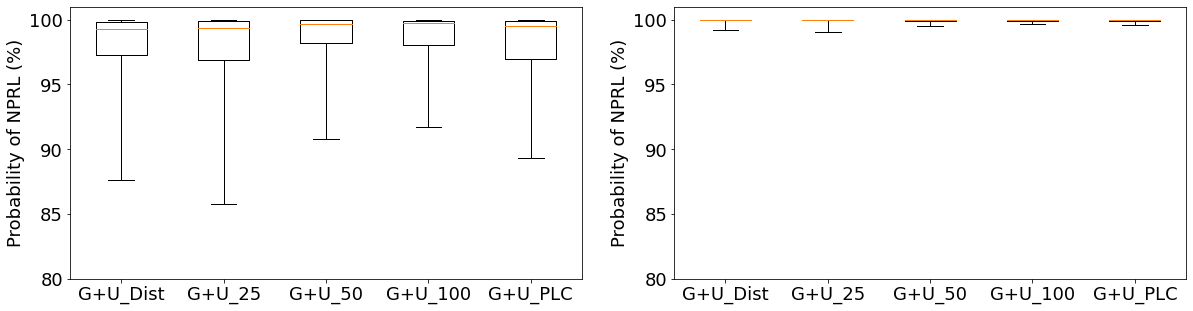

In [20]:
# Plot for nc = 2
plt.rcParams.update({'font.size': 18, 'xtick.labelsize':'medium', 'font.family': 'sans-serif'})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
# # With Separate Box Plots for Each USI
# space = 0.2
# box_params = dict(widths=0.1)
# box1 = ax1.boxplot([dv_gcs_result_box[0], fp_25_gcs_result_box[0], fp_50_gcs_result_box[0], fp_100_gcs_result_box[0], pm_gcs_result_box[0]], 
#                    showmeans=False, whis=[0, 100], positions=np.arange(5)-1.5*space, 
#                    boxprops=dict(linestyle='-', linewidth=1,  color='tab:blue'), 
#                    whiskerprops=dict(linestyle='-', linewidth=1, color='tab:blue'), **box_params)
# box2 = ax1.boxplot([dv_gcs_result_box[1], fp_25_gcs_result_box[1], fp_50_gcs_result_box[1], fp_100_gcs_result_box[1], pm_gcs_result_box[1]], 
#                    showmeans=False, whis=[0, 100], positions=np.arange(5)-0.5*space,
#                    boxprops=dict(linestyle='--', linewidth=1,  color='tab:orange'), 
#                    whiskerprops=dict(linestyle='--', linewidth=1, color='tab:orange'), **box_params)
# box3 = ax1.boxplot([dv_gcs_result_box[2], fp_25_gcs_result_box[2], fp_50_gcs_result_box[2], fp_100_gcs_result_box[2], pm_gcs_result_box[2]], 
#                    showmeans=False, whis=[0, 100], positions=np.arange(5)+0.5*space,
#                    boxprops=dict(linestyle=':', linewidth=1,  color='tab:green'), 
#                    whiskerprops=dict(linestyle=':', linewidth=1, color='tab:green'), **box_params)
# box4 = ax1.boxplot([dv_gcs_result_box[3], fp_25_gcs_result_box[3], fp_50_gcs_result_box[3], fp_100_gcs_result_box[3], pm_gcs_result_box[3]], 
#                    showmeans=False, whis=[0, 100], positions=np.arange(5)+1.5*space,
#                    boxprops=dict(linestyle='dashdot', linewidth=1,  color='tab:red'), 
#                    whiskerprops=dict(linestyle='dashdot', linewidth=1, color='tab:red'), **box_params)
# ax1.set_xticks(np.arange(5), ["G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"], fontsize=16)
# ax1.legend((box1["boxes"][0], box2["boxes"][0], box3["boxes"][0], box4["boxes"][0]),
#                ["USI 10 ms", "USI 20 ms", "USI 66.7 ms", "USI 100 ms",], bbox_to_anchor=(0.55, 1.02, 1, 0.2), loc="lower center", fontsize=16, borderaxespad=0, ncol=4)

# With one box plots for results from all USIs
ax1.boxplot([[x for xs in dv_gcs_result_box for x in xs], [x for xs in fp_25_gcs_result_box for x in xs], [x for xs in fp_50_gcs_result_box for x in xs], 
             [x for xs in fp_100_gcs_result_box for x in xs], [x for xs in pm_gcs_result_box for x in xs]],
             showmeans=False, whis=[0, 100], labels=["G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"])

ax1.set_ylabel("Probability of NPRL (%)")
ax1.set_ylim(80,101)

# # With Separate Box Plots for Each USI
# space = 0.2
# box_params = dict(widths=0.1)
# box1 = ax2.boxplot([dv_gcs_result_box_nc3[0], fp_25_gcs_result_box_nc3[0], fp_50_gcs_result_box_nc3[0], fp_100_gcs_result_box_nc3[0], pm_gcs_result_box_nc3[0]], 
#                    showmeans=False, whis=[0, 100], positions=np.arange(5)-1.5*space, 
#                    boxprops=dict(linestyle='-', linewidth=1,  color='tab:blue'), 
#                    whiskerprops=dict(linestyle='-', linewidth=1, color='tab:blue'), **box_params)
# box2 = ax2.boxplot([dv_gcs_result_box_nc3[1], fp_25_gcs_result_box_nc3[1], fp_50_gcs_result_box_nc3[1], fp_100_gcs_result_box_nc3[1], pm_gcs_result_box_nc3[1]], 
#                    showmeans=False, whis=[0, 100], positions=np.arange(5)-0.5*space,
#                    boxprops=dict(linestyle='--', linewidth=1,  color='tab:orange'), 
#                    whiskerprops=dict(linestyle='--', linewidth=1, color='tab:orange'), **box_params)
# box3 = ax2.boxplot([dv_gcs_result_box_nc3[2], fp_25_gcs_result_box_nc3[2], fp_50_gcs_result_box_nc3[2], fp_100_gcs_result_box_nc3[2], pm_gcs_result_box_nc3[2]], 
#                    showmeans=False, whis=[0, 100], positions=np.arange(5)+0.5*space,
#                    boxprops=dict(linestyle=':', linewidth=1,  color='tab:green'), 
#                    whiskerprops=dict(linestyle=':', linewidth=1, color='tab:green'), **box_params)
# box4 = ax2.boxplot([dv_gcs_result_box_nc3[3], fp_25_gcs_result_box_nc3[3], fp_50_gcs_result_box_nc3[3], fp_100_gcs_result_box_nc3[3], pm_gcs_result_box_nc3[3]], 
#                    showmeans=False, whis=[0, 100], positions=np.arange(5)+1.5*space,
#                    boxprops=dict(linestyle='dashdot', linewidth=1,  color='tab:red'), 
#                    whiskerprops=dict(linestyle='dashdot', linewidth=1, color='tab:red'), **box_params)
# ax2.set_xticks(np.arange(5), ["G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"], fontsize=16)

# With one box plots for results from all USIs
ax2.boxplot([[x for xs in dv_gcs_result_box_nc3 for x in xs], [x for xs in fp_25_gcs_result_box_nc3 for x in xs], [x for xs in fp_50_gcs_result_box_nc3 for x in xs], 
             [x for xs in fp_100_gcs_result_box_nc3 for x in xs], [x for xs in pm_gcs_result_box_nc3 for x in xs]],
             showmeans=False, whis=[0, 100], labels=["G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"])

ax2.set_ylabel("Probability of NPRL (%)")
ax2.set_ylim(80,101)

plt.subplots_adjust(wspace=0.18)

## Plot Results PM Finetuning

### For UL and DL Reliabilitues, and UPRR (For Fig. E)

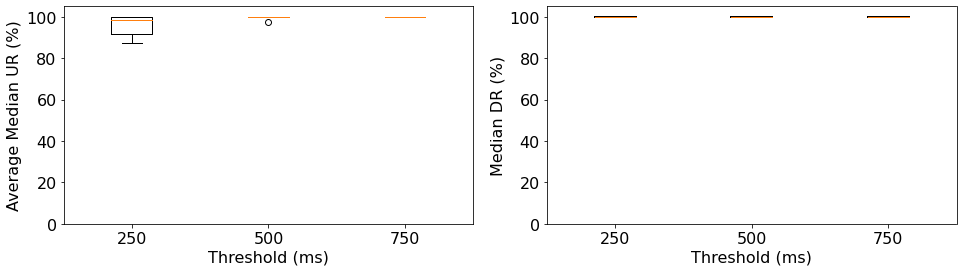

In [7]:
# Plot Average Median DL Reliability and Median UL Reliability
# This is for Fig. E

# PM_150 = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/PM_Based_{}_Interference_new"
# PM_500 = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/PM_Based_RL_500ms_{}_Interference_new"
# PM_850 = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/PM_Based_RL_750ms_{}_Interference_new"

PM_150 = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/PM_GCS_Based_{}_Interference_new"
PM_500 = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/PM_GCS_Based_RL_500ms_{}_Interference_new"
PM_850 = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/PM_GCS_Based_RL_750ms_{}_Interference_new"

CASES = ["uav_scenario_0_processed", "uav_scenario_1_processed", "uav_scenario_2_processed",
         "manet_scenario_1_processed", "manet_scenario_a_processed", "manet_scenario_2_processed"]
MAX_RUN_NUM = 499 # Run num starts at 0

pm_150_med_rel = []
pm_500_med_rel = []
pm_850_med_rel = []

pm_150_med_ul_rel = []
pm_500_med_ul_rel = []
pm_850_med_ul_rel = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"
    pm_150_df = compile_results(PM_150.format(intf_type), [case], MAX_RUN_NUM)
    pm_500_df = compile_results(PM_500.format(intf_type), [case], MAX_RUN_NUM)
    pm_850_df = compile_results(PM_850.format(intf_type), [case], MAX_RUN_NUM)

    '''Temporary resolution to error in processing script introducing redundant columns'''
    try:
        pm_150_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        pm_500_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        pm_850_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass

    '''Filter out runs where there are NaN reliability (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    pm_150_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_500_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_850_df.sort_values(by=["Scenario", "Run"], inplace=True)

    pm_150_df.reset_index(inplace=True)
    pm_500_df.reset_index(inplace=True)
    pm_850_df.reset_index(inplace=True)

    runs_nan = (pm_150_df.isnull().any(axis=1).to_numpy()) | (pm_500_df.isnull().any(axis=1).to_numpy()) | (pm_850_df.isnull().any(axis=1).to_numpy()) 
    pm_150_df_fil = pm_150_df.loc[~(runs_nan)]
    pm_500_df_fil = pm_500_df.loc[~(runs_nan)]
    pm_850_df_fil = pm_850_df.loc[~(runs_nan)]

    '''Get Median DL Reliability'''
    pm_150_dl_rel = np.concatenate((pm_150_df_fil["Reliability_UAV_0"].values*100, pm_150_df_fil["Reliability_UAV_1"].values*100, pm_150_df_fil["Reliability_UAV_2"].values*100, pm_150_df_fil["Reliability_UAV_3"].values*100,
                                pm_150_df_fil["Reliability_UAV_4"].values*100, pm_150_df_fil["Reliability_UAV_5"].values*100, pm_150_df_fil["Reliability_UAV_6"].values*100, pm_150_df_fil["Reliability_UAV_7"].values*100))
    pm_500_dl_rel = np.concatenate((pm_500_df_fil["Reliability_UAV_0"].values*100, pm_500_df_fil["Reliability_UAV_1"].values*100, pm_500_df_fil["Reliability_UAV_2"].values*100, pm_500_df_fil["Reliability_UAV_3"].values*100,
                                pm_500_df_fil["Reliability_UAV_4"].values*100, pm_500_df_fil["Reliability_UAV_5"].values*100, pm_500_df_fil["Reliability_UAV_6"].values*100, pm_500_df_fil["Reliability_UAV_7"].values*100))
    pm_850_dl_rel = np.concatenate((pm_850_df_fil["Reliability_UAV_0"].values*100, pm_850_df_fil["Reliability_UAV_1"].values*100, pm_850_df_fil["Reliability_UAV_2"].values*100, pm_850_df_fil["Reliability_UAV_3"].values*100,
                                pm_850_df_fil["Reliability_UAV_4"].values*100, pm_850_df_fil["Reliability_UAV_5"].values*100, pm_850_df_fil["Reliability_UAV_6"].values*100, pm_850_df_fil["Reliability_UAV_7"].values*100))
    
    pm_150_med_rel.append(np.median(pm_150_dl_rel))
    pm_500_med_rel.append(np.median(pm_500_dl_rel))
    pm_850_med_rel.append(np.median(pm_850_dl_rel))

    '''Get Median UL Reliability'''
    pm_150_med_ul_rel.append(pm_150_df_fil["Total_Reliability_UL"].median() * 100)
    pm_500_med_ul_rel.append(pm_500_df_fil["Total_Reliability_UL"].median() * 100)
    pm_850_med_ul_rel.append(pm_850_df_fil["Total_Reliability_UL"].median() * 100)

plt.rcParams.update({'font.size': 16, 'xtick.labelsize':'medium'})
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
# for i in range(len(CASES)):
#     ax1.plot(["250", "500", "750"], # NOTE: x-axis is time elapsed, not remaining life
#              [pm_850_med_rel[i], pm_500_med_rel[i], pm_150_med_rel[i]], '-o')
ax1.boxplot([pm_850_med_rel, pm_500_med_rel, pm_150_med_rel], showmeans=False, labels=["250", "500", "750"])
ax1.set_ylabel("Average Median UR (%)")
ax1.set_xlabel('Threshold (ms)')
ax1.set_ylim(0,105)

# for i in range(len(CASES)):
#     ax2.plot(["250", "500", "750"], # NOTE: x-axis is time elapsed, not remaining life
#              [pm_850_med_ul_rel[i], pm_500_med_ul_rel[i], pm_150_med_ul_rel[i]], '-o')
ax2.boxplot([pm_850_med_ul_rel, pm_500_med_ul_rel, pm_150_med_ul_rel], showmeans=False, labels=["250", "500", "750"], boxprops=dict(linewidth=2))
ax2.set_ylabel("Median DR (%)")
ax2.set_xlabel('Threshold (ms)')
ax2.set_ylim(0,105)

# plt.legend( ["UAV 1", "UAV 2", "UAV 3", "MANET 1", "MANET 2", "MANET 3"], bbox_to_anchor=(-0.35, 1.1, 1, 0.2), loc="lower right", fontsize=14, ncol=6) 
plt.subplots_adjust(wspace=0.18)


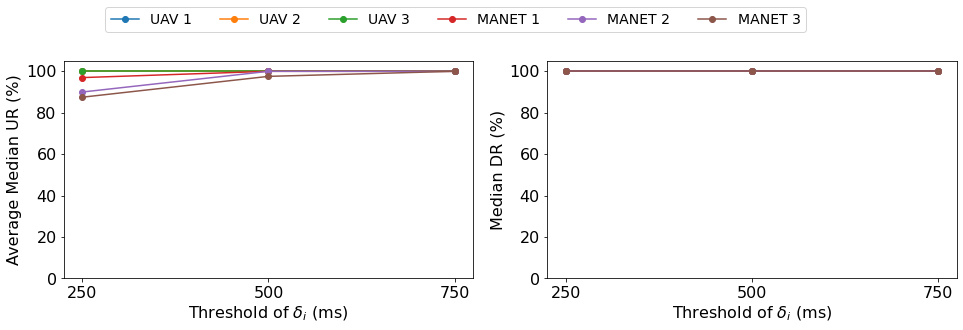

In [11]:
'''OLD, DEPRECATED'''
# fig, ax = plt.subplots(figsize=(10, 4))
# plt.rcParams.update({'font.size': 16, 'xtick.labelsize':'small'})
# for i in range(len(CASES)):
#     plt.plot(["25", "50", "75"], 
#              [pm_850_90[i], pm_500_90[i], pm_150_90[i]], '-o')
# plt.legend( ["UAV 1", "UAV 2", "UAV 3", "MANET 1", "MANET 2", "MANET 3"], bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower center", fontsize=12, borderaxespad=0, ncol=6) 
# plt.ylabel("Percentage (%)")
# plt.xlabel('Percentage of Packet Delay Constraint (%)')
# plt.ylim(0,100)
# plt.text(0.33, -0.2, "| ------ Waypoint Control with Only UAV Rebroadcasting ------ |", transform=ax.transAxes, fontsize=14)
# plt.text(0.87, -0.2, "         With GCS    \n|- Rebroadcasting -|", transform=ax.transAxes, fontsize=14)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plt.rcParams.update({'font.size': 16, 'xtick.labelsize':'medium'})
for i in range(len(CASES)):
    ax1.plot(["250", "500", "750"], # NOTE: x-axis is time elapsed, not remaining life
             [pm_850_med_rel[i], pm_500_med_rel[i], pm_150_med_rel[i]], '-o')
# plt.legend( ["UAV 1", "UAV 2", "UAV 3", "MANET 1", "MANET 2", "MANET 3"], loc="lower right", fontsize=14, ncol=2) 
ax1.set_ylabel("Average Median UR (%)")
ax1.set_xlabel('Threshold of $\\delta_i$ (ms)')
ax1.set_ylim(0,105)
# plt.text(0.33, -0.2, "| ------ Waypoint Control with Only UAV Rebroadcasting ------ |", transform=ax.transAxes, fontsize=14)
# plt.text(0.87, -0.2, "         With GCS    \n|- Rebroadcasting -|", transform=ax.transAxes, fontsize=14)

# fig, ax = plt.subplots(figsize=(10, 5))
# plt.rcParams.update({'font.size': 16, 'xtick.labelsize':'medium'})
for i in range(len(CASES)):
    ax2.plot(["250", "500", "750"], 
             [pm_850_med_ul_rel[i], pm_500_med_ul_rel[i], pm_150_med_ul_rel[i]], '-o')
# plt.legend( ["UAV 1", "UAV 2", "UAV 3", "MANET 1", "MANET 2", "MANET 3"], loc="lower right", fontsize=14, ncol=2) 
ax2.set_ylabel("Median DR (%)")
ax2.set_xlabel('Threshold of $\\delta_i$ (ms)')
ax2.set_ylim(0,105)
# plt.text(0.33, -0.2, "| ------ Waypoint Control with Only UAV Rebroadcasting ------ |", transform=ax.transAxes, fontsize=14)
# plt.text(0.87, -0.2, "         With GCS    \n|- Rebroadcasting -|", transform=ax.transAxes, fontsize=14)
plt.legend( ["UAV 1", "UAV 2", "UAV 3", "MANET 1", "MANET 2", "MANET 3"], bbox_to_anchor=(-0.35, 1.1, 1, 0.2), loc="lower right", fontsize=14, ncol=6) 
plt.subplots_adjust(wspace=0.18)

# fig, ax = plt.subplots(figsize=(8, 4))
# plt.rcParams.update({'font.size': 16, 'xtick.labelsize':'medium'})
# for i in range(len(CASES)):
#     plt.plot(["250", "500", "750"], 
#              [pm_850_med_ul_uprr[i], pm_500_med_ul_uprr[i], pm_150_med_ul_uprr[i]], '-o')
# plt.legend( ["UAV 1", "UAV 2", "UAV 3", "MANET 1", "MANET 2", "MANET 3"], bbox_to_anchor=(0, 1.1, 1, 0.2), loc="lower center", fontsize=14, borderaxespad=0, ncol=6) 
# # plt.legend( ["UAV 1", "UAV 2", "UAV 3", "MANET 1", "MANET 2", "MANET 3"], loc="lower right", fontsize=14, ncol=2) 
# plt.ylabel("Average Median\nBroadcast Efficiency (%)")
# plt.xlabel('Percentage of Packet Delay Constraint (%)')
# plt.ylim(0,105)
# # plt.text(-0.05, -0.3, "| ---------- Waypoint Control with Only UAV Rebroadcasting ---------- |", transform=ax.transAxes, fontsize=14)
# # plt.text(0.83, -0.3, "         With GCS    \n| - Rebroadcasting - |", transform=ax.transAxes, fontsize=14)


In [10]:
print(pm_150_med_rel)
print(pm_500_med_rel)
print(pm_850_med_rel)

[90.0, 88.88888888888889, 86.95652173913044, 76.47058823529412, 68.75, 66.66666666666666]
[88.88888888888889, 88.88888888888889, 86.36363636363636, 76.47058823529412, 68.75, 66.66666666666666]
[88.88888888888889, 87.87878787878788, 85.36585365853658, 76.47058823529412, 68.42105263157895, 66.66666666666666]


In [9]:
print(pm_150_med_ul_uprr)
print(pm_500_med_ul_uprr)
print(pm_850_med_ul_uprr)

[47.42058069127912, 45.46130952380952, 45.09680134680134, 46.45910225792444, 45.74254424163019, 45.532616814645266]
[48.4097450373562, 47.01937134502923, 47.40338164251207, 48.007484011494725, 48.208600138060206, 48.306122753979636]
[55.84967577411542, 55.056423611111114, 55.96387629818693, 55.5116492627381, 56.730769230769226, 57.778393462001866]


In [34]:
print(",".join([str(i) for i in pm_150_med_ul_rel]))
print(",".join([str(i) for i in pm_500_med_ul_rel]))
print(",".join([str(i) for i in pm_850_med_ul_rel]))

100.0,100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0,100.0
100.0,100.0,100.0,100.0,100.0,100.0


### For UPRR

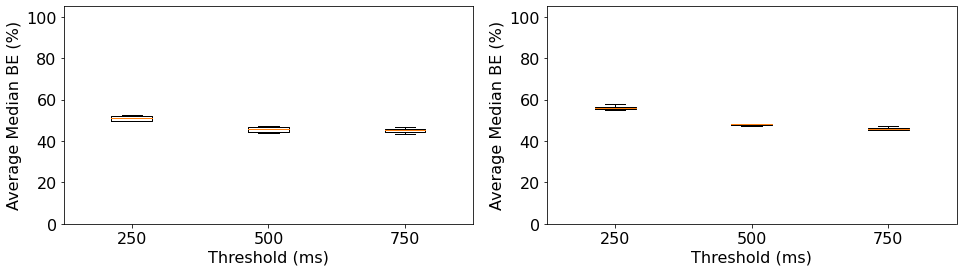

In [8]:
CASES = ["uav_scenario_0_processed", "uav_scenario_1_processed", "uav_scenario_2_processed",
         "manet_scenario_1_processed", "manet_scenario_a_processed", "manet_scenario_2_processed"]
MAX_RUN_NUM = 499 # Run num starts at 0

''' First, Plot for PLCB-'''
PM_150 = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/PM_Based_{}_Interference_new"
PM_500 = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/PM_Based_RL_500ms_{}_Interference_new"
PM_850 = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/PM_Based_RL_750ms_{}_Interference_new"

pm_150_med_ul_uprr = []
pm_500_med_ul_uprr = []
pm_850_med_ul_uprr = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"
    pm_150_df = compile_results(PM_150.format(intf_type), [case], MAX_RUN_NUM)
    pm_500_df = compile_results(PM_500.format(intf_type), [case], MAX_RUN_NUM)
    pm_850_df = compile_results(PM_850.format(intf_type), [case], MAX_RUN_NUM)

    '''Temporary resolution to error in processing script introducing redundant columns'''
    try:
        pm_150_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        pm_500_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        pm_850_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass

    '''Filter out runs where there are NaN reliability (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    pm_150_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_500_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_850_df.sort_values(by=["Scenario", "Run"], inplace=True)

    pm_150_df.reset_index(inplace=True)
    pm_500_df.reset_index(inplace=True)
    pm_850_df.reset_index(inplace=True)

    runs_nan = (pm_150_df.isnull().any(axis=1).to_numpy()) | (pm_500_df.isnull().any(axis=1).to_numpy()) | (pm_850_df.isnull().any(axis=1).to_numpy()) 
    pm_150_df_fil = pm_150_df.loc[~(runs_nan)]
    pm_500_df_fil = pm_500_df.loc[~(runs_nan)]
    pm_850_df_fil = pm_850_df.loc[~(runs_nan)]

    '''Get Median UPRR'''
    # pm_150_dl_uprr = np.concatenate((pm_150_df_fil["UPRR_UAV_0"].values*100, pm_150_df_fil["UPRR_UAV_1"].values*100, pm_150_df_fil["UPRR_UAV_2"].values*100, pm_150_df_fil["UPRR_UAV_3"].values*100,
    #                             pm_150_df_fil["UPRR_UAV_4"].values*100, pm_150_df_fil["UPRR_UAV_5"].values*100, pm_150_df_fil["UPRR_UAV_6"].values*100, pm_150_df_fil["UPRR_UAV_7"].values*100))
    # pm_500_dl_uprr = np.concatenate((pm_500_df_fil["UPRR_UAV_0"].values*100, pm_500_df_fil["UPRR_UAV_1"].values*100, pm_500_df_fil["UPRR_UAV_2"].values*100, pm_500_df_fil["UPRR_UAV_3"].values*100,
    #                             pm_500_df_fil["UPRR_UAV_4"].values*100, pm_500_df_fil["UPRR_UAV_5"].values*100, pm_500_df_fil["UPRR_UAV_6"].values*100, pm_500_df_fil["UPRR_UAV_7"].values*100))
    # pm_850_dl_uprr = np.concatenate((pm_850_df_fil["UPRR_UAV_0"].values*100, pm_850_df_fil["UPRR_UAV_1"].values*100, pm_850_df_fil["UPRR_UAV_2"].values*100, pm_850_df_fil["UPRR_UAV_3"].values*100,
    #                             pm_850_df_fil["UPRR_UAV_4"].values*100, pm_850_df_fil["UPRR_UAV_5"].values*100, pm_850_df_fil["UPRR_UAV_6"].values*100, pm_850_df_fil["UPRR_UAV_7"].values*100))
    pm_150_dl_uprr = np.mean((pm_150_df_fil["UPRR_UAV_0"].median()*100, pm_150_df_fil["UPRR_UAV_1"].median()*100, pm_150_df_fil["UPRR_UAV_2"].median()*100, pm_150_df_fil["UPRR_UAV_3"].median()*100,
                                pm_150_df_fil["UPRR_UAV_4"].median()*100, pm_150_df_fil["UPRR_UAV_5"].median()*100, pm_150_df_fil["UPRR_UAV_6"].median()*100, pm_150_df_fil["UPRR_UAV_7"].median()*100))
    pm_500_dl_uprr = np.mean((pm_500_df_fil["UPRR_UAV_0"].median()*100, pm_500_df_fil["UPRR_UAV_1"].median()*100, pm_500_df_fil["UPRR_UAV_2"].median()*100, pm_500_df_fil["UPRR_UAV_3"].median()*100,
                                pm_500_df_fil["UPRR_UAV_4"].median()*100, pm_500_df_fil["UPRR_UAV_5"].median()*100, pm_500_df_fil["UPRR_UAV_6"].median()*100, pm_500_df_fil["UPRR_UAV_7"].median()*100))
    pm_850_dl_uprr = np.mean((pm_850_df_fil["UPRR_UAV_0"].median()*100, pm_850_df_fil["UPRR_UAV_1"].median()*100, pm_850_df_fil["UPRR_UAV_2"].median()*100, pm_850_df_fil["UPRR_UAV_3"].median()*100,
                                pm_850_df_fil["UPRR_UAV_4"].median()*100, pm_850_df_fil["UPRR_UAV_5"].median()*100, pm_850_df_fil["UPRR_UAV_6"].median()*100, pm_850_df_fil["UPRR_UAV_7"].median()*100))
    pm_150_med_ul_uprr.append(np.median(pm_150_dl_uprr))
    pm_500_med_ul_uprr.append(np.median(pm_500_dl_uprr))
    pm_850_med_ul_uprr.append(np.median(pm_850_dl_uprr))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plt.rcParams.update({'font.size': 16, 'xtick.labelsize':'medium'})
# for i in range(len(CASES)):
#     ax1.plot(["250", "500", "750"], 
#              [pm_850_med_ul_uprr[i], pm_500_med_ul_uprr[i], pm_150_med_ul_uprr[i]], '-o')
ax1.boxplot([pm_850_med_ul_uprr, pm_500_med_ul_uprr, pm_150_med_ul_uprr], showmeans=False, labels=["250", "500", "750"])
# plt.legend( ["UAV 1", "UAV 2", "UAV 3", "MANET 1", "MANET 2", "MANET 3"], bbox_to_anchor=(0, 1.1, 1, 0.2), loc="lower center", fontsize=14, borderaxespad=0, ncol=6) 
# plt.legend( ["UAV 1", "UAV 2", "UAV 3", "MANET 1", "MANET 2", "MANET 3"], loc="lower right", fontsize=14, ncol=2) 
ax1.set_ylabel("Average Median BE (%)")
ax1.set_xlabel('Threshold (ms)')
ax1.set_ylim(0,105)
# plt.text(-0.05, -0.3, "| ---------- Waypoint Control with Only UAV Rebroadcasting ---------- |", transform=ax.transAxes, fontsize=14)
# plt.text(0.83, -0.3, "         With GCS    \n| - Rebroadcasting - |", transform=ax.transAxes, fontsize=14)

''' Then, Plot for PLCB+ '''
PM_150 = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/PM_GCS_Based_{}_Interference_new"
PM_500 = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/PM_GCS_Based_RL_500ms_{}_Interference_new"
PM_850 = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/PM_GCS_Based_RL_750ms_{}_Interference_new"

pm_150_med_ul_uprr = []
pm_500_med_ul_uprr = []
pm_850_med_ul_uprr = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"
    pm_150_df = compile_results(PM_150.format(intf_type), [case], MAX_RUN_NUM)
    pm_500_df = compile_results(PM_500.format(intf_type), [case], MAX_RUN_NUM)
    pm_850_df = compile_results(PM_850.format(intf_type), [case], MAX_RUN_NUM)

    '''Temporary resolution to error in processing script introducing redundant columns'''
    try:
        pm_150_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        pm_500_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        pm_850_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass

    '''Filter out runs where there are NaN reliability (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    pm_150_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_500_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_850_df.sort_values(by=["Scenario", "Run"], inplace=True)

    pm_150_df.reset_index(inplace=True)
    pm_500_df.reset_index(inplace=True)
    pm_850_df.reset_index(inplace=True)

    runs_nan = (pm_150_df.isnull().any(axis=1).to_numpy()) | (pm_500_df.isnull().any(axis=1).to_numpy()) | (pm_850_df.isnull().any(axis=1).to_numpy()) 
    pm_150_df_fil = pm_150_df.loc[~(runs_nan)]
    pm_500_df_fil = pm_500_df.loc[~(runs_nan)]
    pm_850_df_fil = pm_850_df.loc[~(runs_nan)]

    '''Get Median UPRR'''
    # pm_150_dl_uprr = np.concatenate((pm_150_df_fil["UPRR_UAV_0"].values*100, pm_150_df_fil["UPRR_UAV_1"].values*100, pm_150_df_fil["UPRR_UAV_2"].values*100, pm_150_df_fil["UPRR_UAV_3"].values*100,
    #                             pm_150_df_fil["UPRR_UAV_4"].values*100, pm_150_df_fil["UPRR_UAV_5"].values*100, pm_150_df_fil["UPRR_UAV_6"].values*100, pm_150_df_fil["UPRR_UAV_7"].values*100))
    # pm_500_dl_uprr = np.concatenate((pm_500_df_fil["UPRR_UAV_0"].values*100, pm_500_df_fil["UPRR_UAV_1"].values*100, pm_500_df_fil["UPRR_UAV_2"].values*100, pm_500_df_fil["UPRR_UAV_3"].values*100,
    #                             pm_500_df_fil["UPRR_UAV_4"].values*100, pm_500_df_fil["UPRR_UAV_5"].values*100, pm_500_df_fil["UPRR_UAV_6"].values*100, pm_500_df_fil["UPRR_UAV_7"].values*100))
    # pm_850_dl_uprr = np.concatenate((pm_850_df_fil["UPRR_UAV_0"].values*100, pm_850_df_fil["UPRR_UAV_1"].values*100, pm_850_df_fil["UPRR_UAV_2"].values*100, pm_850_df_fil["UPRR_UAV_3"].values*100,
    #                             pm_850_df_fil["UPRR_UAV_4"].values*100, pm_850_df_fil["UPRR_UAV_5"].values*100, pm_850_df_fil["UPRR_UAV_6"].values*100, pm_850_df_fil["UPRR_UAV_7"].values*100))
    pm_150_dl_uprr = np.mean((pm_150_df_fil["UPRR_UAV_0"].median()*100, pm_150_df_fil["UPRR_UAV_1"].median()*100, pm_150_df_fil["UPRR_UAV_2"].median()*100, pm_150_df_fil["UPRR_UAV_3"].median()*100,
                                pm_150_df_fil["UPRR_UAV_4"].median()*100, pm_150_df_fil["UPRR_UAV_5"].median()*100, pm_150_df_fil["UPRR_UAV_6"].median()*100, pm_150_df_fil["UPRR_UAV_7"].median()*100))
    pm_500_dl_uprr = np.mean((pm_500_df_fil["UPRR_UAV_0"].median()*100, pm_500_df_fil["UPRR_UAV_1"].median()*100, pm_500_df_fil["UPRR_UAV_2"].median()*100, pm_500_df_fil["UPRR_UAV_3"].median()*100,
                                pm_500_df_fil["UPRR_UAV_4"].median()*100, pm_500_df_fil["UPRR_UAV_5"].median()*100, pm_500_df_fil["UPRR_UAV_6"].median()*100, pm_500_df_fil["UPRR_UAV_7"].median()*100))
    pm_850_dl_uprr = np.mean((pm_850_df_fil["UPRR_UAV_0"].median()*100, pm_850_df_fil["UPRR_UAV_1"].median()*100, pm_850_df_fil["UPRR_UAV_2"].median()*100, pm_850_df_fil["UPRR_UAV_3"].median()*100,
                                pm_850_df_fil["UPRR_UAV_4"].median()*100, pm_850_df_fil["UPRR_UAV_5"].median()*100, pm_850_df_fil["UPRR_UAV_6"].median()*100, pm_850_df_fil["UPRR_UAV_7"].median()*100))
    pm_150_med_ul_uprr.append(np.median(pm_150_dl_uprr))
    pm_500_med_ul_uprr.append(np.median(pm_500_dl_uprr))
    pm_850_med_ul_uprr.append(np.median(pm_850_dl_uprr))

# for i in range(len(CASES)):
#     ax2.plot(["250", "500", "750"], 
#              [pm_850_med_ul_uprr[i], pm_500_med_ul_uprr[i], pm_150_med_ul_uprr[i]], '-o')
ax2.boxplot([pm_850_med_ul_uprr, pm_500_med_ul_uprr, pm_150_med_ul_uprr], showmeans=False, labels=["250", "500", "750"])
# plt.legend( ["UAV 1", "UAV 2", "UAV 3", "MANET 1", "MANET 2", "MANET 3"], bbox_to_anchor=(0, 1.1, 1, 0.2), loc="lower center", fontsize=14, borderaxespad=0, ncol=6) 
# plt.legend( ["UAV 1", "UAV 2", "UAV 3", "MANET 1", "MANET 2", "MANET 3"], loc="lower right", fontsize=14, ncol=2) 
ax2.set_ylabel("Average Median BE (%)")
ax2.set_xlabel('Threshold (ms)')
ax2.set_ylim(0,105)
# plt.text(-0.05, -0.3, "| ---------- Waypoint Control with Only UAV Rebroadcasting ---------- |", transform=ax.transAxes, fontsize=14)
# plt.text(0.83, -0.3, "         With GCS    \n| - Rebroadcasting - |", transform=ax.transAxes, fontsize=14)

# plt.legend( ["UAV 1", "UAV 2", "UAV 3", "MANET 1", "MANET 2", "MANET 3"], bbox_to_anchor=(-0.25, 1.05, 1, 0.2), loc="lower right", fontsize=14, ncol=6) 
plt.subplots_adjust(wspace=0.18)

### For percentage runs without broadcast failure. (Fig D)

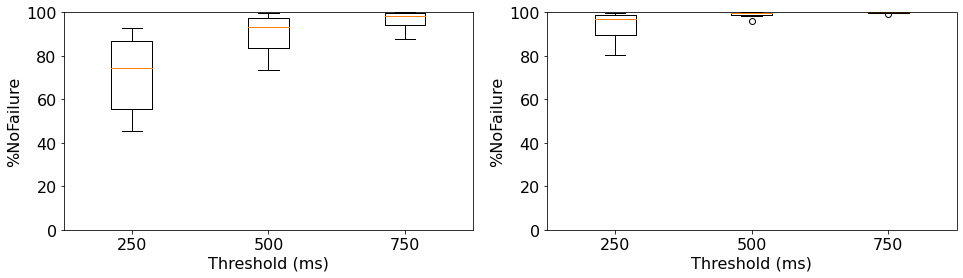

In [ ]:
# Plot Percentage of Sim Runs with Consecutive Packet Failures
# This is for Fig. D

# For U_PLC
# PM_150 = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/PM_Based_{}_Interference_new"
# PM_500 = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/PM_Based_RL_500ms_{}_Interference_new"
# PM_850 = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/PM_Based_RL_750ms_{}_Interference_new"

# For G+U_PLC
PM_150 = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/PM_GCS_Based_{}_Interference_new"
PM_500 = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/PM_GCS_Based_RL_500ms_{}_Interference_new"
PM_850 = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/PM_GCS_Based_RL_750ms_{}_Interference_new"

CASES = ["uav_scenario_0_processed", "uav_scenario_1_processed", "uav_scenario_2_processed",
         "manet_scenario_1_processed", "manet_scenario_a_processed", "manet_scenario_2_processed"]
MAX_RUN_NUM = 499 # Run num starts at 0
N_SECS = 2 

'''First, Plot for N_SECS = 2'''
N_SECS = 2 
# To store the percentage of sim runs with no cons packet failures
pm_150_result = []
pm_500_result = []
pm_850_result = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"
    pm_150_df = compile_results(PM_150.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    pm_500_df = compile_results(PM_500.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    pm_850_df = compile_results(PM_850.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))

    '''Temporary resolution to error in processing script introducing redundant columns'''
    try:
        pm_150_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        pm_500_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        pm_850_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass

    '''Filter out runs where there are NaN reliability (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    pm_150_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_500_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_850_df.sort_values(by=["Scenario", "Run"], inplace=True)

    pm_150_df.reset_index(inplace=True)
    pm_500_df.reset_index(inplace=True)
    pm_850_df.reset_index(inplace=True)

    runs_nan = (pm_150_df.isnull().any(axis=1).to_numpy()) | (pm_500_df.isnull().any(axis=1).to_numpy()) | (pm_850_df.isnull().any(axis=1).to_numpy()) 
    pm_150_df_fil = pm_150_df.loc[~(runs_nan)]
    pm_500_df_fil = pm_500_df.loc[~(runs_nan)]
    pm_850_df_fil = pm_850_df.loc[~(runs_nan)]

    '''Get percentages of sim runs with N_SECS consecutive packet failure in at least one link'''
    pm_150_result.append(len(pm_150_df_fil.loc[(pm_150_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (pm_150_df_fil["UAV_1_Cons_Fail"] == 0) & (pm_150_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (pm_150_df_fil["UAV_3_Cons_Fail"] == 0) & (pm_150_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (pm_150_df_fil["UAV_5_Cons_Fail"] == 0) & (pm_150_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (pm_150_df_fil["UAV_7_Cons_Fail"] == 0)])/len(pm_150_df_fil) * 100)
    pm_500_result.append(len(pm_500_df_fil.loc[(pm_500_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (pm_500_df_fil["UAV_1_Cons_Fail"] == 0) & (pm_500_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (pm_500_df_fil["UAV_3_Cons_Fail"] == 0) & (pm_500_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (pm_500_df_fil["UAV_5_Cons_Fail"] == 0) & (pm_500_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (pm_500_df_fil["UAV_7_Cons_Fail"] == 0)])/len(pm_500_df_fil) * 100)
    pm_850_result.append(len(pm_850_df_fil.loc[(pm_850_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (pm_850_df_fil["UAV_1_Cons_Fail"] == 0) & (pm_850_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (pm_850_df_fil["UAV_3_Cons_Fail"] == 0) & (pm_850_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (pm_850_df_fil["UAV_5_Cons_Fail"] == 0) & (pm_850_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (pm_850_df_fil["UAV_7_Cons_Fail"] == 0)])/len(pm_850_df_fil) * 100)
    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plt.rcParams.update({'font.size': 16, 'xtick.labelsize':'medium'})
# for i in range(len(CASES)):
#     ax1.plot(["250", "500", "750"], 
#              [pm_850_result[i], pm_500_result[i], pm_150_result[i]], '-o')
ax1.boxplot([pm_850_result, pm_500_result, pm_150_result], showmeans=False, labels=["250", "500", "750"])
# plt.legend( ["UAV 1", "UAV 2", "UAV 3", "MANET 1", "MANET 2", "MANET 3"], loc="lower right", fontsize=14, ncol=2) 
ax1.set_ylabel("Probability of NPRF")
ax1.set_xlabel('Threshold (ms)')
ax1.set_ylim((0, 100))

'''Then, Plot for N_SECS = 3'''
N_SECS = 3
# To store the percentage of sim runs with no cons packet failures
pm_150_result = []
pm_500_result = []
pm_850_result = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"
    pm_150_df = compile_results(PM_150.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    pm_500_df = compile_results(PM_500.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    pm_850_df = compile_results(PM_850.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))

    '''Temporary resolution to error in processing script introducing redundant columns'''
    try:
        pm_150_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        pm_500_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass
    try:
        pm_850_df.drop(labels=["Num_Pkts_Reliable_DL","Num_Broadcast_DL","Useful_Packet_Reception_Ratio_DL","Total_Reliability_DL","DL_Num_Delay_Excd"], axis='columns', inplace=True)
    except:
        # print("No columns dropped")
        pass

    '''Filter out runs where there are NaN reliability (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    pm_150_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_500_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_850_df.sort_values(by=["Scenario", "Run"], inplace=True)

    pm_150_df.reset_index(inplace=True)
    pm_500_df.reset_index(inplace=True)
    pm_850_df.reset_index(inplace=True)

    runs_nan = (pm_150_df.isnull().any(axis=1).to_numpy()) | (pm_500_df.isnull().any(axis=1).to_numpy()) | (pm_850_df.isnull().any(axis=1).to_numpy()) 
    pm_150_df_fil = pm_150_df.loc[~(runs_nan)]
    pm_500_df_fil = pm_500_df.loc[~(runs_nan)]
    pm_850_df_fil = pm_850_df.loc[~(runs_nan)]

    '''Get percentages of sim runs with N_SECS consecutive packet failure in at least one link'''
    pm_150_result.append(len(pm_150_df_fil.loc[(pm_150_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (pm_150_df_fil["UAV_1_Cons_Fail"] == 0) & (pm_150_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (pm_150_df_fil["UAV_3_Cons_Fail"] == 0) & (pm_150_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (pm_150_df_fil["UAV_5_Cons_Fail"] == 0) & (pm_150_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (pm_150_df_fil["UAV_7_Cons_Fail"] == 0)])/len(pm_150_df_fil) * 100)
    pm_500_result.append(len(pm_500_df_fil.loc[(pm_500_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (pm_500_df_fil["UAV_1_Cons_Fail"] == 0) & (pm_500_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (pm_500_df_fil["UAV_3_Cons_Fail"] == 0) & (pm_500_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (pm_500_df_fil["UAV_5_Cons_Fail"] == 0) & (pm_500_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (pm_500_df_fil["UAV_7_Cons_Fail"] == 0)])/len(pm_500_df_fil) * 100)
    pm_850_result.append(len(pm_850_df_fil.loc[(pm_850_df_fil["UAV_0_Cons_Fail"] == 0) &
                                           (pm_850_df_fil["UAV_1_Cons_Fail"] == 0) & (pm_850_df_fil["UAV_2_Cons_Fail"] == 0) &
                                           (pm_850_df_fil["UAV_3_Cons_Fail"] == 0) & (pm_850_df_fil["UAV_4_Cons_Fail"] == 0) & 
                                           (pm_850_df_fil["UAV_5_Cons_Fail"] == 0) & (pm_850_df_fil["UAV_6_Cons_Fail"] == 0) & 
                                           (pm_850_df_fil["UAV_7_Cons_Fail"] == 0)])/len(pm_850_df_fil) * 100)

# for i in range(len(CASES)):
#     ax2.plot(["250", "500", "750"], 
#              [pm_850_result[i], pm_500_result[i], pm_150_result[i]], '-o')
ax2.boxplot([pm_850_result, pm_500_result, pm_150_result], showmeans=False, labels=["250", "500", "750"])
ax2.set_ylabel("Probability of NPRF")
ax2.set_xlabel('Threshold (ms)')
ax2.set_ylim((0, 100))

# plt.legend( ["UAV 1", "UAV 2", "UAV 3", "MANET 1", "MANET 2", "MANET 3"], bbox_to_anchor=(-0.25, 1.05, 1, 0.2), loc="lower right", fontsize=14, ncol=6) 
plt.subplots_adjust(wspace=0.18)

(0.0, 100.0)

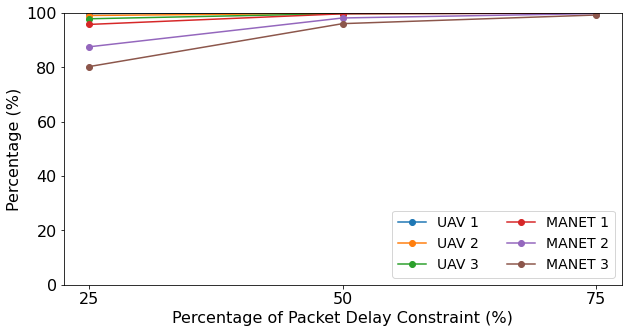

In [48]:
fig, ax = plt.subplots(figsize=(10, 5))
plt.rcParams.update({'font.size': 16, 'xtick.labelsize':'medium'})
for i in range(len(CASES)):
    plt.plot(["25", "50", "75"], 
             [pm_850_result[i], pm_500_result[i], pm_150_result[i]], '-o')
plt.legend( ["UAV 1", "UAV 2", "UAV 3", "MANET 1", "MANET 2", "MANET 3"], loc="lower right", fontsize=14, ncol=2) 
plt.ylabel("Percentage (%)")
plt.xlabel('Percentage of Packet Delay Constraint (%)')
plt.ylim((0, 100))

In [25]:
# Print values for table
# Paste the cell output to NotePad, then copy paste to excel
print(",".join([str(i) for i in pm_150_result]))
print(",".join([str(i) for i in pm_500_result]))
print(",".join([str(i) for i in pm_850_result]))

81.47790854717346,82.72448272448273,79.8145224940805,73.0279670132664,58.78880042937651,51.28913443830571
81.55508392822689,82.57598257598258,79.60734017363852,73.35962710648978,58.45782270328294,51.187845303867405
78.87323943661971,80.86328086328086,77.9301499605367,70.99318752240946,55.926290365864574,47.86372007366482


In [3]:
# Load Data
PM_150_UAV_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/PM_GCS_Based_UAV_Interference"
PM_150_MANET_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/PM_GCS_Based_MANET_Interference"
PM_500_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/PM_Finetune/PM_GCS_RL_500ms"
PM_850_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/PM_Finetune/PM_GCS_RL_850ms"

pm_150_uav_0 = compile_results(PM_150_UAV_PATH, ["uav_scenario_0_processed"])
pm_150_uav_1 = compile_results(PM_150_UAV_PATH, ["uav_scenario_1_processed"])
pm_150_uav_2 = compile_results(PM_150_UAV_PATH, ["uav_scenario_2_processed"])
pm_150_manet_0 = compile_results(PM_150_MANET_PATH, ["manet_scenario_0_processed"])
pm_150_manet_1 = compile_results(PM_150_MANET_PATH, ["manet_scenario_1_processed"])
pm_150_manet_2 = compile_results(PM_150_MANET_PATH, ["manet_scenario_2_processed"])

pm_500_uav_0 = compile_results(PM_500_PATH, ["uav_scenario_0_processed"])
pm_500_uav_1 = compile_results(PM_500_PATH, ["uav_scenario_1_processed"])
pm_500_uav_2 = compile_results(PM_500_PATH, ["uav_scenario_2_processed"])
pm_500_manet_0 = compile_results(PM_500_PATH, ["manet_scenario_0_processed"])
pm_500_manet_1 = compile_results(PM_500_PATH, ["manet_scenario_1_processed"])
pm_500_manet_2 = compile_results(PM_500_PATH, ["manet_scenario_2_processed"])

pm_850_uav_0 = compile_results(PM_850_PATH, ["uav_scenario_0_processed"])
pm_850_uav_1 = compile_results(PM_850_PATH, ["uav_scenario_1_processed"])
pm_850_uav_2 = compile_results(PM_850_PATH, ["uav_scenario_2_processed"])
pm_850_manet_0 = compile_results(PM_850_PATH, ["manet_scenario_0_processed"])
pm_850_manet_1 = compile_results(PM_850_PATH, ["manet_scenario_1_processed"])
pm_850_manet_2 = compile_results(PM_850_PATH, ["manet_scenario_2_processed"])

pm_150_rel_list = [pm_150_uav_0["Total_Reliability_DL"].values*100, pm_150_uav_1["Total_Reliability_DL"].values*100, pm_150_uav_2["Total_Reliability_DL"].values*100, 
                   pm_150_manet_0["Total_Reliability_DL"].values*100, pm_150_manet_1["Total_Reliability_DL"].values*100, pm_150_manet_2["Total_Reliability_DL"].values*100]
pm_500_rel_list = [pm_500_uav_0["Total_Reliability_DL"].values*100, pm_500_uav_1["Total_Reliability_DL"].values*100, pm_500_uav_2["Total_Reliability_DL"].values*100, 
                   pm_500_manet_0["Total_Reliability_DL"].values*100, pm_500_manet_1["Total_Reliability_DL"].values*100, pm_500_manet_2["Total_Reliability_DL"].values*100]
pm_850_rel_list = [pm_850_uav_0["Total_Reliability_DL"].values*100, pm_850_uav_1["Total_Reliability_DL"].values*100, pm_850_uav_2["Total_Reliability_DL"].values*100, 
                   pm_850_manet_0["Total_Reliability_DL"].values*100, pm_850_manet_1["Total_Reliability_DL"].values*100, pm_850_manet_2["Total_Reliability_DL"].values*100]

pm_150_uprr_list = [pm_150_uav_0["Useful_Packet_Reception_Ratio_DL"].dropna().values*100, pm_150_uav_1["Useful_Packet_Reception_Ratio_DL"].dropna().values*100, pm_150_uav_2["Useful_Packet_Reception_Ratio_DL"].dropna().values*100, 
                   pm_150_manet_0["Useful_Packet_Reception_Ratio_DL"].dropna().values*100, pm_150_manet_1["Useful_Packet_Reception_Ratio_DL"].dropna().values*100, pm_150_manet_2["Useful_Packet_Reception_Ratio_DL"].dropna().values*100]
pm_500_uprr_list = [pm_500_uav_0["Useful_Packet_Reception_Ratio_DL"].dropna().values*100, pm_500_uav_1["Useful_Packet_Reception_Ratio_DL"].dropna().values*100, pm_500_uav_2["Useful_Packet_Reception_Ratio_DL"].dropna().values*100, 
                   pm_500_manet_0["Useful_Packet_Reception_Ratio_DL"].dropna().values*100, pm_500_manet_1["Useful_Packet_Reception_Ratio_DL"].dropna().values*100, pm_500_manet_2["Useful_Packet_Reception_Ratio_DL"].dropna().values*100]
pm_850_uprr_list = [pm_850_uav_0["Useful_Packet_Reception_Ratio_DL"].dropna().values*100, pm_850_uav_1["Useful_Packet_Reception_Ratio_DL"].dropna().values*100, pm_850_uav_2["Useful_Packet_Reception_Ratio_DL"].dropna().values*100, 
                   pm_850_manet_0["Useful_Packet_Reception_Ratio_DL"].dropna().values*100, pm_850_manet_1["Useful_Packet_Reception_Ratio_DL"].dropna().values*100, pm_850_manet_2["Useful_Packet_Reception_Ratio_DL"].dropna().values*100]


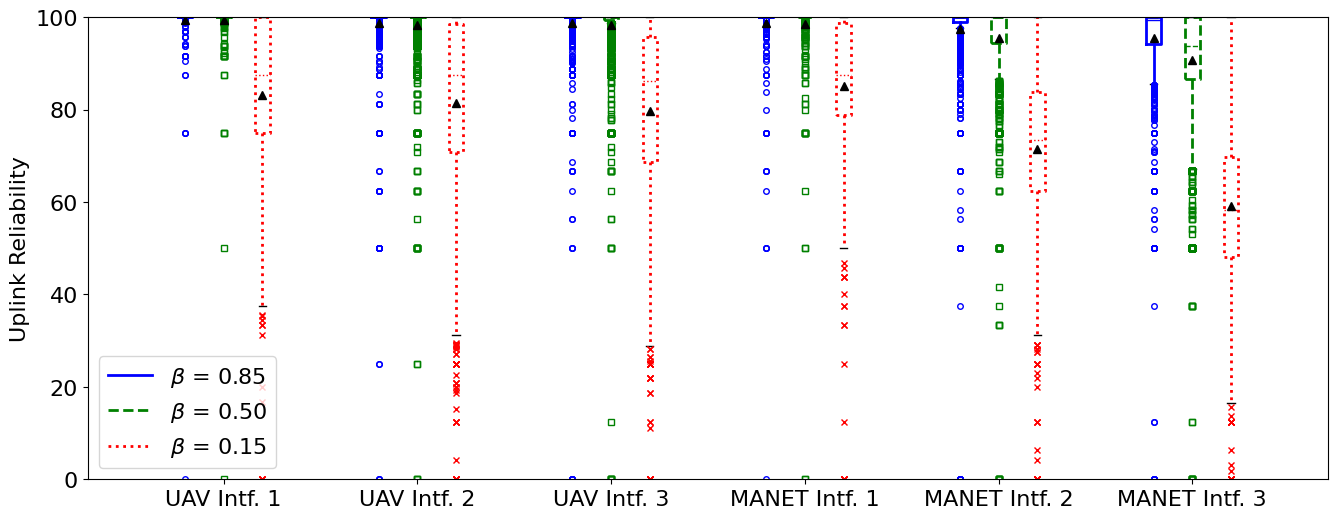

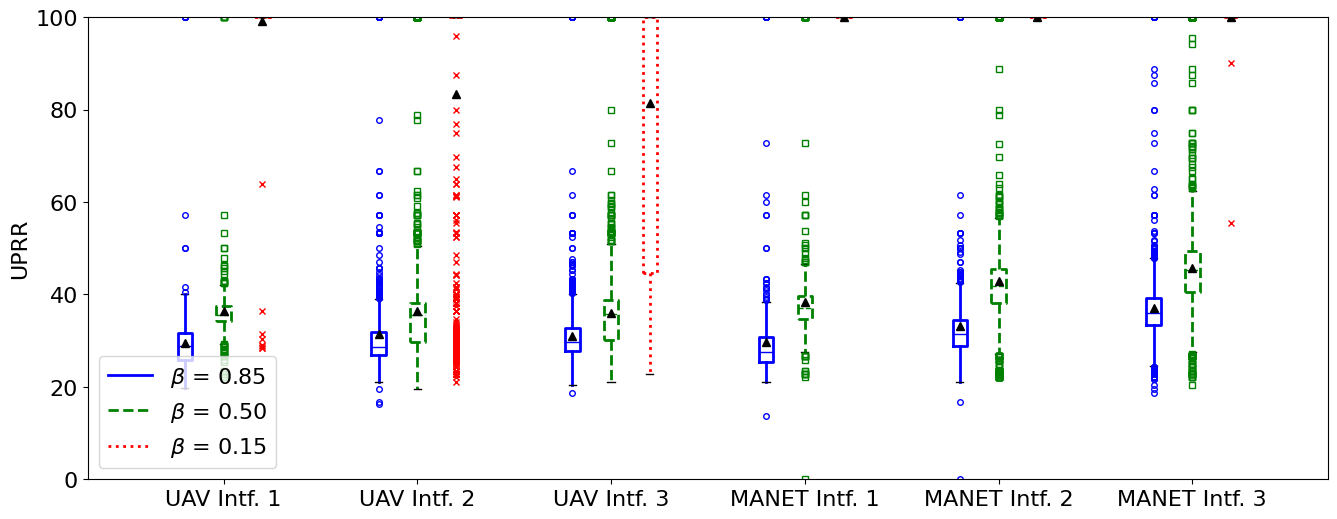

In [4]:
space = 0.1
box_params = dict(widths=0.075)
fig = plt.figure(figsize=(16, 6))
plt.rcParams.update({'font.size': 16})
box_1 = plt.boxplot(pm_150_rel_list, showmeans=True, labels=None,
            positions=np.arange(6)-2*space, boxprops=dict(linestyle='-', linewidth=2,  color='blue'), whiskerprops=dict(linestyle='-', linewidth=2, color='blue'), 
            medianprops=dict(linestyle='-', color='blue'), meanprops=dict(markerfacecolor="black", markeredgecolor="black"), flierprops=dict(marker='o', markeredgecolor='blue', markersize=4), **box_params)
box_2 = plt.boxplot(pm_500_rel_list, showmeans=True, labels=None,
            positions=np.arange(6), boxprops=dict(linestyle='--', linewidth=2, color='green'), whiskerprops=dict(linestyle='--', linewidth=2, color='green'),
            medianprops=dict(linestyle='--', color='green'), meanprops=dict(markerfacecolor="black", markeredgecolor="black"), flierprops=dict(marker='s', markeredgecolor='green', markersize=4), **box_params)
box_3 = plt.boxplot(pm_850_rel_list, showmeans=True, labels=None,
            positions=np.arange(6)+2*space, boxprops=dict(linestyle=':', linewidth=2, color='red'), whiskerprops=dict(linestyle=':', linewidth=2, color='red'),
            medianprops=dict(linestyle=':', color='red'), meanprops=dict(markerfacecolor="black", markeredgecolor="black"), flierprops=dict(marker='x', markeredgecolor='red', markersize=4), **box_params)
# plt.xticks(np.arange(6), ["","UAV Intf. 1","","", "UAV Intf. 2","","", "UAV Intf. 3","","", "MANET Intf. 1","","", "MANET Intf. 2","","", "MANET Intf. 3","",])
plt.xticks(np.arange(6), ["UAV Intf. 1","UAV Intf. 2","UAV Intf. 3","MANET Intf. 1","MANET Intf. 2","MANET Intf. 3"])
plt.ylabel("Uplink Reliability")
plt.ylim(0,100)
plt.legend((box_1["boxes"][0], box_2["boxes"][0], box_3["boxes"][0]), ("$\\beta$ = 0.85", "$\\beta$ = 0.50", "$\\beta$ = 0.15"), loc='lower left')

space = 0.1
box_params = dict(widths=0.075)
fig = plt.figure(figsize=(16, 6))
plt.rcParams.update({'font.size': 16})
box_1 = plt.boxplot(pm_150_uprr_list, showmeans=True, labels=None,
            positions=np.arange(6)-2*space, boxprops=dict(linestyle='-', linewidth=2,  color='blue'), whiskerprops=dict(linestyle='-', linewidth=2, color='blue'), 
            medianprops=dict(linestyle='-', color='blue'), meanprops=dict(markerfacecolor="black", markeredgecolor="black"), flierprops=dict(marker='o', markeredgecolor='blue', markersize=4), **box_params)
box_2 = plt.boxplot(pm_500_uprr_list, showmeans=True, labels=None,
            positions=np.arange(6), boxprops=dict(linestyle='--', linewidth=2, color='green'), whiskerprops=dict(linestyle='--', linewidth=2, color='green'),
            medianprops=dict(linestyle='--', color='green'), meanprops=dict(markerfacecolor="black", markeredgecolor="black"), flierprops=dict(marker='s', markeredgecolor='green', markersize=4), **box_params)
box_3 = plt.boxplot(pm_850_uprr_list, showmeans=True, labels=None,
            positions=np.arange(6)+2*space, boxprops=dict(linestyle=':', linewidth=2, color='red'), whiskerprops=dict(linestyle=':', linewidth=2, color='red'),
            medianprops=dict(linestyle=':', color='red'), meanprops=dict(markerfacecolor="black", markeredgecolor="black"), flierprops=dict(marker='x', markeredgecolor='red', markersize=4), **box_params)
# plt.xticks(np.arange(6), ["","UAV Intf. 1","","", "UAV Intf. 2","","", "UAV Intf. 3","","", "MANET Intf. 1","","", "MANET Intf. 2","","", "MANET Intf. 3","",])
plt.xticks(np.arange(6), ["UAV Intf. 1","UAV Intf. 2","UAV Intf. 3","MANET Intf. 1","MANET Intf. 2","MANET Intf. 3"])
plt.ylabel("UPRR")
plt.ylim(0,100)
plt.legend((box_1["boxes"][0], box_2["boxes"][0], box_3["boxes"][0]), ("$\\beta$ = 0.85", "$\\beta$ = 0.50", "$\\beta$ = 0.15"), loc='lower left')

## Plot Results Manual Rebroadcasting

(0.0, 100.0)

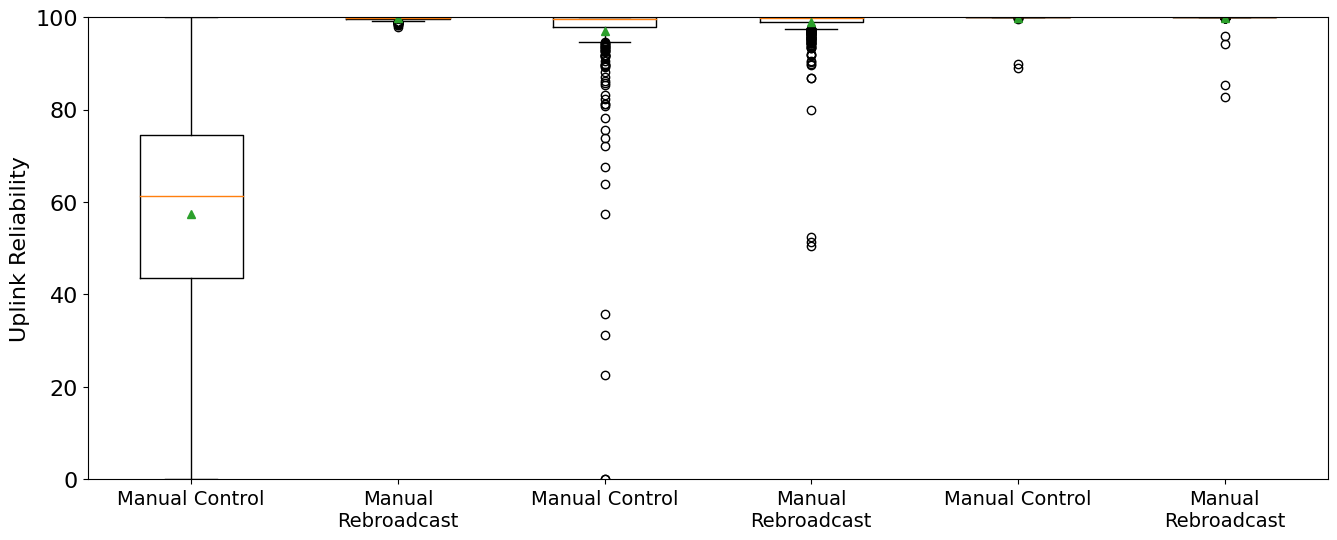

In [20]:
# CASES = ["uav_scenario_1_processed"]
# MANUAL_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_UAV_Interference"
# MANUAL_BR_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/Manual_Rebroadcast_Exp/TH_RL10ms_MaxBr7"

CASES = ["manet_scenario_1_processed"]
MANUAL_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_MANET_Interference"
MANUAL_BR_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/Manual_Rebroadcast_Exp/TH_RL10ms_MaxBr7"

manual_df = compile_results(MANUAL_PATH, CASES, "Simulation_Results.csv")
manual_br_df = compile_results(MANUAL_BR_PATH, CASES)

# Plot box plot for Avg DL Reliability
avg_dl_rel_list = [manual_df["Total_Reliability_DL"].values*100, manual_br_df["Total_Reliability_DL"].values*100, manual_df["Total_Reliability_UL"].values*100, 
                   manual_br_df["Total_Reliability_UL"].values*100, manual_df["Total_Reliability_VID"].values*100, manual_br_df["Total_Reliability_VID"].values*100]
fig = plt.figure(figsize=(16, 6))
plt.rcParams.update({'font.size': 16})
plt.boxplot(avg_dl_rel_list, showmeans=True, labels=["Manual Control", "Manual\nRebroadcast", "Manual Control", "Manual\nRebroadcast", "Manual Control", "Manual\nRebroadcast"])
plt.ylabel("Uplink Reliability")
plt.xticks(fontsize=14)
plt.ylim(0, 100)


(0.0, 100.0)

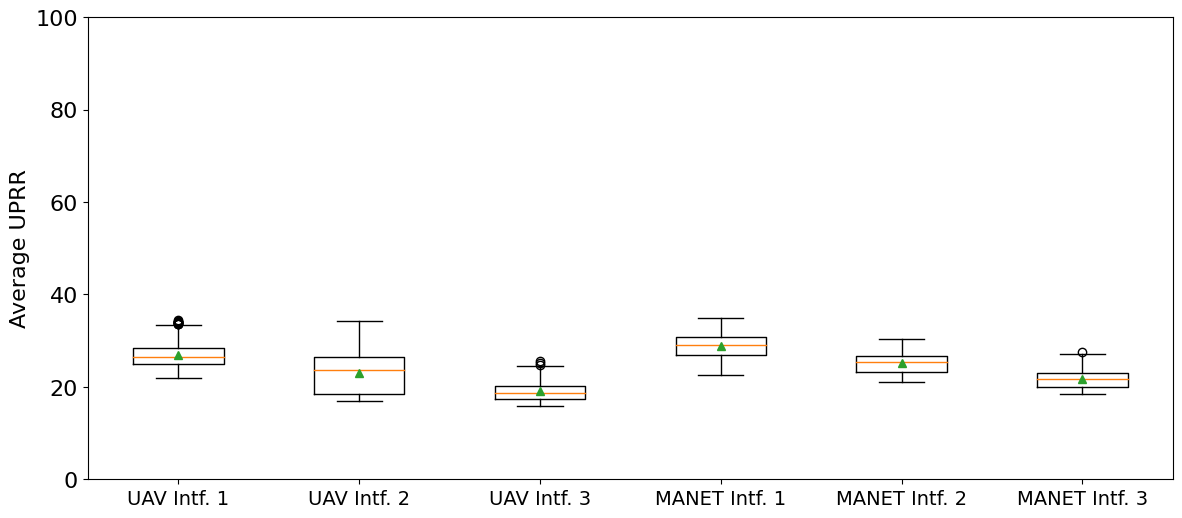

In [21]:
MANUAL_BR_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/Manual_Rebroadcast_Exp/TH_RL10ms_MaxBr7"

uav_0 = compile_results(MANUAL_BR_PATH, ["uav_scenario_0_processed"])
uav_1 = compile_results(MANUAL_BR_PATH, ["uav_scenario_1_processed"])
uav_2 = compile_results(MANUAL_BR_PATH, ["uav_scenario_2_processed"])
manet_0 = compile_results(MANUAL_BR_PATH, ["manet_scenario_0_processed"])
manet_1 = compile_results(MANUAL_BR_PATH, ["manet_scenario_1_processed"])
manet_2 = compile_results(MANUAL_BR_PATH, ["manet_scenario_2_processed"])


# Plot box plot for Avg DL UPRR
avg_dl_uprr_list = [uav_0["Useful_Packet_Reception_Ratio_DL"].dropna().values*100, uav_1["Useful_Packet_Reception_Ratio_DL"].dropna().values*100, 
                    uav_2["Useful_Packet_Reception_Ratio_DL"].dropna().values*100, manet_0["Useful_Packet_Reception_Ratio_DL"].dropna().values*100,
                    manet_1["Useful_Packet_Reception_Ratio_DL"].dropna().values*100, manet_2["Useful_Packet_Reception_Ratio_DL"].dropna().values*100]
fig = plt.figure(figsize=(14, 6))
plt.rcParams.update({'font.size': 16})
plt.boxplot(avg_dl_uprr_list, showmeans=True, labels=["UAV Intf. 1", "UAV Intf. 2", "UAV Intf. 3", "MANET Intf. 1", "MANET Intf. 2", "MANET Intf. 3"])
plt.ylabel("Average UPRR")
plt.xticks(fontsize=14)
plt.ylim(0, 100)

### Temporary, To Plot Specificity and Sensitivity

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

dl_sensitivity_gamma = [0.992,0.997,1,0.969,0.983,0.998]
ul_sensitivity_gamma = [0.941,0.965,0.982,0.807,0.884,0.922]
dl_specificity_gamma = [0.993,0.916,0.749,0.975,0.92,0.831]
ul_specificity_gamma = [0.998,0.971,0.935,0.996,0.992,0.979]

dl_sensitivity_th = [0.625,0.893,0.985,0.234,0.456,0.908]
ul_sensitivity_th = [0.888,0.752,0.819,0.604,0.688,0.68]
dl_specificity_th = [1,1,0.999,1,1,1]
ul_specificity_th = [1,1,1,1,1,1]

# For x-ticks
ind = np.arange(6, dtype=float)  
width = 0.2

# PLOT SENSITIVITY
plt.figure(figsize=(14,5))
plt.rcParams.update({'font.size': 14})
bar_th = plt.bar(ind, np.array(dl_sensitivity_th)*100, width, edgecolor='black', color = '0.9') 
bar_gamma = plt.bar(ind + width, np.array(dl_sensitivity_gamma)*100, width, edgecolor='black', color = '0.6') 
plt.ylabel('Sensitivity (%)') 
plt.xlabel('Interference Scenario') 
# plt.title("Uplink")
# plt.ylim(0.95, 1.0)
plt.xticks(ind+0.5*width,['UAV 1', 'UAV 2', 'UAV 3', 'MANET 1', 'MANET 2', 'MANET 3'])
plt.tick_params(axis='x', which='both',length=0)
plt.legend( (bar_th, bar_gamma), ('Throughput', '$\gamma$'), bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower center", borderaxespad=0, ncol=3) 

plt.figure(figsize=(14,5))
plt.rcParams.update({'font.size': 14})
bar_th = plt.bar(ind, np.array(ul_sensitivity_th)*100, width, edgecolor='black', color = '0.9') 
bar_gamma = plt.bar(ind + width, np.array(ul_sensitivity_gamma)*100, width, edgecolor='black', color = '0.6') 
plt.ylabel('Sensitivity (%)') 
plt.xlabel('Interference Scenario') 
# plt.title("Downlink")
# plt.ylim(0.95, 1.0)
plt.xticks(ind+0.5*width,['UAV 1', 'UAV 2', 'UAV 3', 'MANET 1', 'MANET 2', 'MANET 3'])
plt.tick_params(axis='x', which='both',length=0)
plt.legend( (bar_th, bar_gamma), ('Throughput', '$\gamma$'), bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower center", borderaxespad=0, ncol=3) 


# PLOT SPECIFICITY
plt.figure(figsize=(14,5))
plt.rcParams.update({'font.size': 14})
bar_th = plt.bar(ind, np.array(dl_specificity_th)*100, width, edgecolor='black', color = '0.9') 
bar_gamma = plt.bar(ind + width, np.array(dl_specificity_gamma)*100, width, edgecolor='black', color = '0.6') 
plt.ylabel('Specificity (%)') 
plt.xlabel('Interference Scenario') 
# plt.title("Uplink")
# plt.ylim(0.95, 1.0)
plt.xticks(ind+0.5*width,['UAV 1', 'UAV 2', 'UAV 3', 'MANET 1', 'MANET 2', 'MANET 3'])
plt.tick_params(axis='x', which='both',length=0)
plt.legend( (bar_th, bar_gamma), ('Throughput', '$\gamma$'), bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower center", borderaxespad=0, ncol=3) 

plt.figure(figsize=(14,5))
plt.rcParams.update({'font.size': 14})
bar_th = plt.bar(ind, np.array(ul_specificity_th)*100, width, edgecolor='black', color = '0.9') 
bar_gamma = plt.bar(ind + width, np.array(ul_specificity_gamma)*100, width, edgecolor='black', color = '0.6') 
plt.ylabel('Specificity (%)') 
plt.xlabel('Interference Scenario') 
# plt.title("Downlink")
# plt.ylim(0.95, 1.0)
plt.xticks(ind+0.5*width,['UAV 1', 'UAV 2', 'UAV 3', 'MANET 1', 'MANET 2', 'MANET 3'])
plt.tick_params(axis='x', which='both',length=0)
plt.legend( (bar_th, bar_gamma), ('Throughput', '$\gamma$'), bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower center", borderaxespad=0, ncol=3) 

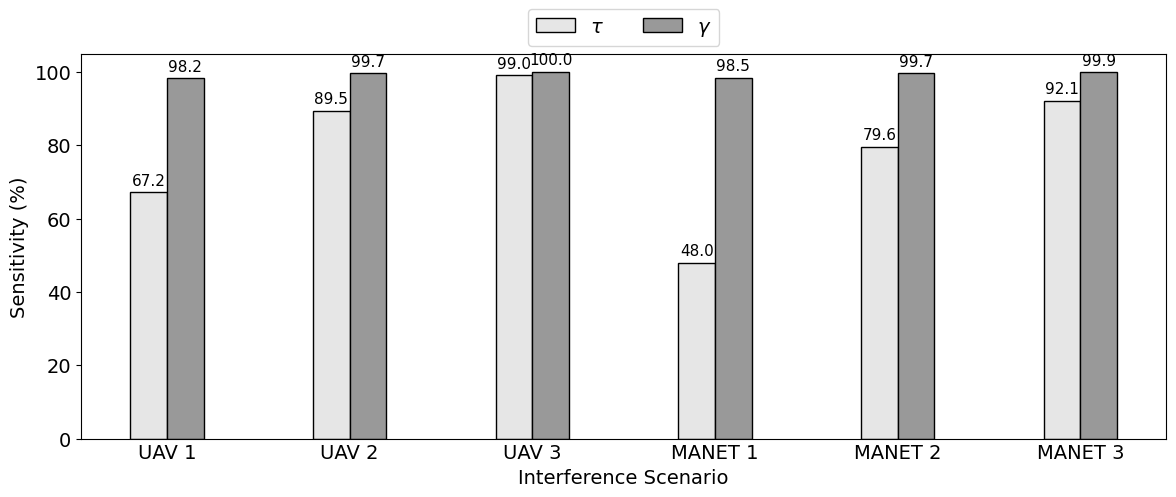

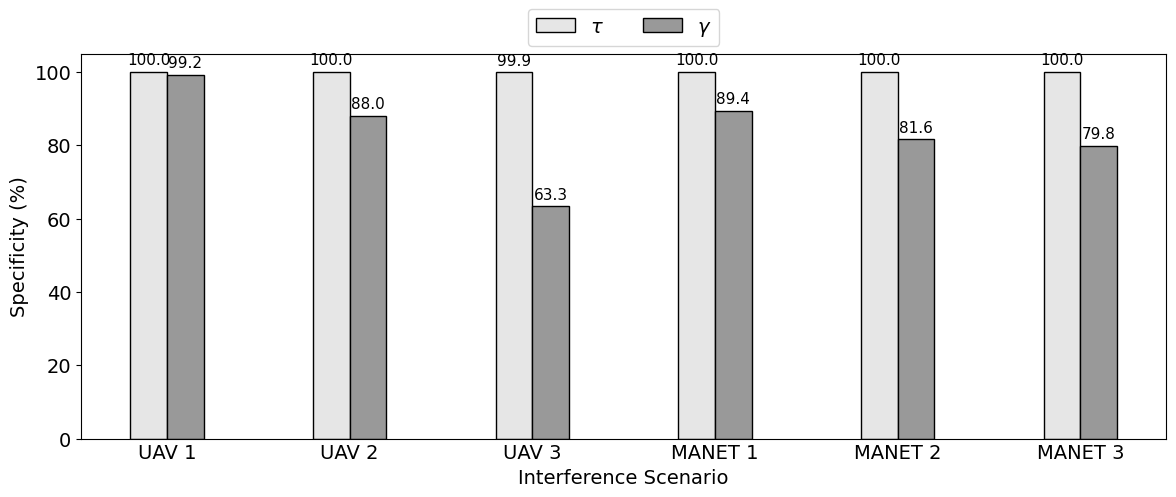

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

dl_sensitivity_gamma = [0.982395077542037,0.996685033515565,0.999880013015537,0.984592915479092,0.9966689910213187,0.998866652118515]
dl_specificity_gamma = [0.991812744945097,0.880431788624406,0.633088235294117,0.894317491302134,0.8164350305345667,0.798219322990127]

dl_sensitivity_th = [0.672424650115195,0.894643687038525,0.990348456148098,0.479942902025264,0.7960182516278224,0.921243467997587]
dl_specificity_th = [0.999999602038834,0.999975593343258,0.999264705882352,0.999984047266499,0.9999623610888937,0.999941231781852]

# For x-ticks
ind = np.arange(6, dtype=float)  
width = 0.2

# PLOT SENSITIVITY
plt.figure(figsize=(14,5))
plt.rcParams.update({'font.size': 14})
bar_th = plt.bar(ind, np.array(dl_sensitivity_th)*100, width, edgecolor='black', color = '0.9') 
plt.bar_label(bar_th, fmt='%.1f', padding=3, fontsize=11)
bar_gamma = plt.bar(ind + width, np.array(dl_sensitivity_gamma)*100, width, edgecolor='black', color = '0.6') 
plt.bar_label(bar_gamma, fmt='%.1f', padding=3, fontsize=11)
plt.ylabel('Sensitivity (%)') 
plt.xlabel('Interference Scenario') 
# plt.title("Uplink")
# plt.ylim(0.95, 1.0)
plt.xticks(ind+0.5*width,['UAV 1', 'UAV 2', 'UAV 3', 'MANET 1', 'MANET 2', 'MANET 3'])
plt.tick_params(axis='x', which='both',length=0)
plt.legend( (bar_th, bar_gamma), ('$\\tau$', '$\gamma$'), bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower center", borderaxespad=0, ncol=3) 

# PLOT SPECIFICITY
plt.figure(figsize=(14,5))
plt.rcParams.update({'font.size': 14})
bar_th = plt.bar(ind, np.array(dl_specificity_th)*100, width, edgecolor='black', color = '0.9') 
plt.bar_label(bar_th, fmt='%.1f', padding=3, fontsize=11)
bar_gamma = plt.bar(ind + width, np.array(dl_specificity_gamma)*100, width, edgecolor='black', color = '0.6') 
plt.bar_label(bar_gamma, fmt='%.1f', padding=3, fontsize=11)
plt.ylabel('Specificity (%)') 
plt.xlabel('Interference Scenario') 
# plt.title("Uplink")
# plt.ylim(0.95, 1.0)
plt.xticks(ind+0.5*width,['UAV 1', 'UAV 2', 'UAV 3', 'MANET 1', 'MANET 2', 'MANET 3'])
plt.tick_params(axis='x', which='both',length=0)
plt.legend( (bar_th, bar_gamma), ('$\\tau$', '$\gamma$'), bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower center", borderaxespad=0, ncol=3) 